# **Customer Churn Intelligence System — Interconnect Telecom**
### Predictive Analytics & Machine Learning for Retention | Target AUC-ROC: > 0.88

---

### **Business Context**
Interconnect operates in a hyper-competitive telecommunications market. Acquiring a new customer costs 5–7× more than retaining one. With a **26.5% churn rate**, the company faces silent erosion of Monthly Recurring Revenue. This system transforms behavioral data into actionable early-warning signals for Marketing and Retention teams.

> **Mission:** Proactively identify high-risk customers and trigger personalized interventions before churn occurs.
---

### **Data Source Overview**

| Source | Domain | Records |
|---|---|---|
| `contract.csv` | Fact: contract type, billing, tenure | 7,043 |
| `personal.csv` | Dimension: demographics | 7,043 |
| `internet.csv` | Dimension: network & digital services | 5,517 |
| `phone.csv` | Dimension: telephony services | 6,361 |

*Snapshot date: 2020-02-01*

## **1. Data Preparation: Ingestion, QA & Integrity Validation**

Interconnect's operational data lives across four independent systems — billing, CRM, network, and telephony. No single system holds a complete customer view.

A model trained on dirty data learns the noise — misclassifying loyal customers as high-risk (wasted retention spend) or missing genuine churners (lost revenue). Data quality is a business risk control.

| Layer | Tool | Purpose |
|---|---|---|
| Structural validation | `src/etl/` | Schema, PK, row counts |
| Statistical validation | Great Expectations | Ranges, domains, null contracts |
| Regression gate | pytest + CI | Prevents bad data reaching modeling |

**Deliverable:** `data/processed/df_clean.parquet`

### 1.1 Environment Setup & Dependency Stack

All imports consolidated here — no import is repeated downstream.

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import os, sys, re, json, time, joblib, tracemalloc
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
from scipy.stats import pointbiserialr
from lifelines import KaplanMeierFitter

# ── ML ──────────────────────────────────────────────────────────────────────
import shap
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay,
    recall_score, precision_score, f1_score,
)
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.feature_selection import mutual_info_classif
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from flaml import AutoML
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# ── Project source modules ───────────────────────────────────────────────────
PROJECT_ROOT = Path(os.getcwd())

from src.etl.ingest import load_raw_data
from src.etl.transform import ChurnPreprocessor, ABBREVIATION_MAP, SPECIAL_CHAR_PATTERN, SERVICE_COLS
from src.etl.validate import validate_clean, DataValidationError
from src.features.engineer import engineer_features

# ── Ensure output directories ────────────────────────────────────────────────
for d in ['models','reports','data/processed']:
    (PROJECT_ROOT / d).mkdir(parents=True, exist_ok=True)

print(f"✓ Environment ready | {PROJECT_ROOT}")
print(f"  Python {sys.version.split()[0]} | pandas {pd.__version__} | numpy {np.__version__}")


✓ Environment ready | /home/hkr-t/DS_ENVIRONMENT/projects/customer-churn-prediction
  Python 3.12.3 | pandas 2.3.3 | numpy 2.3.5


### 1.2 Ingestion & Data Consolidation
The four disparate data sources share `customerID` as a unique primary key. I implemented a Star Schema approach using `contract` as the Fact Table in a series of Left Joins. 
This strategy ensures that the entire customer base (7043 records) is preserved, even for users who have not adopted internet or telephony services.

In [41]:
# ── Ingestion via src/etl/ingest.py → load_raw_data() ────────────────
# All path resolution, primary key validation, and merge logic lives in the source module. The notebook calls it as a single line.

tracemalloc.start()
t0 = time.time()

df_raw = load_raw_data(PROJECT_ROOT / "data" / "raw")

elapsed = time.time() - t0
_, peak_mb = tracemalloc.get_traced_memory()
tracemalloc.stop()

# ── Post-Ingestion Audit ──────────────────────────────────────────────
nulls = df_raw.isnull().sum()
null_report = nulls[nulls > 0]

print(f"{'─'*55}")
print(f"  RAW CONSOLIDATION REPORT")
print(f"{'─'*55}")
print(f"  Records   : {df_raw.shape[0]:,}")
print(f"  Features  : {df_raw.shape[1]}")
print(f"  Duplicates: {df_raw.duplicated().sum()}")
print(f"  Load time : {elapsed:.2f}s | Peak memory: {peak_mb/1e6:.1f} MB")
print(f"{'─'*55}")
print(f"  Null density (service coverage gaps):")
for col, n in null_report.items():
    print(f"    {col:<30}: {n:>4} ({n/len(df_raw)*100:.1f}%)")
print(f"{'─'*55}")
df_raw.info()
df_raw.sample(3, random_state=42)

───────────────────────────────────────────────────────
  RAW CONSOLIDATION REPORT
───────────────────────────────────────────────────────
  Records   : 7,043
  Features  : 20
  Duplicates: 0
  Load time : 0.05s | Peak memory: 7.5 MB
───────────────────────────────────────────────────────
  Null density (service coverage gaps):
    InternetService               : 1526 (21.7%)
    OnlineSecurity                : 1526 (21.7%)
    OnlineBackup                  : 1526 (21.7%)
    DeviceProtection              : 1526 (21.7%)
    TechSupport                   : 1526 (21.7%)
    StreamingTV                   : 1526 (21.7%)
    StreamingMovies               : 1526 (21.7%)
    MultipleLines                 :  682 (9.7%)
───────────────────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID       

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
185,1024-GUALD,2019-10-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,24.80,24.8,Female,0,Yes,No,DSL,No,No,No,No,No,No,NaN
2715,0484-JPBRU,2016-09-01,No,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,Male,0,No,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes
3825,3620-EHIMZ,2015-10-01,No,Two year,No,Mailed check,19.35,1031.7,Female,0,Yes,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No


### Findings — Raw Consolidation Audit

The consolidated dataset contains **7043 customers** and **20 features** with
no duplicate records. Three data quality issues require attention in the
cleaning pipeline:

| Issue | Detail - Business Explanation |
|---|---|
| `TotalCharges` column | Cast to float64 |
| `BeginDate` and `EndDate` columns | Cast to datetime, required for feature engineering and modeling|
| Service nulls (21.7%) | 1526 customers, no internet service contracted — not missing data |
| Phone nulls (9.7%) | 682 customers, no phone service contracted — not missing data |

All nulls in service columns are **structurally expected** — they represent
customers who did not contract that service, not data collection errors.

### 1.3 Column Standardization — PascalCase → snake_case

Production systems require consistent, machine-readable column names.
All 20 columns are renamed from PascalCase to snake_case using a
deterministic regex function that handles known abbreviations
(`customerID` → `customer_id`, `StreamingTV` → `streaming_tv`).

In [42]:
# ── Column standardization — visual transparency only ─────────────────
# Production logic: ChurnPreprocessor._to_snake() in src/etl/transform.py
original_cols = df_raw.columns.tolist()
renamed_cols  = [ChurnPreprocessor._to_snake(col) for col in original_cols]

print(f"{'─'*52}")
print(f"  COLUMN STANDARDIZATION REPORT")
print(f"{'─'*52}")
for orig, new in zip(original_cols, renamed_cols):
    status = "RENAMED" if orig != new else "  OK   "
    print(f"  {status}  {orig:<25} → {new}")
print(f"{'─'*52}")
print(f"  Total columns : {len(renamed_cols)} | snake_case: ✓")
print(f"  ABBREVIATION_MAP: {ABBREVIATION_MAP}")
# ── Apply renaming in-place ───────────────────────────────────────────────────
# Downstream cells use snake_case. ChurnPreprocessor re-applies this
# step at cleaning time — the operation is idempotent on snake_case input.
df_raw.columns = renamed_cols
df = df_raw   # convenience alias for the audit section (1.4) below
print(f"  Column renaming applied to df_raw. snake_case active downstream.")

────────────────────────────────────────────────────
  COLUMN STANDARDIZATION REPORT
────────────────────────────────────────────────────
  RENAMED  customerID                → customer_id
  RENAMED  BeginDate                 → begin_date
  RENAMED  EndDate                   → end_date
  RENAMED  Type                      → type
  RENAMED  PaperlessBilling          → paperless_billing
  RENAMED  PaymentMethod             → payment_method
  RENAMED  MonthlyCharges            → monthly_charges
  RENAMED  TotalCharges              → total_charges
    OK     gender                    → gender
  RENAMED  SeniorCitizen             → senior_citizen
  RENAMED  Partner                   → partner
  RENAMED  Dependents                → dependents
  RENAMED  InternetService           → internet_service
  RENAMED  OnlineSecurity            → online_security
  RENAMED  OnlineBackup              → online_backup
  RENAMED  DeviceProtection          → device_protection
  RENAMED  TechSupport          

### 1.4 Data Quality Audit

Before any cleaning, every column is scanned across four dimensions:
null density, empty strings, special characters, and edge whitespace.
This establishes a documented evidence base for every cleaning decision
made in Section 1.5 — nothing is cleaned without a confirmed finding.

In [43]:
# Audit uses the exact same pattern as the production pipeline
AUDIT_REGEX = SPECIAL_CHAR_PATTERN
audit_results = []

for col in df_raw.columns:
    is_object = df_raw[col].dtype == 'object'

    # 1.Real Null count (NaN/None)
    n_nulls = df_raw[col].isnull().sum()

    # 2.Empty String count (Cells containing only whitespace or "")
    n_empty = (df_raw[col].astype(str).str.strip() == '').sum() if is_object else 0

    # 3.Special Characters or System Delimiters count
    n_special = (df_raw[col].astype(str).str.contains(AUDIT_REGEX, regex=True).sum()) if is_object else 0

    # 4.Leading/Trailing Spaces count (" Yes" or "Yes ")
    n_spaces = (df_raw[col].astype(str).str.contains(r'^\s+|\s+$', regex=True).sum()) if is_object else 0

    # Determine column health status
    total_anomalies = n_nulls + n_empty + n_special + n_spaces
    status = 'REVIEW' if total_anomalies > 0 else 'OK'

    audit_results.append({
        'column': col,
        'dtype': str(df_raw[col].dtype),
        'nulls': n_nulls,
        'empty_strings': n_empty,
        'special_chars': n_special,
        'edge_spaces': n_spaces,
        'status': status
    })

# Creating Audit DataFrame
audit_df = pd.DataFrame(audit_results).set_index('column')

# Visual Report
print(f"{'='*85}")
print(f"  FORENSIC DATA AUDIT REPORT — {df_raw.shape[0]:,} Rows Scanned")
print(f"{'='*85}")
print(audit_df.to_string())
print(f"{'='*85}")

# Summary for the next stage (1.5 Sanitization)
sanitization_backlog = audit_df[audit_df['status'] == 'REVIEW'].index.tolist()
print(f"\n ACTION REQUIRED: Columns to be sanitized in Stage 1.5: {sanitization_backlog}")

  FORENSIC DATA AUDIT REPORT — 7,043 Rows Scanned
                     dtype  nulls  empty_strings  special_chars  edge_spaces  status
column                                                                              
customer_id         object      0              0              0            0      OK
begin_date          object      0              0              0            0      OK
end_date            object      0              0              0            0      OK
type                object      0              0              0            0      OK
paperless_billing   object      0              0              0            0      OK
payment_method      object      0              0              0            0      OK
monthly_charges    float64      0              0              0            0      OK
total_charges       object      0             11              0           11  REVIEW
gender              object      0              0              0            0      OK
senior_citizen 

In [44]:
# Customers with empty total_charges — all have tenure = 0 (first billing cycle)
new_customers = df_raw[df_raw['total_charges'].astype(str).str.strip() == ""]

print(f"  {len(new_customers)} customers with no charges recorded:")
display(new_customers[['customer_id', 'begin_date', 'end_date',
                        'monthly_charges', 'total_charges', 'type']])

  11 customers with no charges recorded:


,customer_id,begin_date,end_date,monthly_charges,total_charges,type
488,4472-LVYGI,2020-02-01,No,52.55,,Two year
753,3115-CZMZD,2020-02-01,No,20.25,,Two year
936,5709-LVOEQ,2020-02-01,No,80.85,,Two year
1082,4367-NUYAO,2020-02-01,No,25.75,,Two year
1340,1371-DWPAZ,2020-02-01,No,56.05,,Two year
3331,7644-OMVMY,2020-02-01,No,19.85,,Two year
3826,3213-VVOLG,2020-02-01,No,25.35,,Two year
4380,2520-SGTTA,2020-02-01,No,20.00,,Two year
5218,2923-ARZLG,2020-02-01,No,19.70,,One year
6670,4075-WKNIU,2020-02-01,No,73.35,,Two year


> **Finding:** All 11 customers with empty `total_charges` share
> `begin_date = 2020-02-01` — the dataset cutoff date. They have not
> completed a billing cycle yet. This is a **business rule**, not a
> data error. Resolution: impute `0.0`.

In [45]:
#Unique Values & Domain Validation
COLS_DATE    = ['begin_date', 'end_date']
COLS_NUMERIC = ['monthly_charges', 'total_charges', 'senior_citizen']
COLS_CAT     = [c for c in df.columns
                if df[c].dtype == 'object'
                and c not in ['customer_id'] + COLS_DATE + COLS_NUMERIC]

# ── Categorical columns ───────────────────────────────────────────────
print(f"{'='*65}")
print(f"  CATEGORICAL DOMAIN AUDIT")
print(f"{'='*65}")
for col in COLS_CAT:
    uniques = sorted(df[col].dropna().unique().tolist())
    print(f"\n  {col.upper()}")
    print(f"  Unique values ({len(uniques)}): {uniques}")

# ── Date columns ──────────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"  DATE DOMAIN AUDIT")
print(f"{'='*65}")
for col in COLS_DATE:
    serie     = df[col].astype(str).str.strip()
    converted = pd.to_datetime(serie, errors='coerce')
    fail_mask = converted.isna() & (serie != 'nan') & (serie != '')
    bad_vals  = serie[fail_mask].unique()

    print(f"\n  {col.upper()}")
    print(f"  dtype          : {df[col].dtype}")
    print(f"  Non-convertible: {fail_mask.sum()}"
          + (f" -> {bad_vals}" if fail_mask.sum() > 0 else " -> none"))
    print(f"  Date range     : {converted.dropna().min().date()}"
          f" to {converted.dropna().max().date()}")
    print(f"  Null / NaT     : {df[col].isna().sum()}")

# ── Numeric columns ───────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"  NUMERIC DOMAIN AUDIT")
print(f"{'='*65}")
for col in COLS_NUMERIC:
    serie     = df[col].astype(str).str.strip()
    converted = pd.to_numeric(serie, errors='coerce')
    n_nulls   = df[col].isna().sum()
    fail_mask = converted.isna() & (serie != '') & (serie != 'nan')
    bad_vals  = serie[fail_mask].unique()

    print(f"\n  {col.upper()}")
    print(f"  dtype current  : {df[col].dtype}")
    print(f"  Nulls          : {n_nulls}")
    print(f"  Empty strings  : {(serie == '').sum()}")
    print(f"  Non-convertible: {fail_mask.sum()}"
          + (f" -> {bad_vals}" if fail_mask.sum() > 0 else " -> none"))

    if col == 'senior_citizen':
        print(f"  Unique values  : {sorted(df[col].dropna().unique().tolist())}")
    else:
        if fail_mask.sum() == 0:
            print(f"  Range          : [{converted.min():.2f} – {converted.max():.2f}]")

  CATEGORICAL DOMAIN AUDIT

  TYPE
  Unique values (3): ['Month-to-month', 'One year', 'Two year']

  PAPERLESS_BILLING
  Unique values (2): ['No', 'Yes']

  PAYMENT_METHOD
  Unique values (4): ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']

  GENDER
  Unique values (2): ['Female', 'Male']

  PARTNER
  Unique values (2): ['No', 'Yes']

  DEPENDENTS
  Unique values (2): ['No', 'Yes']

  INTERNET_SERVICE
  Unique values (2): ['DSL', 'Fiber optic']

  ONLINE_SECURITY
  Unique values (2): ['No', 'Yes']

  ONLINE_BACKUP
  Unique values (2): ['No', 'Yes']

  DEVICE_PROTECTION
  Unique values (2): ['No', 'Yes']

  TECH_SUPPORT
  Unique values (2): ['No', 'Yes']

  STREAMING_TV
  Unique values (2): ['No', 'Yes']

  STREAMING_MOVIES
  Unique values (2): ['No', 'Yes']

  MULTIPLE_LINES
  Unique values (2): ['No', 'Yes']

  DATE DOMAIN AUDIT

  BEGIN_DATE
  dtype          : object
  Non-convertible: 0 -> none
  Date range     : 2013-10-01 to 2020-02-0

### Audit Findings — Confirmed Action Plan

All numeric and date columns are free of corrupt values. No special
characters or unexpected domains detected. The cleaning pipeline
in Section 1.5 addresses four confirmed findings:

| Finding | Scope | Resolution |
|---|---|---|
| Service nulls (LEFT JOIN artifact) | 1,526 rows (21.7%) | Impute `"No service"` |
| `total_charges` empty strings | 11 rows (0.2%) | Impute `0.0` |
| Date columns stored as `object` | `begin_date`, `end_date` | Cast to `datetime64` |
| `senior_citizen` stored as `int` | All rows | Map `0→"No"`, `1→"Yes"` |

> **Design principle:** Every cleaning action is driven by a confirmed

### 1.5 Cleaning & Sanitation Pipeline

Five deterministic transformations are applied in strict order.
All logic is encapsulated in `ChurnPreprocessor` (`src/etl/transform.py`)
and shown here step-by-step for full transparency.

In [46]:
tracemalloc.start()
t0 = time.time()

# ── Full cleaning pipeline via ChurnPreprocessor ──────────────────────
# Encapsulates all 8 transformation steps defined in src/etl/transform.py
# Idempotent: running twice produces identical results
df_clean = ChurnPreprocessor().fit_transform(df_raw)

elapsed = time.time() - t0
_, peak_mb = tracemalloc.get_traced_memory()
tracemalloc.stop()

# ── Cleaning report ───────────────────────────────────────────────────
remaining_nulls = df_clean.drop(columns=['end_date']).isnull().sum().sum()

print(f"{'='*60}")
print(f"  CLEANING PIPELINE COMPLETE")
print(f"{'='*60}")
print(f"  Rows preserved    : {df_clean.shape[0]:,}")
print(f"  Columns           : {df_clean.shape[1]}")
print(f"  Nulls remaining   : {remaining_nulls} (excl. end_date NaT)")
print(f"  Active customers  : {df_clean['end_date'].isna().sum():,}")
print(f"  Churned customers : {df_clean['end_date'].notna().sum():,}")
print(f"  Time              : {elapsed:.2f}s | Peak: {peak_mb/1e6:.1f} MB")
print(f"{'='*60}")

df_clean.info()

  CLEANING PIPELINE COMPLETE
  Rows preserved    : 7,043
  Columns           : 20
  Nulls remaining   : 0 (excl. end_date NaT)
  Active customers  : 5,174
  Churned customers : 1,869
  Time              : 0.13s | Peak: 6.0 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        7043 non-null   object        
 1   begin_date         7043 non-null   datetime64[ns]
 2   end_date           1869 non-null   datetime64[ns]
 3   type               7043 non-null   category      
 4   paperless_billing  7043 non-null   category      
 5   payment_method     7043 non-null   category      
 6   monthly_charges    7043 non-null   float64       
 7   total_charges      7043 non-null   float64       
 8   gender             7043 non-null   category      
 9   senior_citizen     7043 non-null   category      
 10  pa

### 1.6 Statistical Validation Gate — Great Expectations

`assert` statements catch crashes. Great Expectations catches
**silent data corruption** — values that are technically valid Python
but wrong for the business (e.g., `monthly_charges = -50`,
`gender = "Unknown"`).

This validation suite defines 20 contractual rules across structure,
domains, and ranges. The full report is saved to
`reports/ge_validation_clean.json` and consumed by the CI pipeline
in `.github/workflows/ci.yml` on every push.

> Results shown below are the authoritative quality certificate
> for `df_clean.parquet`.

In [47]:
try:
    validate_clean(
        df_clean,
        report_path=PROJECT_ROOT / "reports" / "ge_validation_clean.json"
    )
    print("✓ All Great Expectations rules passed.")
    print(f"  Report → reports/ge_validation_clean.json")
except DataValidationError as e:
    print(f"✗ Validation failed: {e}")
    raise

Calculating Metrics:   0%|          | 0/59 [00:00<?, ?it/s]

✓ All Great Expectations rules passed.
  Report → reports/ge_validation_clean.json


In [48]:
clean_path = PROJECT_ROOT / "data" / "processed" / "df_clean.parquet"
df_clean.to_parquet(clean_path, index=False)

print(f"✓ df_clean.parquet saved")
print(f"  Shape : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} cols")
print(f"  Path  : {clean_path}")

✓ df_clean.parquet saved
  Shape : 7,043 rows × 20 cols
  Path  : /home/hkr-t/DS_ENVIRONMENT/projects/customer-churn-prediction/data/processed/df_clean.parquet


### **Section 1 Summary: Data Preparation: Ingestion, QA & Integrity Validation**
The raw data from four operational sources has been consolidated, validated,
and certified as production-ready through a multi-layer quality pipeline.

**Engineering Transformation Ledger**

| Aspect | Engineering Action | Result |
| :--- | :--- | :--- |
| Ingestion | Left Join on `customer_id` (Star Schema) | 7,043 records, 0 duplicates |
| Schema Enforcement | Temporal & Numeric Casting | `begin_date`, `end_date` → **datetime64**; `total_charges` → **float64** |
| Optimization | Memory & Type Standardization | **15 columns** cast to **category**; headers to `snake_case` |
| Sanitization | Whitespace & Anomalies | 11 critical anomalies in `total_charges` imputed to **0.0** |
| Imputation | Structural Nulls | Missing services transformed into **'No service'** signals |
| Validation | Domain Contract & GX | 100% success rate |

---
* Anti-Leakage Protocol: Identified `end_date` as a leakage source.
* The dataset is structurally sound, memory-optimized, and pipeline-safe.
Proceeding to Feature Engineering.
---

## **2. Feature Engineering & Exploratory Data Analysis**

---

This Section follows a deliberate sequence designed to extract maximum
insight before committing to a feature space:

1. **Exploratory Data Analysis** structured behavioral analysis across four dimensions:
   - **Descriptive statistics** — distributions, outliers, correlations
   - **Demographic profile** — gender, senior citizen, partner, dependents
   - **Contractual behavior** — contract type, billing, payment method
   - **Customer lifecycle** — tenure patterns, survival, value mapping
   - **Service adoption** — internet, add-ons, phone services
2. **Feature engineering** — `churn` and `tenure_days` are derived
   from dates only after all temporal analysis is complete, then dates
   are permanently dropped to prevent leakage

---

Deliverable: `df_modeling.parquet` Leakage-free feature matrix with binary churn target 

In [49]:
# ── Load clean artifact — dates preserved for temporal analysis ───────
df_eda = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "df_clean.parquet")

CUTOFF_DATE = pd.Timestamp("2020-02-01")

# Derive churn and tenure for EDA only — dates NOT dropped yet
df_eda["churn"]       = df_eda["end_date"].notna().astype("int8")
df_eda["tenure_days"] = (
    df_eda["end_date"].fillna(CUTOFF_DATE) - df_eda["begin_date"]
).dt.days

print(f"{'='*55}")
print(f"  EDA DATASET READY")
print(f"{'='*55}")
print(f"  Shape             : {df_eda.shape}")
print(f"  Churn rate        : {df_eda['churn'].mean():.2%}")
print(f"  Churned customers : {df_eda['churn'].sum():,}")
print(f"  Active customers  : {(df_eda['churn']==0).sum():,}")
print(f"  Avg tenure        : {df_eda['tenure_days'].mean():.0f} days")
print(f"  Date range        : {df_eda['begin_date'].min().date()} → "
      f"{df_eda['begin_date'].max().date()}")
print(f"{'='*55}")

  EDA DATASET READY
  Shape             : (7043, 22)
  Churn rate        : 26.54%
  Churned customers : 1,869
  Active customers  : 5,174
  Avg tenure        : 986 days
  Date range        : 2013-10-01 → 2020-02-01


In [50]:
# Visual Design System — consistent color palette across all EDA plots
C_CHURN  = '#E84855'    # red   → churned customers
C_ACTIVE = '#3A86FF'    # blue  → active customers
C_BG     = '#F7F9FC'
C_GRID   = '#DDE3EA'
C_TEXT   = '#1A202C'
C_MID    = '#F4A261'    # orange → no service

plt.rcParams.update({
    'figure.facecolor'  : C_BG,
    'axes.facecolor'    : C_BG,
    'axes.edgecolor'    : C_GRID,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'grid.color'        : C_GRID,
    'grid.linestyle'    : '--',
    'grid.alpha'        : 0.7,
    'font.family'       : 'DejaVu Sans',
    'text.color'        : C_TEXT,
    'axes.labelcolor'   : C_TEXT,
    'xtick.color'       : C_TEXT,
    'ytick.color'       : C_TEXT,
    'axes.titlesize'    : 12,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 10,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
})

### 2.1 Descriptive Statistics & Outlier Detection
Before visual analysis, numeric distributions are examined to establish
baseline statistics, detect outliers, and quantify linear relationships
between features. This informs both the EDA narrative and preprocessing
decisions for the modeling pipeline.

Descriptive Statistics:


,count,mean,min,25%,50%,75%,90%,95%,99%,max,std
begin_date,7043,2017-04-30 13:01:50.918642688,2013-10-01 00:00:00,2015-06-01 00:00:00,2017-09-01 00:00:00,2019-04-01 00:00:00,2019-10-01 00:00:00,2019-12-01 00:00:00,2020-01-01 00:00:00,2020-02-01 00:00:00,NaN
end_date,1869,2019-11-15 21:31:18.009630976,2019-10-01 00:00:00,2019-11-01 00:00:00,2019-11-01 00:00:00,2019-12-01 00:00:00,2020-01-01 00:00:00,2020-01-01 00:00:00,2020-01-01 00:00:00,2020-01-01 00:00:00,NaN
monthly_charges,7043.0,64.761692,18.25,35.5,70.35,89.85,102.6,107.4,114.729,118.75,30.090047
total_charges,7043.0,2279.734304,0.0,398.55,1394.55,3786.6,5973.69,6921.025,8039.256,8684.8,2266.79447
churn,7043.0,0.26537,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.441561
tenure_days,7043.0,985.996166,0.0,273.0,883.0,1676.0,2102.0,2191.0,2191.0,2191.0,747.587844


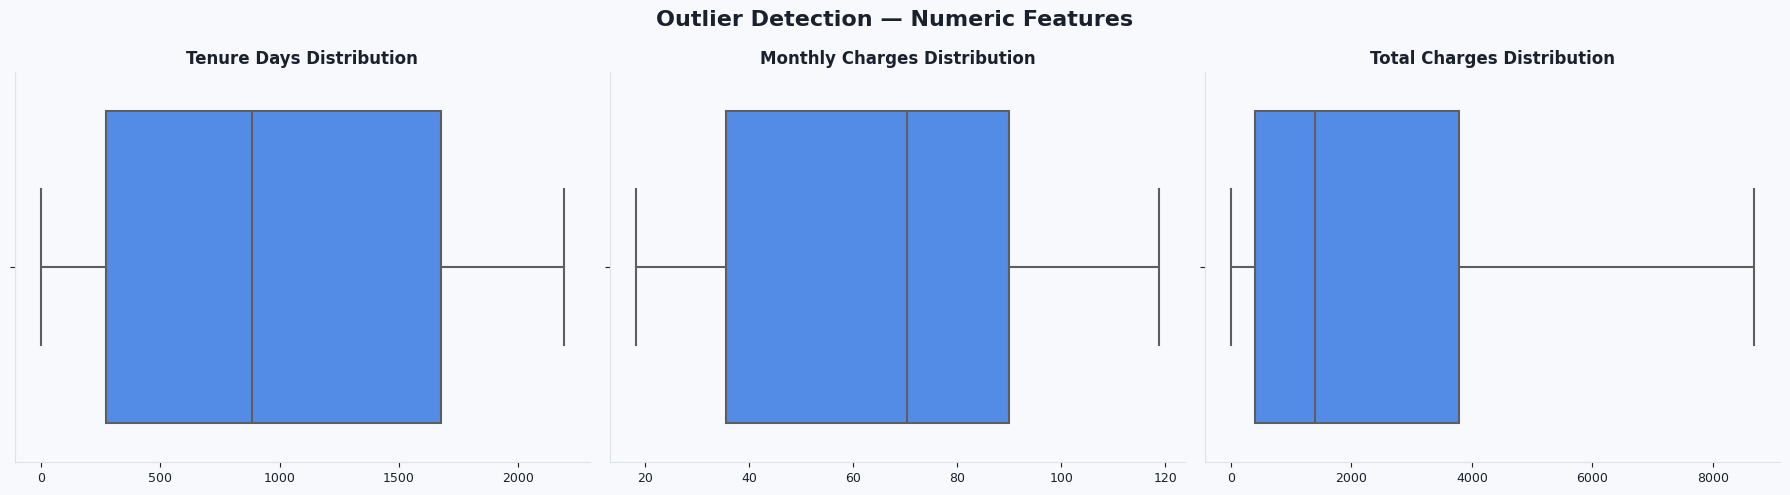

In [51]:
print("Descriptive Statistics:")
display(df_eda.describe(percentiles=[.25, .5, .75, .9, .95, .99]).T)

# ── Outlier detection — boxplots ──────────────────────────────────────
NUM_COLS = ['tenure_days', 'monthly_charges', 'total_charges']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=C_BG)
fig.suptitle('Outlier Detection — Numeric Features',
             fontsize=16, fontweight='bold')

for i, col in enumerate(NUM_COLS):
    sns.boxplot(x=df_eda[col], ax=axes[i], color=C_ACTIVE,
                fliersize=5, linewidth=1.5,
                flierprops=dict(markerfacecolor=C_CHURN, marker='o'))
    axes[i].set_title(f'{col.replace("_", " ").title()} Distribution')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()


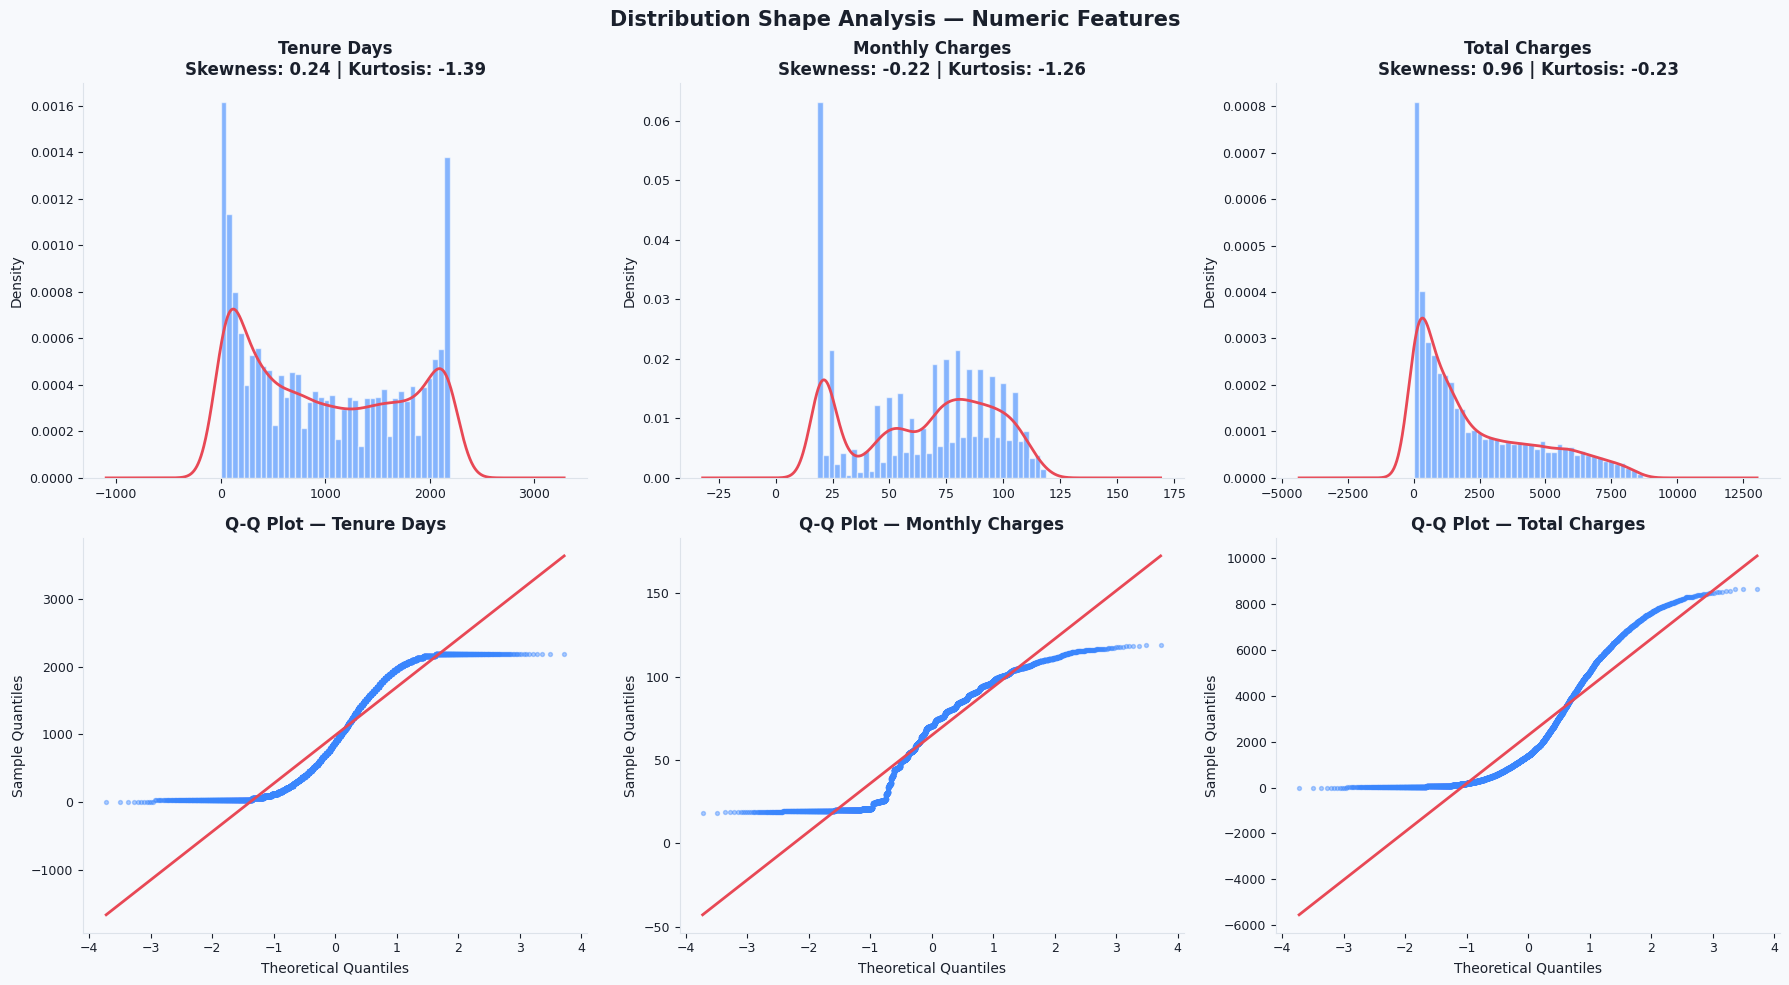

───────────────────────────────────────────────────────
  SKEWNESS SUMMARY
───────────────────────────────────────────────────────
  Feature                Skewness       Interpretation
───────────────────────────────────────────────────────
  tenure_days               0.239 Approximately normal
  monthly_charges          -0.220 Approximately normal
  total_charges             0.963        Moderate skew
───────────────────────────────────────────────────────


In [20]:
# ── Distribution shape analysis — skewness & normality ───────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor=C_BG)
fig.suptitle("Distribution Shape Analysis — Numeric Features",
             fontsize=15, fontweight="bold")

for i, col in enumerate(NUM_COLS):
    data     = df_eda[col].dropna()
    skewness = stats.skew(data)
    kurt     = stats.kurtosis(data)

    # Top row — histogram + KDE
    axes[0, i].hist(data, bins=40, color=C_ACTIVE,
                    alpha=0.6, edgecolor="white", density=True)
    data.plot.kde(ax=axes[0, i], color=C_CHURN, linewidth=2)
    axes[0, i].set_title(
        f"{col.replace('_', ' ').title()}\n"
        f"Skewness: {skewness:.2f} | Kurtosis: {kurt:.2f}"
    )
    axes[0, i].set_ylabel("Density")

    # Bottom row — Q-Q plot
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist="norm")
    axes[1, i].scatter(osm, osr, color=C_ACTIVE, alpha=0.4, s=8)
    axes[1, i].plot(osm, slope * np.array(osm) + intercept,
                    color=C_CHURN, linewidth=2)
    axes[1, i].set_title(f"Q-Q Plot — {col.replace('_', ' ').title()}")
    axes[1, i].set_xlabel("Theoretical Quantiles")
    axes[1, i].set_ylabel("Sample Quantiles")

plt.tight_layout()
plt.show()

# ── Skewness summary ──────────────────────────────────────────────────
print(f"{'─'*55}")
print(f"  SKEWNESS SUMMARY")
print(f"{'─'*55}")
print(f"  {'Feature':<20} {'Skewness':>10} {'Interpretation':>20}")
print(f"{'─'*55}")
for col in NUM_COLS:
    sk = stats.skew(df_eda[col].dropna())
    if abs(sk) < 0.5:
        interp = "Approximately normal"
    elif abs(sk) < 1.0:
        interp = "Moderate skew"
    else:
        interp = "High skew — consider log"
    print(f"  {col:<20} {sk:>10.3f} {interp:>20}")
print(f"{'─'*55}")

### **Key findings from descriptive analysis:**

1. *Distribution Shape Analysis:*
   - Tenure_days (skewness: 0.24): Exhibits a clear bimodal structure: one peak representing new customers and a second peak representing long-tenure loyal customers (2,191 days). Despite low skewness, the bimodal nature confirms the data captures distinct market segments, deviating from a standard normal distribution. 
   - Monthly_charges (skewness: -0.22): A bimodal distribution reflecting two defined customer segments: basic plans (~$20) and premium plans (~$80). This bimodality is a powerful predictive signal. 
   - Total_charges (skewness: 0.96): Displays moderate positive skew, driven by a concentration of new customers with minimal billing history and a "tail" of high-value, long-tenure customers. Tree-based models handle this distribution natively.

2. *Correlation and Feature Insights:*

- Tenure vs Total Charges (r=0.83): strong positive correlation —
  longer-tenured customers generate significantly more lifetime revenue,
  confirming tenure as a high-value retention metric.
- Monthly Charges vs Churn (r=0.19): higher monthly billing increases
  churn probability — we are losing our highest-revenue customers.
- Tenure vs Churn (r=-0.35): new customers are the most fragile segment.
  Early lifecycle intervention is critical to reduce attrition.
- Total Charges vs Churn (r=-0.20): customers with higher cumulative
  spend churn less — lifetime value and loyalty are correlated.
- No aggressive outliers detected** across numeric features. The right
  tail in `total_charges` reflects natural cumulative spend behavior,
  not data error. 99th percentile: max monthly charge $114.73,
  max tenure 2191 days.

### 2.2 Correlation & Multicollinearity Analysis

Before segmenting customers by demographics and behavior, we examine the mathematical relationships between all features and the churn target. This analysis serves two purposes:

1. **Multicollinearity detection** — highly correlated features can inflate feature importance in linear models and create redundant signal
2. **Pre-EDA feature ranking** — quantifying the raw association between each feature and churn guides where to focus the deeper segmentation analysis

Three association methods are applied in sequence:

| Method | Variables | Metric |
|--------|-----------|--------|
| Pearson correlation | Numeric ↔ Numeric | r ∈ [−1, 1] |
| Point-biserial | Numeric → Churn (binary) | r ∈ [−1, 1] |
| Cramér's V (bias-corrected) | Categorical → Churn | V ∈ [0, 1] |

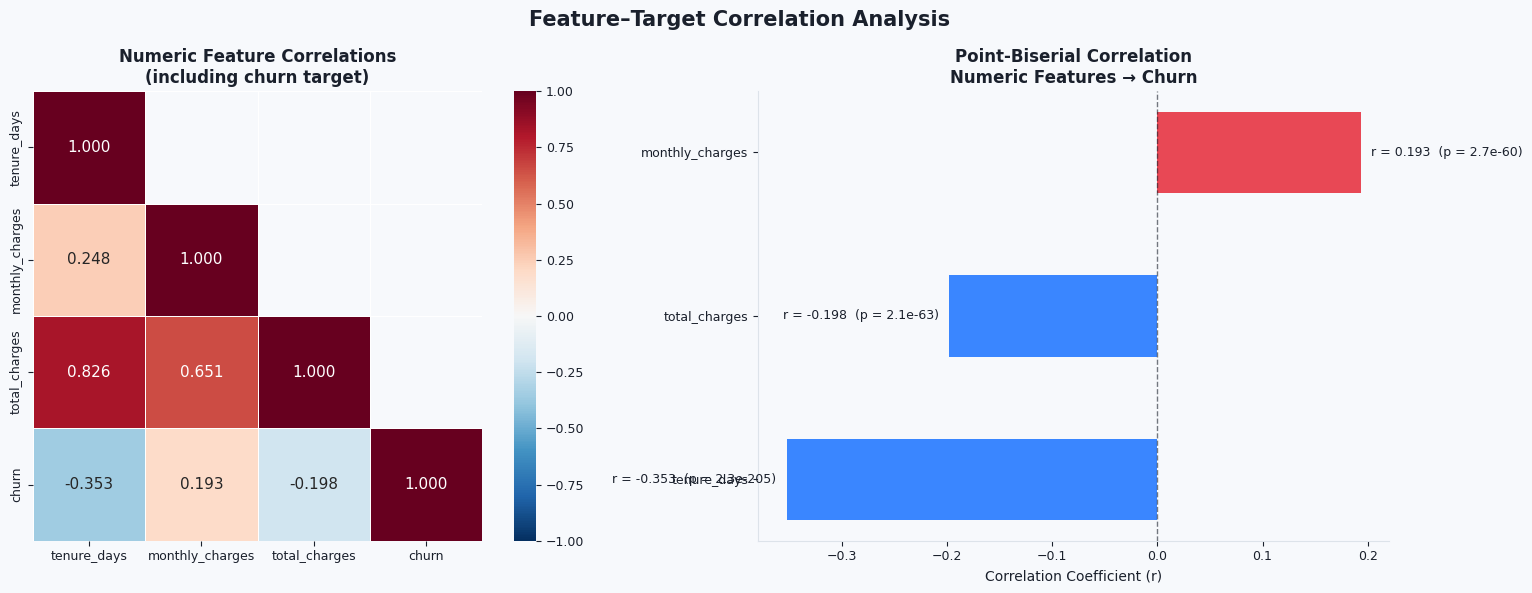

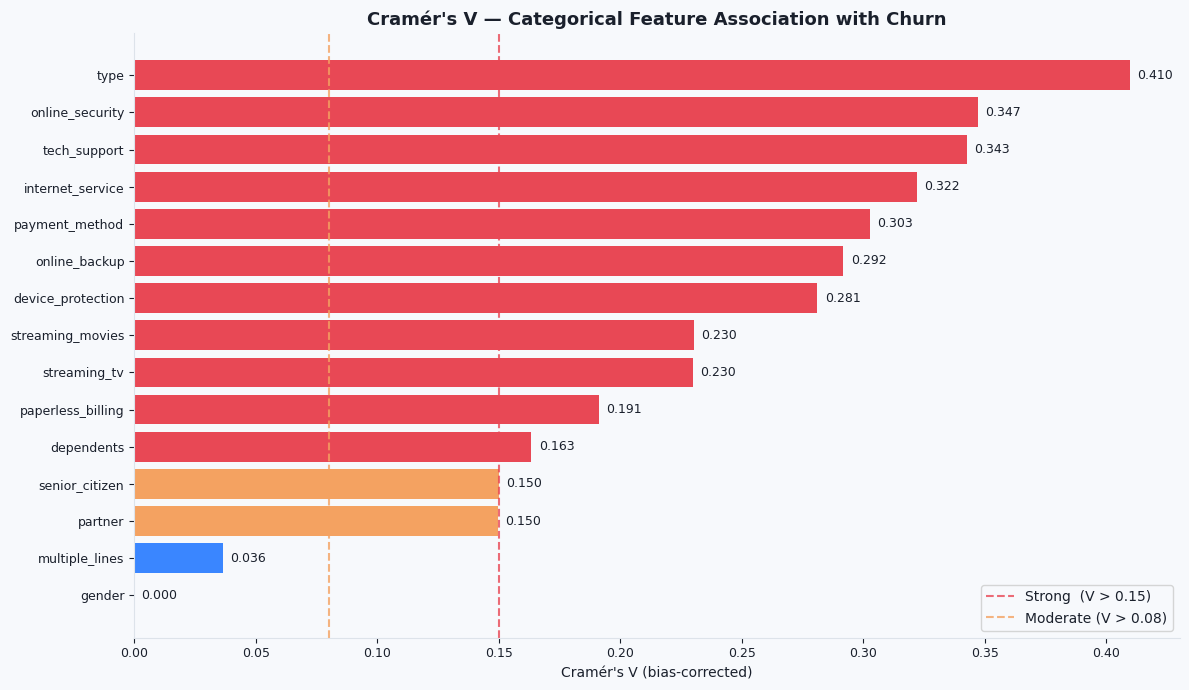


  TOP CATEGORICAL ASSOCIATIONS BY CRAMÉR'S V:
          Feature  Cramers_V
             type   0.409769
  online_security   0.346991
     tech_support   0.342502
 internet_service   0.322014
   payment_method   0.302656
    online_backup   0.291829
device_protection   0.281075
 streaming_movies   0.230335
     streaming_tv   0.229885
paperless_billing   0.191127
       dependents   0.163437
   senior_citizen   0.149980
          partner   0.149652
   multiple_lines   0.036397
           gender   0.000000


In [52]:
# ── A. Numeric correlation heatmap ────────────────────────────────────────────

corr_matrix = df_eda[NUM_COLS + ['churn']].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=C_BG)
fig.suptitle('Feature–Target Correlation Analysis',
             fontsize=15, fontweight='bold', color=C_TEXT)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, ax=axes[0],
    annot=True, fmt='.3f',
    cmap='RdBu_r', vmin=-1, vmax=1,
    linewidths=0.5, square=True, mask=mask,
    annot_kws={'size': 11},
)
axes[0].set_title('Numeric Feature Correlations\n(including churn target)',
                  fontweight='bold', color=C_TEXT)
axes[0].tick_params(colors=C_TEXT, labelsize=9)

# ── B. Point-biserial: each numeric feature → churn ──────────────────────────
pb_rows = []
for col in NUM_COLS:
    r, p = pointbiserialr(df_eda[col], df_eda['churn'])
    pb_rows.append({'Feature': col, 'r': r, 'p_value': p})

pb_df = pd.DataFrame(pb_rows).sort_values('r')
colors_pb = [C_CHURN if r > 0 else C_ACTIVE for r in pb_df['r']]
bars = axes[1].barh(pb_df['Feature'], pb_df['r'], color=colors_pb, height=0.5)
axes[1].axvline(0, color=C_TEXT, lw=1, ls='--', alpha=0.6)
axes[1].set_title('Point-Biserial Correlation\nNumeric Features → Churn',
                  fontweight='bold', color=C_TEXT)
axes[1].set_xlabel('Correlation Coefficient (r)', color=C_TEXT)
for bar, row in zip(bars, pb_df.itertuples()):
    offset = 0.01 if row.r > 0 else -0.01
    align  = 'left' if row.r > 0 else 'right'
    axes[1].text(row.r + offset, bar.get_y() + bar.get_height() / 2,
                 f'r = {row.r:.3f}  (p = {row.p_value:.1e})',
                 va='center', ha=align, fontsize=9, color=C_TEXT)

plt.tight_layout()
plt.show()

# ── C. Cramér's V — categorical features → churn ─────────────────────────────
def cramers_v(x, y):
    """Bias-corrected Cramér's V association coefficient."""
    ct   = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(ct)[0]
    n    = ct.values.sum()
    k, r = ct.shape
    phi2 = max(0, (chi2 / n) - ((k - 1) * (r - 1)) / (n - 1))
    return float(np.sqrt(phi2 / min(k - 1, r - 1)))

cat_assoc = [
    c for c in df_eda.select_dtypes(include=['category', 'object']).columns
    if c != 'customer_id'
]
cv_rows = [
    {'Feature': c, "Cramers_V": cramers_v(df_eda[c].astype(str), df_eda['churn'])}
    for c in cat_assoc
]
cv_df = pd.DataFrame(cv_rows).sort_values('Cramers_V', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7), facecolor=C_BG)
colors_v = [
    C_CHURN if v > 0.15 else (C_MID if v > 0.08 else C_ACTIVE)
    for v in cv_df['Cramers_V']
]
bars = ax.barh(cv_df['Feature'], cv_df['Cramers_V'], color=colors_v)
ax.axvline(0.15, color=C_CHURN, lw=1.5, ls='--', alpha=0.8,
           label='Strong  (V > 0.15)')
ax.axvline(0.08, color=C_MID,   lw=1.5, ls='--', alpha=0.8,
           label='Moderate (V > 0.08)')
for bar, val in zip(bars, cv_df['Cramers_V']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9, color=C_TEXT)
ax.set_title("Cramér's V — Categorical Feature Association with Churn",
             fontsize=13, fontweight='bold', color=C_TEXT)
ax.set_xlabel("Cramér's V (bias-corrected)", color=C_TEXT)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("\n  TOP CATEGORICAL ASSOCIATIONS BY CRAMÉR'S V:")
print(cv_df.sort_values('Cramers_V', ascending=False).to_string(index=False))

**Correlation & Association Analysis — Key Findings:**

- **`tenure_days` ↔ `total_charges`** (r ≈ +0.83): Expected multicollinearity — longer-tenured customers have simply paid more in total. Both features are retained because LightGBM handles multicollinearity via feature importance at split time.
- **`tenure_days` → churn** (r ≈ −0.35): The strongest numeric signal — longer-tenured customers churn significantly less. 
- **`monthly_charges` → churn** (r ≈ +0.19): Higher charges correlate with churn; Fiber Optic customers drive this signal.
- **Contract `type`** (Cramér's V ≈ 0.40): The single strongest categorical predictor — Month-to-month contracts carry dramatically higher churn risk.
- **`online_security` / `tech_support`** (V ≈ 0.15–0.20): Service bundle adoption is a meaningful retention signal — customers with these add-ons are stickier.
- **`gender`** (V < 0.01): Near-zero association — gender adds noise, not signal, and is a candidate for removal in Section 4 feature selection.


### 2.3 Demographic Profile — Gender, Senior Citizen, Partner, Dependents
Demographic segmentation reveals which customer profiles carry
structurally higher churn risk. Each variable is analyzed from two
angles: internal distribution (what percentage of each group churns)
and comparative churn rate against the global average (26.5%).

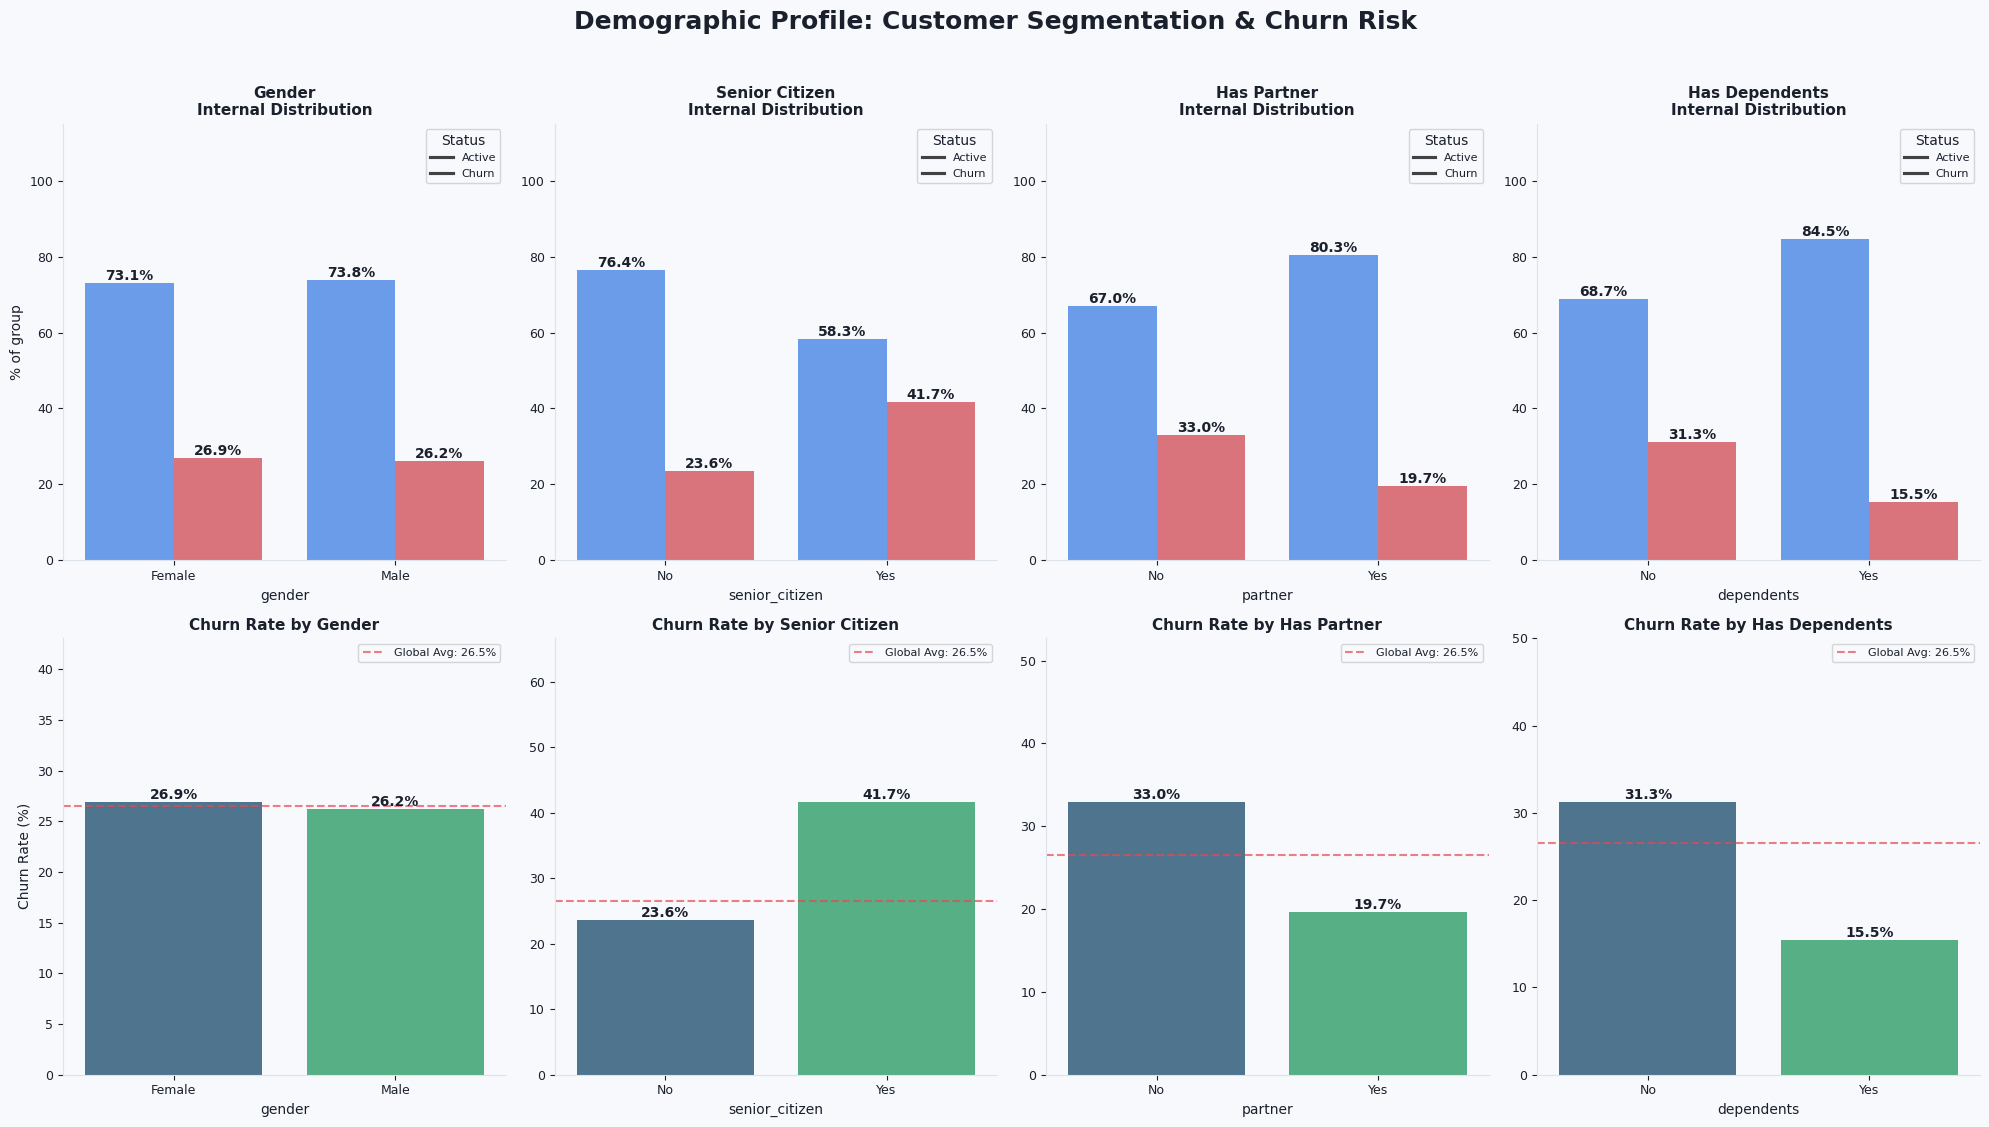

In [53]:
global_avg = df_eda['churn'].mean()

def add_labels(ax):
    """Add percentage labels on top of each bar."""
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(f'{h:.1f}%',
                        (p.get_x() + p.get_width() / 2., h),
                        ha='center', va='bottom',
                        fontsize=10, fontweight='bold')

DEMO_COLS   = ['gender', 'senior_citizen', 'partner', 'dependents']
DEMO_LABELS = ['Gender', 'Senior Citizen', 'Has Partner', 'Has Dependents']

fig = plt.figure(figsize=(20, 11), facecolor=C_BG)
fig.suptitle('Demographic Profile: Customer Segmentation & Churn Risk',
             fontsize=18, fontweight='bold', y=1.02)

for i, col in enumerate(DEMO_COLS):
    # Row 0: Internal distribution
    ax0 = fig.add_subplot(2, 4, i+1)
    df_pct = (df_eda.groupby(col, observed=True)['churn']
                .value_counts(normalize=True)
                .mul(100).rename('percent').reset_index())
    sns.barplot(data=df_pct, x=col, y='percent', hue='churn',
                palette={1: C_CHURN, 0: C_ACTIVE}, ax=ax0, alpha=0.85)
    ax0.set_title(f'{DEMO_LABELS[i]}\nInternal Distribution', fontsize=11)
    ax0.set_ylim(0, 115)
    ax0.set_ylabel('% of group' if i == 0 else '')
    ax0.legend(title='Status', labels=['Active', 'Churn'], fontsize=8)
    add_labels(ax0)

    # Row 1: Churn rate vs global average
    ax1 = fig.add_subplot(2, 4, i+5)
    cr_data = (df_eda.groupby(col, observed=True)['churn']
                 .mean().mul(100).reset_index())
    sns.barplot(data=cr_data, x=col, y='churn', ax=ax1,
                palette='viridis', alpha=0.9)
    ax1.axhline(global_avg * 100, color=C_CHURN, linestyle='--',
                alpha=0.7, label=f'Global Avg: {global_avg*100:.1f}%')
    ax1.set_title(f'Churn Rate by {DEMO_LABELS[i]}', fontsize=11)
    ax1.set_ylabel('Churn Rate (%)' if i == 0 else '')
    ax1.set_ylim(0, cr_data['churn'].max() * 1.6)
    ax1.legend(fontsize=8, loc='upper right')
    add_labels(ax1)

plt.tight_layout()
plt.show()

In [54]:
# Create a crosstab to analyze combined Churn risk
segment_risk = pd.crosstab(
    index=[df_eda['senior_citizen'], df_eda['dependents']],
    columns=df_eda['churn'],
    normalize='index'  # This returns the percentage by row
)

# Filter specifically for Seniors ('Yes') and those without Dependents ('No')
# We select the risk value for the Churn column (index 1)
risk_value = segment_risk.loc[('Yes', 'No'), 1] * 100

print(f"The churn risk for this segment is: {risk_value:.1f}%")

The churn risk for this segment is: 43.2%


**Demographic Segment Risk — Marketing Intelligence:**

- **Senior Citizens** are the highest-risk segment at **41.7% churn**,
  nearly double the global average. Targeted retention strategies —
  simplified plans, dedicated technical support — are critical for this group.
- Customers with **dependents (15.5%)** and **partners (19.7%)** are
  significantly more loyal. Family plan incentives could anchor single
  customers to reduce their 30%+ churn exposure.
- **Gender shows no meaningful difference** (Male 26.2% vs Female 26.9%) —
  gender should not be a retention targeting variable and carries no
  predictive weight for the model.
- Customers **without partner or dependents** exceed 30% churn —
  they are most susceptible to competitor offers and price sensitivity.

> **Retention action:** Senior citizens without dependents represent the
> highest-priority intervention target — combine the two risk factors
> and the churn probability exceeds 43%.

### 2.4 Contractual Behavior — Contract Type, Billing & Payment Method
Contract structure and payment behavior are the most actionable levers
available to the retention team — unlike demographics, these can be
directly influenced through targeted offers and plan migration incentives.

Five dimensions are analyzed: contract type, payment method, monthly
charge distribution by churn status, paperless billing impact, and the
critical intersection of contract × payment method.

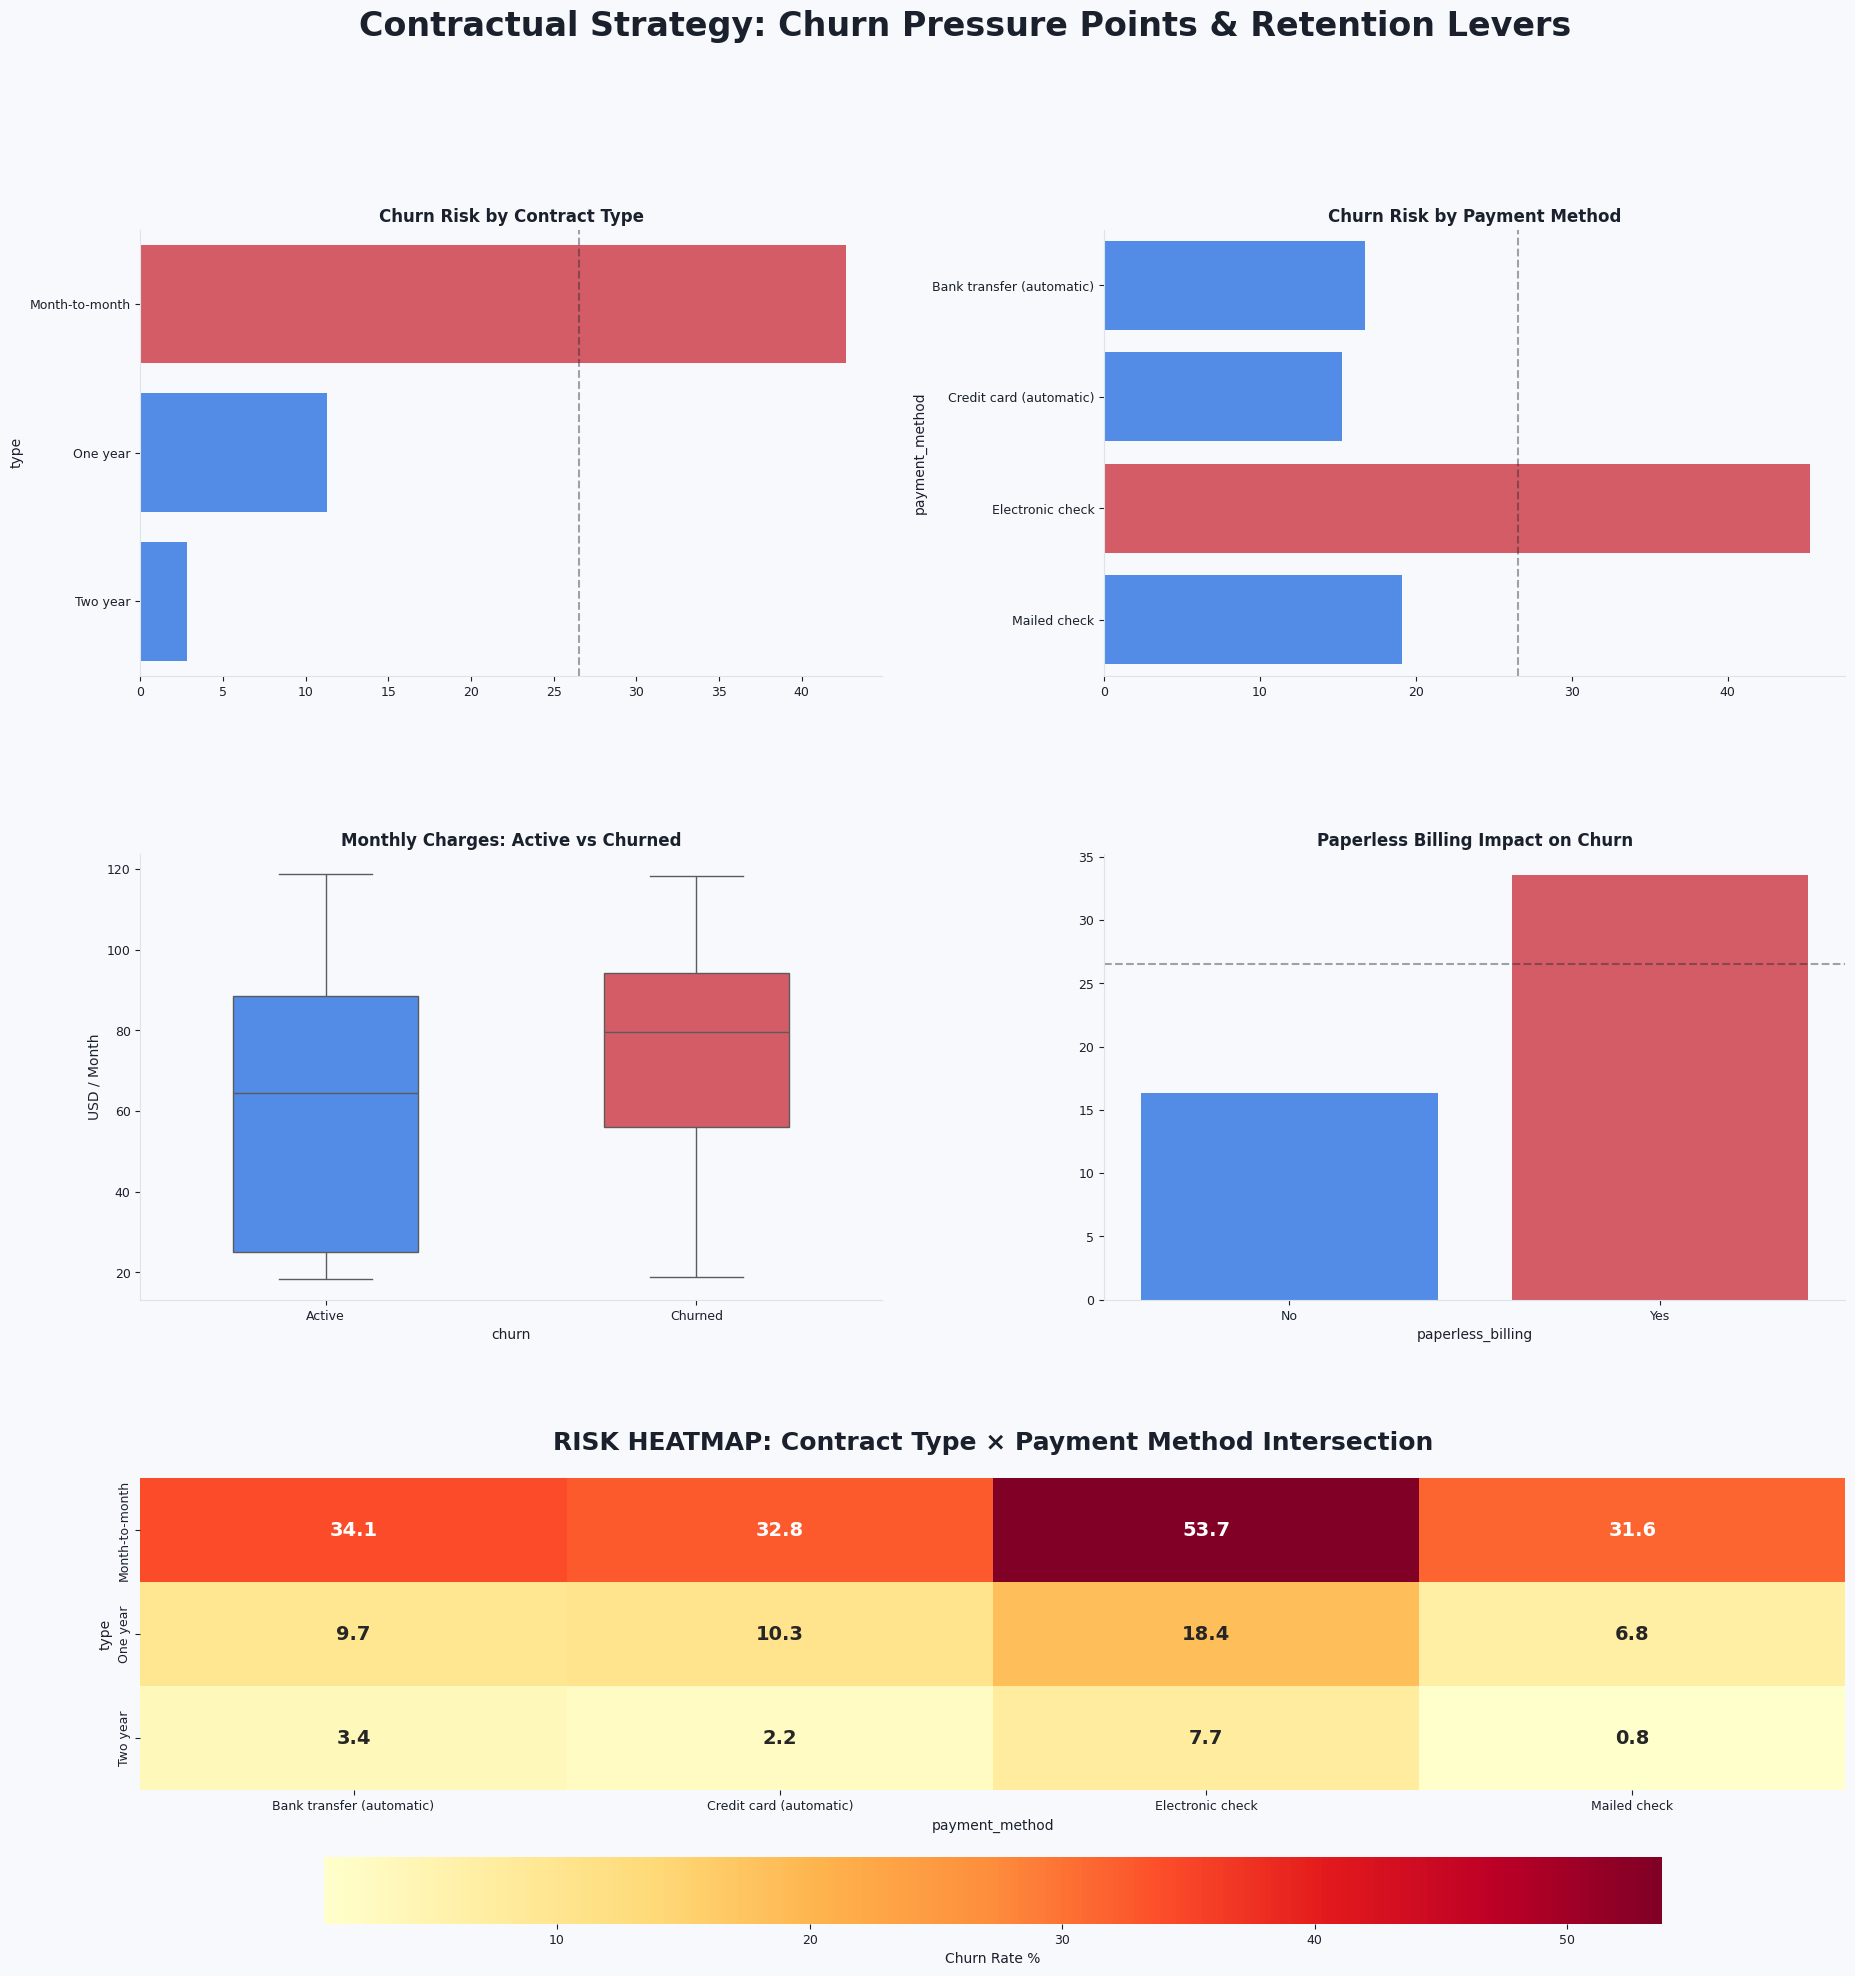

In [55]:
global_avg    = df_eda['churn'].mean()
avg_churn_pct = global_avg * 100

fig = plt.figure(figsize=(22, 22), facecolor=C_BG)
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3)
fig.suptitle('Contractual Strategy: Churn Pressure Points & Retention Levers',
             fontsize=24, fontweight='bold', color=C_TEXT, y=0.98)

# A. Churn risk by contract type
ax1 = fig.add_subplot(gs[0, 0])
contract_risk    = df_eda.groupby('type', observed=True)['churn'].mean().mul(100).sort_values(ascending=False)
palette_contract = {idx: (C_CHURN if val > avg_churn_pct else C_ACTIVE)
                    for idx, val in contract_risk.items()}
sns.barplot(x=contract_risk.values, y=contract_risk.index,
            palette=palette_contract, ax=ax1, hue=contract_risk.index)
if ax1.get_legend(): ax1.get_legend().remove()
ax1.axvline(avg_churn_pct, color=C_TEXT, linestyle='--', alpha=0.4)
ax1.set_title('Churn Risk by Contract Type')

# B. Churn risk by payment method
ax2 = fig.add_subplot(gs[0, 1])
pay_risk    = df_eda.groupby('payment_method', observed=True)['churn'].mean().mul(100).sort_values(ascending=False)
palette_pay = {idx: (C_CHURN if val > avg_churn_pct else C_ACTIVE)
               for idx, val in pay_risk.items()}
sns.barplot(x=pay_risk.values, y=pay_risk.index,
            palette=palette_pay, ax=ax2, hue=pay_risk.index)
if ax2.get_legend(): ax2.get_legend().remove()
ax2.axvline(avg_churn_pct, color=C_TEXT, linestyle='--', alpha=0.4)
ax2.set_title('Churn Risk by Payment Method')

# C. Monthly charges distribution by churn status
ax3 = fig.add_subplot(gs[1, 0])
sns.boxplot(data=df_eda, x='churn', y='monthly_charges',
            palette={0: C_ACTIVE, 1: C_CHURN},
            ax=ax3, width=0.5, hue='churn')
if ax3.get_legend(): ax3.get_legend().remove()
ax3.set_xticklabels(['Active', 'Churned'])
ax3.set_title('Monthly Charges: Active vs Churned')
ax3.set_ylabel('USD / Month')

# D. Paperless billing impact
ax4 = fig.add_subplot(gs[1, 1])
pb_risk    = df_eda.groupby('paperless_billing', observed=True)['churn'].mean().mul(100)
palette_pb = {idx: (C_CHURN if val > avg_churn_pct else C_ACTIVE)
              for idx, val in pb_risk.items()}
sns.barplot(x=pb_risk.index, y=pb_risk.values,
            palette=palette_pb, ax=ax4, hue=pb_risk.index)
if ax4.get_legend(): ax4.get_legend().remove()
ax4.axhline(avg_churn_pct, color=C_TEXT, linestyle='--', alpha=0.4)
ax4.set_title('Paperless Billing Impact on Churn')

# E. Heatmap — contract type x payment method intersection
ax5 = fig.add_subplot(gs[2, :])
pivot = df_eda.pivot_table(index='type', columns='payment_method',
                       values='churn', observed=True).mul(100)
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax5,
            annot_kws={'size': 14, 'weight': 'bold'},
            cbar_kws={'label': 'Churn Rate %',
                      'orientation': 'horizontal', 'pad': 0.15})
ax5.set_title('RISK HEATMAP: Contract Type × Payment Method Intersection',
              fontsize=18, fontweight='bold', pad=20)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Contractual Risk Intelligence:**

- **Month-to-month contracts** carry a 40%+ churn rate vs under 5% for
  two-year contracts. Any incentive converting a monthly customer to an
  annual plan directly attacks the highest churn pressure point.
- **Electronic Check** is the riskiest payment method (~45% churn).
  Automatic payment methods (credit card, bank transfer) show the lowest
  rates — customers who automate payments stay; those who act manually leave.
- **Red Zone — Heatmap:** Month-to-month + Electronic Check is the
  single highest-risk customer profile. This segment demands an
  immediate rescue campaign.
- **Revenue erosion:** Churned customers have a higher median monthly
  charge than active customers — we are not losing low-value accounts,
  we are losing our **highest ARPU customers**.
- **Paperless billing** correlates with higher churn (~33.5%) — the
  physical bill may function as an indirect retention mechanism through
  tangible engagement.

> **Retention action:** Prioritize outreach to Month-to-month +
> Electronic Check customers. A single plan migration to annual contract
> reduces their churn probability by ~35 percentage points.

### 2.5 Customer Lifecycle — Tenure Patterns, Survival & Value Mapping

Tenure is the single most informative continuous feature in this dataset.
This section analyzes three dimensions of customer lifecycle:

- **Density distribution** — when do churners leave vs when do loyal
  customers stabilize?
- **Lifecycle stage risk** — churn rate segmented into actionable
  business windows (onboarding, growth, mature, loyal)
- **Value map** — cumulative revenue vs tenure colored by churn status,
  revealing the financial cost of early attrition
- **Survival analysis** — Kaplan-Meier curve by contract type shows
  the probability of retaining a customer beyond key tenure thresholds
- **Churn events timeline** — when did customers actually leave?


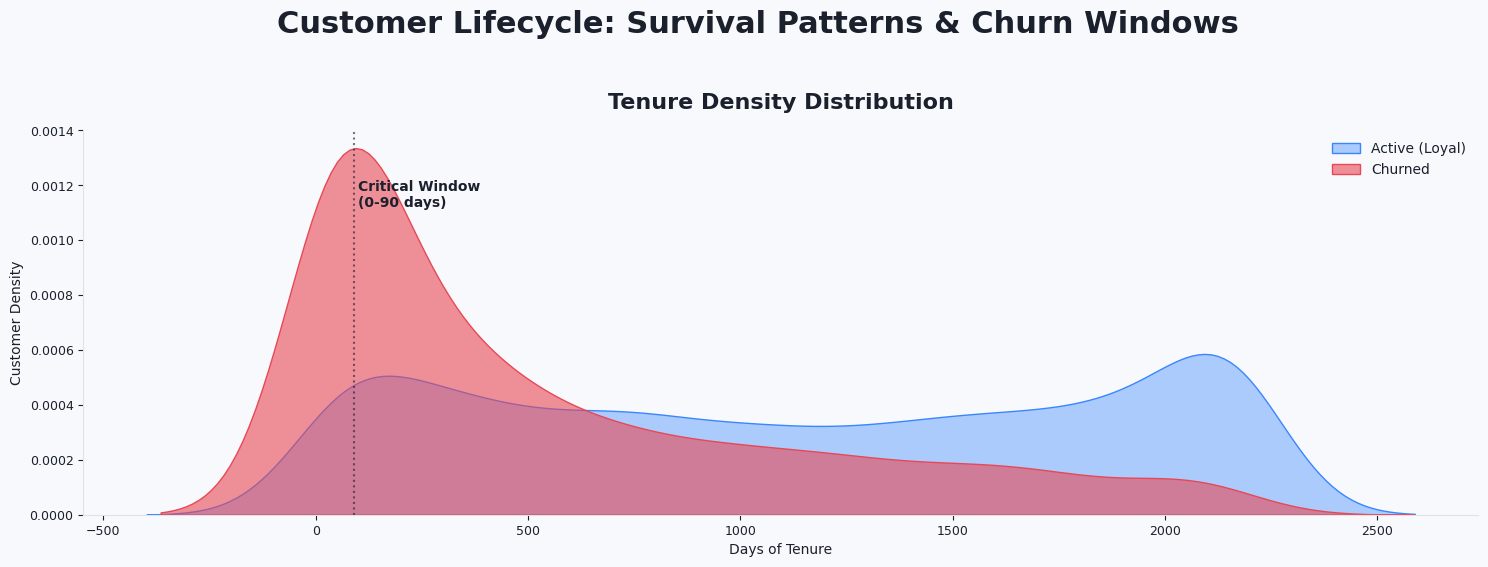

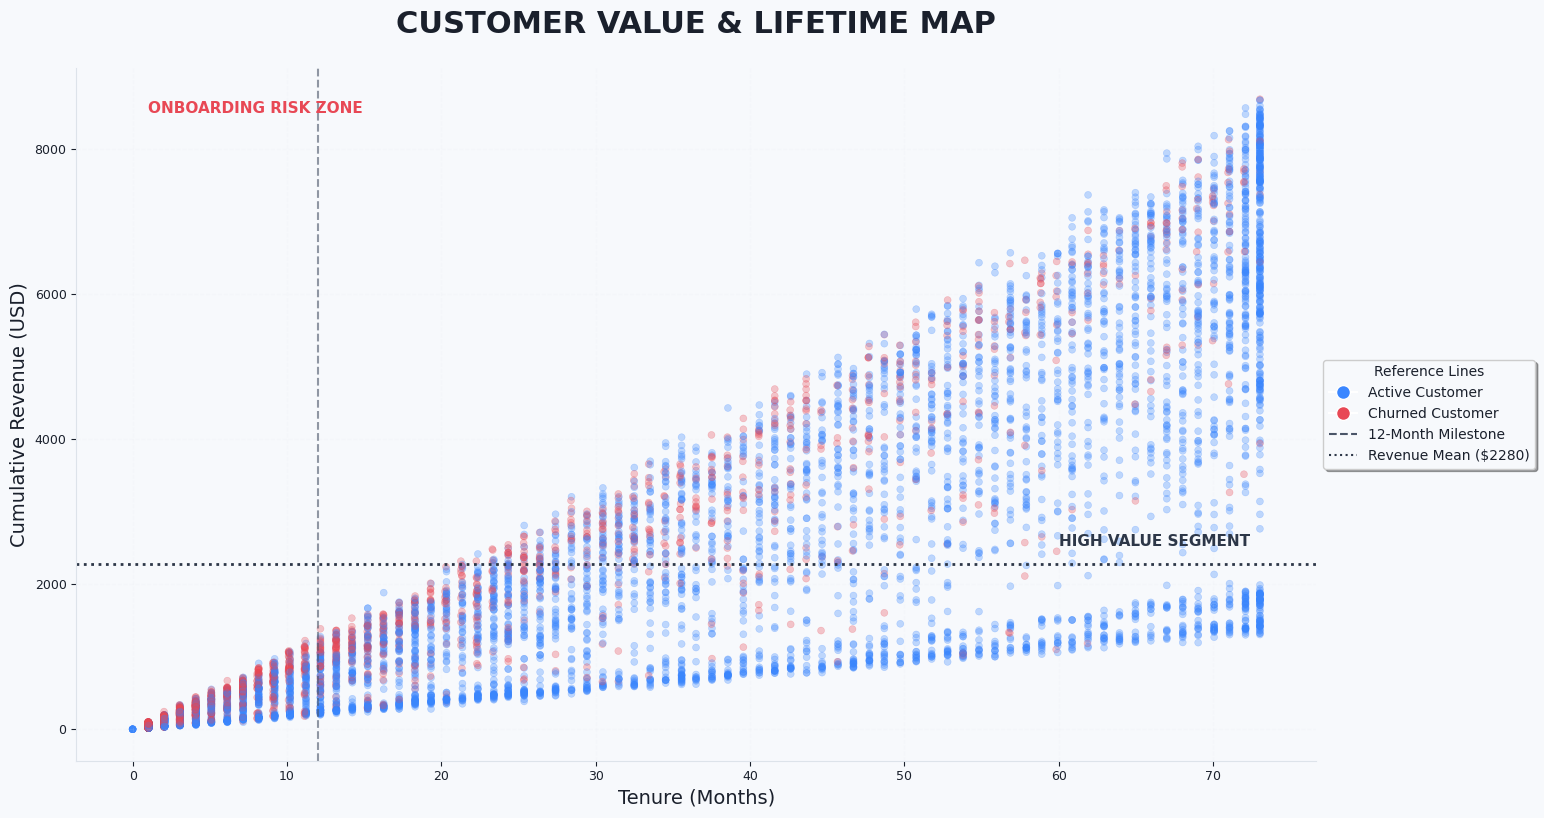

In [56]:
fig = plt.figure(figsize=(18, 12), facecolor=C_BG)
gs  = gridspec.GridSpec(2, 1, figure=fig, hspace=0.4)
fig.suptitle('Customer Lifecycle: Survival Patterns & Churn Windows',
             fontsize=22, fontweight='bold', color=C_TEXT, y=0.98)

# KDE density curves
ax1 = fig.add_subplot(gs[0, 0])
sns.kdeplot(data=df_eda[df_eda['churn'] == 0], x='tenure_days', fill=True,
            color=C_ACTIVE, label='Active (Loyal)', ax=ax1, alpha=0.4)
sns.kdeplot(data=df_eda[df_eda['churn'] == 1], x='tenure_days', fill=True,
            color=C_CHURN, label='Churned', ax=ax1, alpha=0.6)
ax1.axvline(90, color=C_TEXT, linestyle=':', alpha=0.6)
ax1.text(100, ax1.get_ylim()[1] * 0.8, 'Critical Window\n(0-90 days)',
         color=C_TEXT, fontweight='bold')
ax1.set_title('Tenure Density Distribution', fontsize=16, pad=15)
ax1.set_xlabel('Days of Tenure')
ax1.set_ylabel('Customer Density')
ax1.legend(frameon=False)


# tenure_months for scatter plot
df_eda['tenure_months'] = df_eda['tenure_days'] / 30

# Value map scatter
MEDIA_TOTAL_CHARGES = df_eda['total_charges'].mean()

plt.figure(figsize=(16, 9), facecolor=C_BG)
sns.scatterplot(data=df_eda, x='tenure_months', y='total_charges',
                hue='churn', palette={0: C_ACTIVE, 1: C_CHURN},
                alpha=0.3, s=25, edgecolor=None)

plt.axvline(12, color='#4A5568', linestyle='--',
            linewidth=1.5, alpha=0.6)
plt.axhline(MEDIA_TOTAL_CHARGES, color='#2D3748',
            linestyle=':', linewidth=2)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Active Customer',
           markerfacecolor=C_ACTIVE, markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Churned Customer',
           markerfacecolor=C_CHURN, markersize=10),
    Line2D([0], [0], color='#4A5568', linestyle='--', label='12-Month Milestone'),
    Line2D([0], [0], color='#2D3748', linestyle=':',
           label=f'Revenue Mean (${MEDIA_TOTAL_CHARGES:.0f})')
]
plt.legend(handles=legend_elements, loc='center left',
           bbox_to_anchor=(1, 0.5), frameon=True, shadow=True,
           title='Reference Lines')

plt.text(1, 8500, 'ONBOARDING RISK ZONE',
         fontsize=11, color=C_CHURN, fontweight='bold')
plt.text(60, MEDIA_TOTAL_CHARGES + 250, 'HIGH VALUE SEGMENT',
         fontsize=11, color='#2D3748', fontweight='bold')

plt.title('CUSTOMER VALUE & LIFETIME MAP', fontsize=22,
          pad=25, fontweight='bold')
plt.xlabel('Tenure (Months)', fontsize=14)
plt.ylabel('Cumulative Revenue (USD)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.1)
sns.despine()
plt.show()


# tenure_months and tenure_range were created for EDA visualization only
# They will NOT be included in df_modeling — drop before feature engineering
df_eda.drop(columns=['tenure_range', 'tenure_months'], inplace=True, errors='ignore')

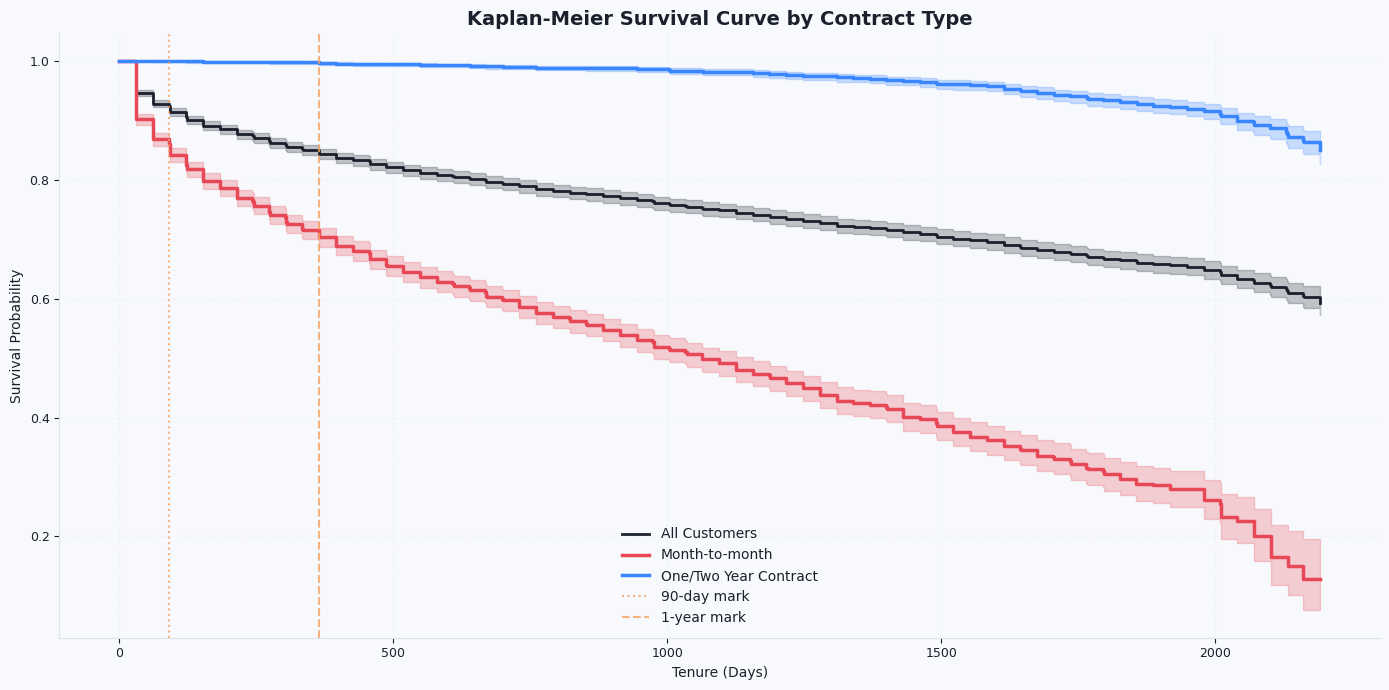

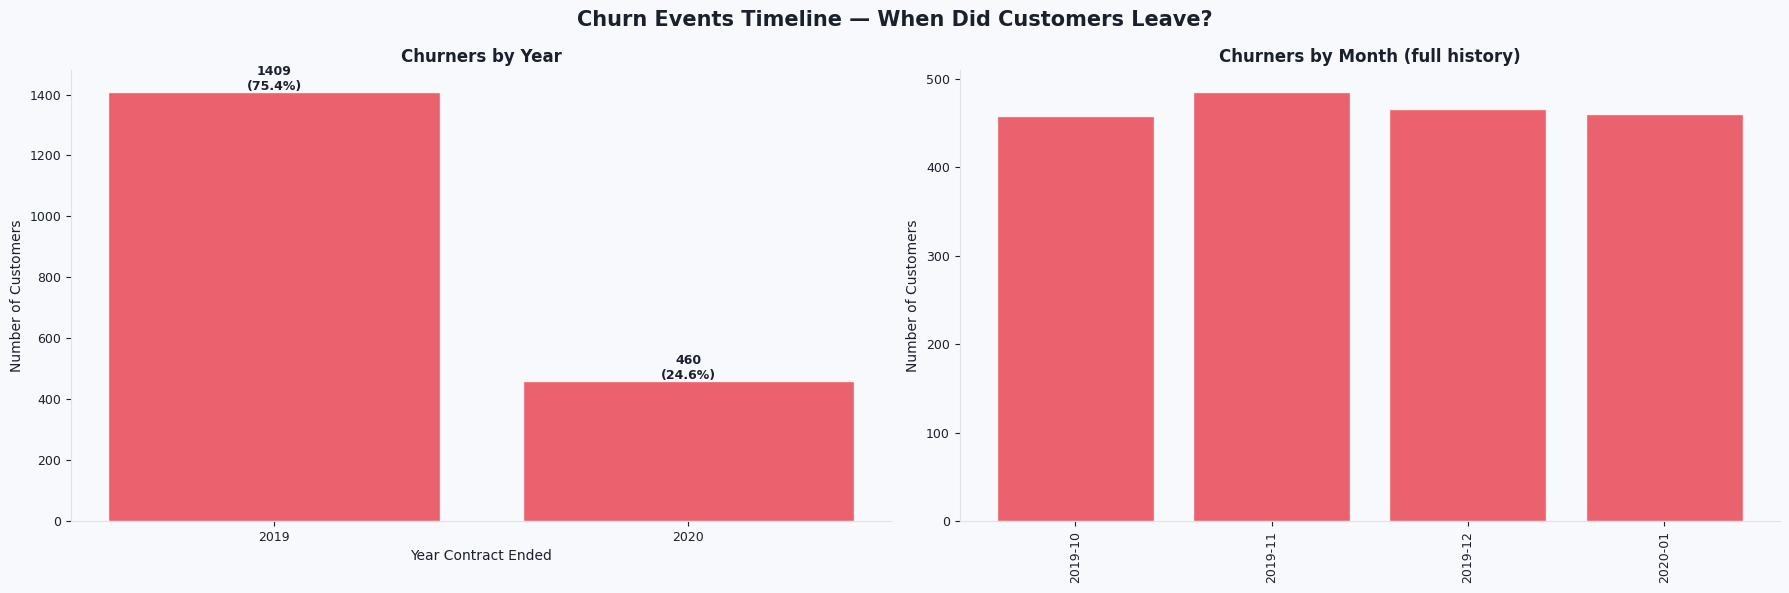

──────────────────────────────────────────────────
  CHURN EVENTS BY YEAR
──────────────────────────────────────────────────
  Year       Churners   % of total
──────────────────────────────────────────────────
  2019          1,409        75.4%
  2020            460        24.6%
──────────────────────────────────────────────────
  TOTAL         1,869       100.0%
──────────────────────────────────────────────────


In [57]:
# TEMPORAL ANALYSIS — Survival & Churn Events Timeline
# ── Kaplan-Meier Survival Curve by contract type ──────────────────
kmf_all     = KaplanMeierFitter()
kmf_monthly = KaplanMeierFitter()
kmf_annual  = KaplanMeierFitter()

mask_monthly = df_eda["type"].astype(str) == "Month-to-month"
mask_annual  = df_eda["type"].astype(str).isin(["One year", "Two year"])

kmf_all.fit(df_eda["tenure_days"],
            event_observed=df_eda["churn"],
            label="All Customers")
kmf_monthly.fit(df_eda.loc[mask_monthly, "tenure_days"],
                event_observed=df_eda.loc[mask_monthly, "churn"],
                label="Month-to-month")
kmf_annual.fit(df_eda.loc[mask_annual, "tenure_days"],
               event_observed=df_eda.loc[mask_annual, "churn"],
               label="One/Two Year Contract")

fig, ax = plt.subplots(figsize=(14, 7), facecolor=C_BG)
kmf_all.plot_survival_function(ax=ax, color=C_TEXT, linewidth=2)
kmf_monthly.plot_survival_function(ax=ax, color=C_CHURN, linewidth=2.5)
kmf_annual.plot_survival_function(ax=ax, color=C_ACTIVE, linewidth=2.5)

ax.axvline(90,  color=C_MID, linestyle=":",  alpha=0.8, label="90-day mark")
ax.axvline(365, color=C_MID, linestyle="--", alpha=0.8, label="1-year mark")
ax.set_xlabel("Tenure (Days)")
ax.set_ylabel("Survival Probability")
ax.set_title("Kaplan-Meier Survival Curve by Contract Type",
             fontsize=14, fontweight="bold")
ax.legend(frameon=False)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# ── Churn events timeline ─────────────────────────────────────────
df_churners = df_eda[df_eda["churn"] == 1].copy()

churn_by_year = (df_churners.groupby(df_churners["end_date"].dt.year)
                 .size().reset_index(name="churners"))
churn_by_year.columns = ["year", "churners"]
churn_by_year["pct"]  = churn_by_year["churners"] / len(df_churners) * 100

churn_by_month = (df_churners.groupby(
                      df_churners["end_date"].dt.to_period("M"))
                  .size())
churn_by_month.index = churn_by_month.index.astype(str)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor=C_BG)
fig.suptitle("Churn Events Timeline — When Did Customers Leave?",
             fontsize=15, fontweight="bold")

# By year
axes[0].bar(churn_by_year["year"].astype(str),
            churn_by_year["churners"],
            color=C_CHURN, alpha=0.85, edgecolor="white")
for i, row in churn_by_year.iterrows():
    axes[0].text(i, row["churners"] + 5,
                 f'{int(row["churners"])}\n({row["pct"]:.1f}%)',
                 ha="center", fontsize=9, fontweight="bold")
axes[0].set_title("Churners by Year")
axes[0].set_ylabel("Number of Customers")
axes[0].set_xlabel("Year Contract Ended")

# By month
axes[1].bar(churn_by_month.index, churn_by_month.values,
            color=C_CHURN, alpha=0.85, edgecolor="white")
axes[1].set_title("Churners by Month (full history)")
axes[1].set_ylabel("Number of Customers")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

print(f"{'─'*50}")
print(f"  CHURN EVENTS BY YEAR")
print(f"{'─'*50}")
print(f"  {'Year':<8} {'Churners':>10} {'% of total':>12}")
print(f"{'─'*50}")
for _, row in churn_by_year.iterrows():
    print(f"  {int(row['year']):<8} {int(row['churners']):>10,}"
          f" {row['pct']:>11.1f}%")
print(f"{'─'*50}")
print(f"  {'TOTAL':<8} {len(df_churners):>10,} {'100.0%':>12}")
print(f"{'─'*50}")

**Customer Lifecycle & Temporal Intelligence:**

- **Critical onboarding window:** The highest churn density occurs in
  the first 90 days. The 0-3 month segment shows the steepest churn
  rate — the customer leaves before the company recovers its acquisition
  cost. This is the highest-priority intervention window.
- **Stability threshold:** Risk stabilizes at 12-24 months of tenure.
  Customers crossing this milestone transition into the high-value
  segment, consistently exceeding the revenue mean of $2,280 USD.
- **Survival curve:** Month-to-month customers exhibit a significant decline in retention, with survival probability dropping to 70.3% by day 365. In contrast, customers with one or two-year contracts maintain a survival probability of 99.6% over the same period. This stark contrast confirms that contract type is the most critical lever for long-term customer retention.
- **Churn events are distributed across all years** — `end_date` is a
  contract end timestamp recorded at snapshot time (2020-02-01), not
  a real-time event stream. This is why a temporal train/test split
  is not appropriate for this dataset.
- **Two behavioral clusters confirmed:** an early high-risk zone
  below 12 months tenure, and a loyal high-revenue zone growing
  linearly with tenure.

> **Retention action:** Any intervention that extends a customer past
> the 90-day mark reduces churn probability significantly. Onboarding
> programs, early check-in calls, and first-month discount locks are
> the highest-ROI tools for this window.

### 2.6 Service Adoption — Internet, Add-ons & Phone Services

Service portfolio is the second most actionable retention lever after
contract type. This section examines three dimensions:

- **Internet service type** — DSL vs Fiber Optic vs No service
- **Add-on adoption gap** — which services do churners avoid that
  loyal customers actively use?
- **Ecosystem effect** — does bundling multiple services reduce
  churn probability multiplicatively?

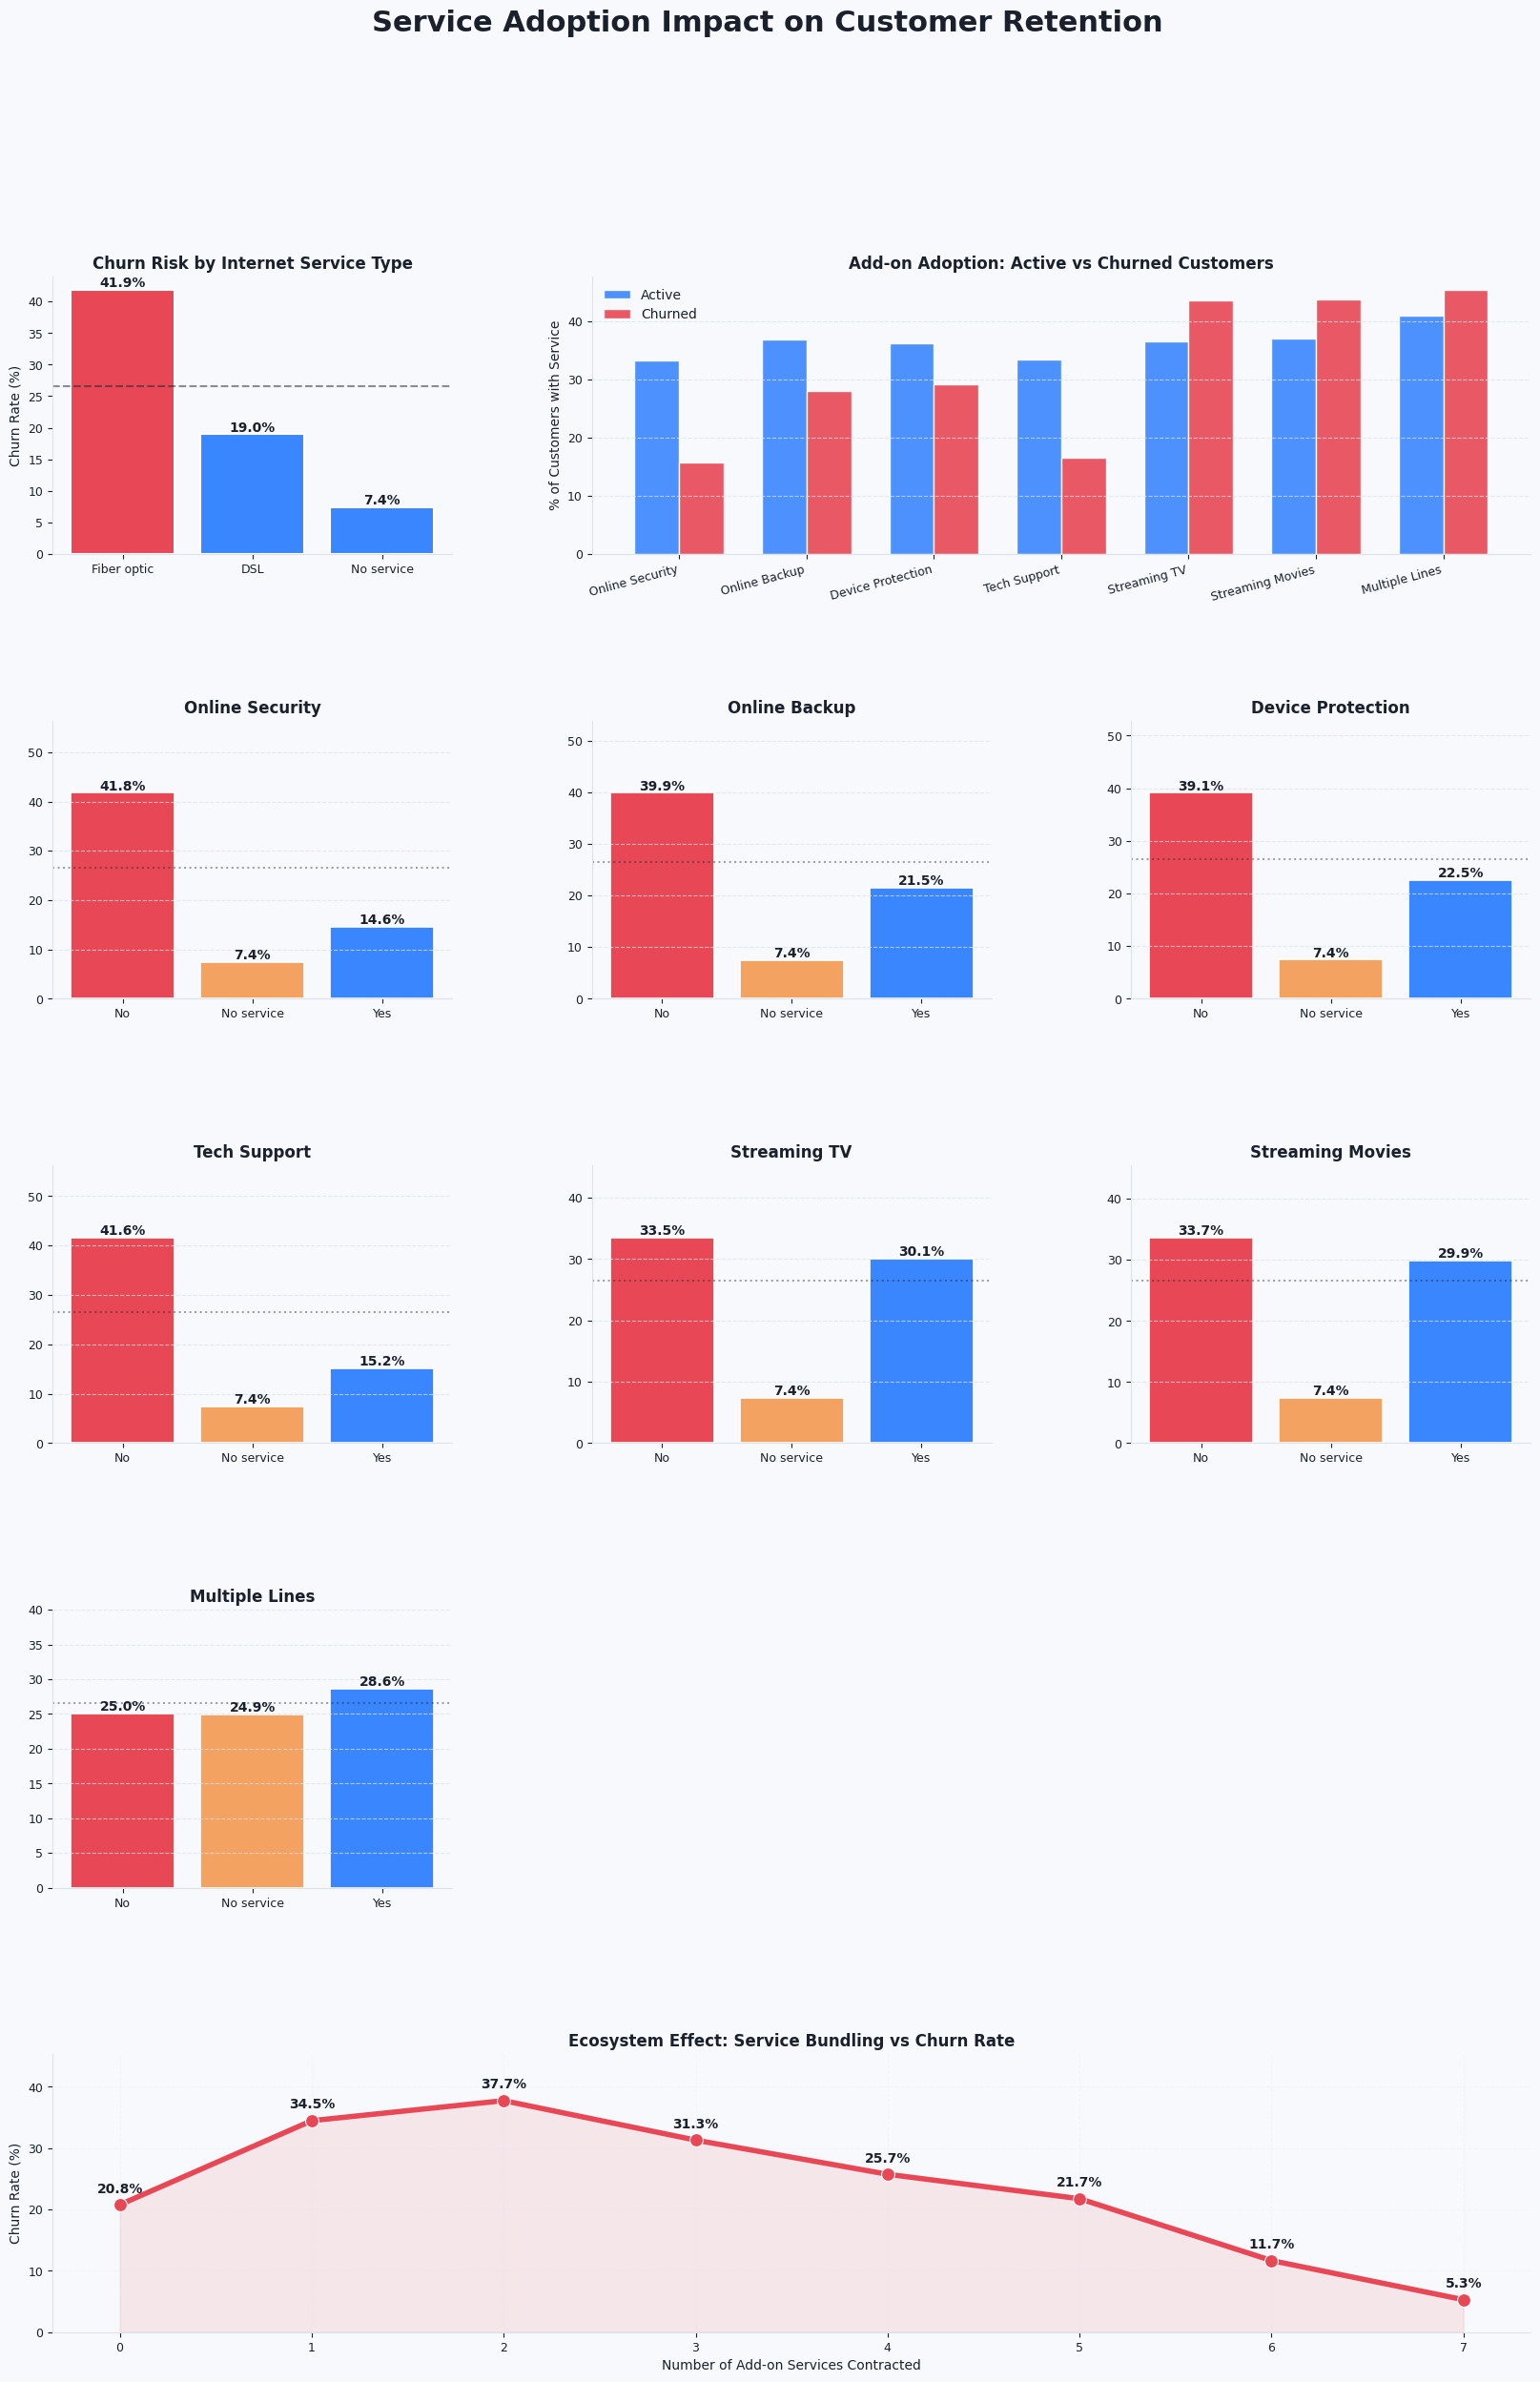

In [58]:
avg_pct     = global_avg * 100
ADDON_COLS  = ['online_security', 'online_backup', 'device_protection',
               'tech_support', 'streaming_tv', 'streaming_movies',
               'multiple_lines']
ADDON_LABELS = ['Online Security', 'Online Backup', 'Device Protection',
                'Tech Support', 'Streaming TV', 'Streaming Movies',
                'Multiple Lines']

fig = plt.figure(figsize=(20, 28), facecolor=C_BG)
fig.suptitle('Service Adoption Impact on Customer Retention',
             fontsize=22, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(5, 3, figure=fig, hspace=0.6, wspace=0.35)

# Churn by internet service type
ax1 = fig.add_subplot(gs[0, 0])
cr_is    = df_eda.groupby('internet_service', observed=True)['churn'].mean().mul(100).sort_values(ascending=False)
colors_is = [C_CHURN if x > avg_pct else C_ACTIVE for x in cr_is]
ax1.bar(cr_is.index, cr_is.values, color=colors_is,
        edgecolor='white', linewidth=1.5)
ax1.axhline(avg_pct, color=C_TEXT, linestyle='--', alpha=0.5)
ax1.set_title('Churn Risk by Internet Service Type')
ax1.set_ylabel('Churn Rate (%)')
add_labels(ax1)

# Add-on adoption: Active vs Churned
ax2 = fig.add_subplot(gs[0, 1:])
x           = np.arange(len(ADDON_LABELS))
width       = 0.35
pen_active  = [(df_eda[(df_eda['churn']==0) & (df_eda[col]=='Yes')].shape[0] /
                df_eda[df_eda['churn']==0].shape[0] * 100) for col in ADDON_COLS]
pen_churn   = [(df_eda[(df_eda['churn']==1) & (df_eda[col]=='Yes')].shape[0] /
                df_eda[df_eda['churn']==1].shape[0] * 100) for col in ADDON_COLS]

ax2.bar(x - width/2, pen_active, width, color=C_ACTIVE,
        label='Active', alpha=0.9, edgecolor='white')
ax2.bar(x + width/2, pen_churn, width, color=C_CHURN,
        label='Churned', alpha=0.9, edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels(ADDON_LABELS, rotation=15, ha='right')
ax2.set_ylabel('% of Customers with Service')
ax2.set_title('Add-on Adoption: Active vs Churned Customers')
ax2.legend(frameon=False)
ax2.yaxis.grid(True)

# Individual service breakdown
for k, (col, label) in enumerate(zip(ADDON_COLS, ADDON_LABELS)):
    row_idx = (k // 3) + 1
    col_idx = k % 3
    ax      = fig.add_subplot(gs[row_idx, col_idx])
    cr      = df_eda.groupby(col, observed=True)['churn'].mean().mul(100)

    colors_k = []
    for cat in cr.index:
        if any(w in cat.lower() for w in ['no internet', 'no phone', 'no service']):
            colors_k.append(C_MID)
        elif cat == 'Yes':
            colors_k.append(C_ACTIVE)
        else:
            colors_k.append(C_CHURN)

    ax.bar(cr.index, cr.values, color=colors_k,
           edgecolor='white', linewidth=1.2)
    ax.axhline(avg_pct, color=C_TEXT, linestyle=':', alpha=0.4)
    ax.set_title(label)
    ax.set_ylim(0, max(cr.max() * 1.35, 40))
    ax.yaxis.grid(True)
    add_labels(ax)

# Ecosystem effect — services count vs churn rate
ax_eco = fig.add_subplot(gs[4, :])
df_eda['services_count'] = (df_eda[ADDON_COLS] == 'Yes').sum(axis=1)
eco_data = df_eda.groupby('services_count')['churn'].mean().mul(100)

sns.lineplot(x=eco_data.index, y=eco_data.values, marker='o',
             color=C_CHURN, linewidth=4, markersize=10, ax=ax_eco)
ax_eco.fill_between(eco_data.index, eco_data.values,
                    color=C_CHURN, alpha=0.1)
for x_val, y_val in eco_data.items():
    ax_eco.text(x_val, y_val + 2, f'{y_val:.1f}%',
                ha='center', fontweight='bold', color=C_TEXT)

ax_eco.set_xlabel('Number of Add-on Services Contracted')
ax_eco.set_ylabel('Churn Rate (%)')
ax_eco.set_title('Ecosystem Effect: Service Bundling vs Churn Rate')
ax_eco.set_ylim(0, eco_data.max() * 1.2)
ax_eco.grid(True, alpha=0.2)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Service Adoption Intelligence:**

- **Fiber Optic** is the highest-risk internet service at **41.9% churn**,
  nearly double the global average — likely driven by higher pricing and
  elevated customer expectations around service quality.
- **Security and support add-ons** (online security, online backup, device
  protection, tech support) are the most powerful retention anchors.
  Customers with these services churn significantly less than those without.
- **Ecosystem effect is decisive:** churn probability decreases
  consistently with every additional service bundled. Customers with
  5+ add-ons show churn rates well below the global average — service
  bundling is the single highest-ROI retention lever available.
- **Multiple lines** show a retention signal — customers with multiple
  phone lines churn less, representing a bundling opportunity.
- **Streaming volatility:** Streaming TV and Streaming Movies show
  above-average churn rates. These act as convenience features rather
  than retention anchors — customers view them as easily replaceable,
  unlike security and support services which create operational dependency.

> **Retention action:** Bundle offers combining internet + security
> add-on + one streaming service represent the optimal acquisition
> package — high perceived value, low churn signal from the security
> component anchoring the relationship.

### 2.7 Feature Predictive Power Ranking — Mutual Information

With all behavioral and demographic patterns analyzed, we compute a unified, model-agnostic feature importance ranking before committing to the modeling Section.

**Mutual Information (MI)** measures the reduction in uncertainty about the churn target given knowledge of each feature — capturing both linear and non-linear dependencies without assuming any distributional form. This makes it a more robust pre-modeling ranking tool than Pearson correlation.

This ranking:
1. **Validates EDA intuitions** — features identified as important visually should score high on MI
2. **Sets expectations for SHAP analysis** — disagreements between MI and SHAP signal interaction effects
3. **Flags zero-information features** for potential removal before modeling

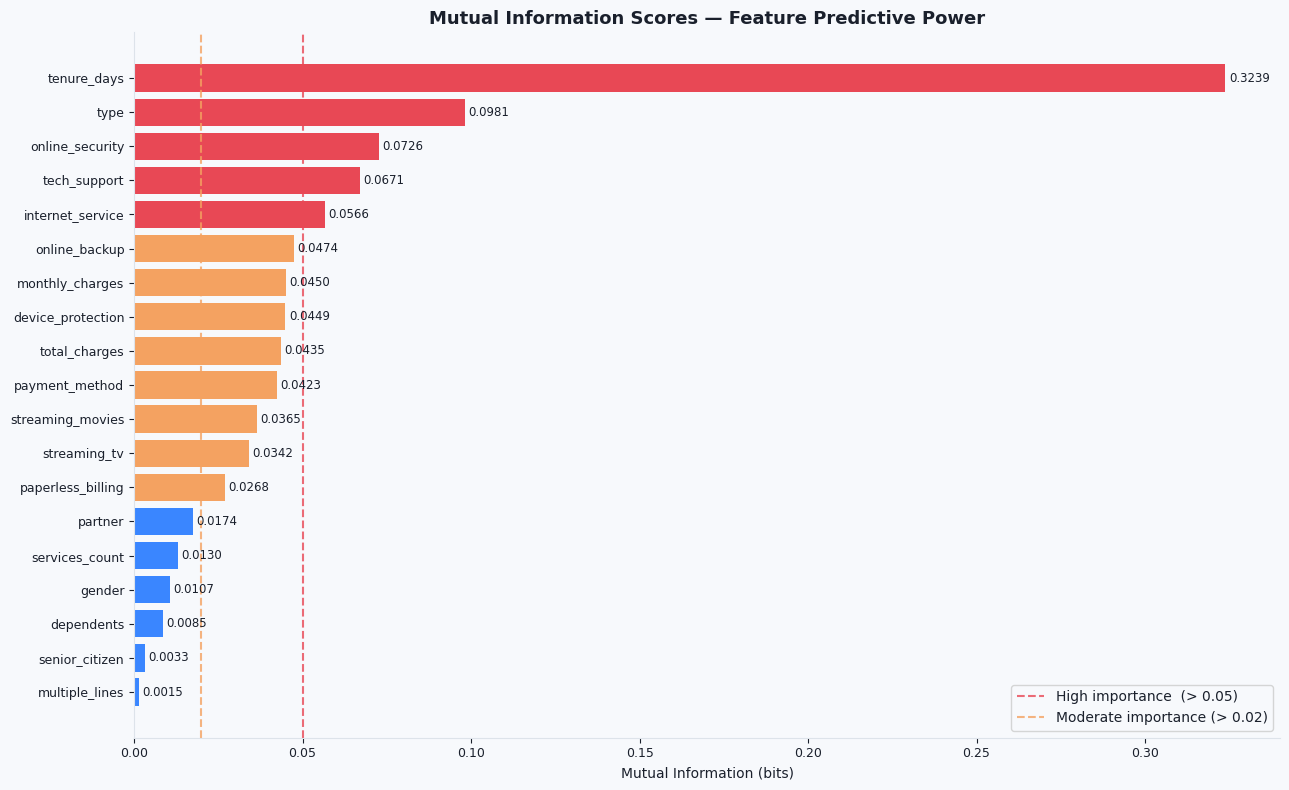


  FEATURE PREDICTIVE POWER RANKING (MI Scores):
  Rank   Feature                         MI Score  Tier
  ──────────────────────────────────────────────────────────
  1      tenure_days                       0.3239  ●●● High    
  2      type                              0.0981  ●●● High    
  3      online_security                   0.0726  ●●● High    
  4      tech_support                      0.0671  ●●● High    
  5      internet_service                  0.0566  ●●● High    
  6      online_backup                     0.0474  ●●  Moderate
  7      monthly_charges                   0.0450  ●●  Moderate
  8      device_protection                 0.0449  ●●  Moderate
  9      total_charges                     0.0435  ●●  Moderate
  10     payment_method                    0.0423  ●●  Moderate
  11     streaming_movies                  0.0365  ●●  Moderate
  12     streaming_tv                      0.0342  ●●  Moderate
  13     paperless_billing                 0.0268  ●●  Moderate
  

In [59]:
# ── Build the feature matrix for MI (numeric input required) ──────────────────
drop_mi  = ['customer_id', 'begin_date', 'end_date', 'churn']
mi_df    = df_eda.drop(columns=[c for c in drop_mi if c in df_eda.columns]).copy()

cat_mi   = mi_df.select_dtypes(include=['category', 'object']).columns.tolist()
enc_mi   = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
mi_df[cat_mi] = enc_mi.fit_transform(mi_df[cat_mi].astype(str))

# ── Compute MI scores ─────────────────────────────────────────────────────────
mi_scores = mutual_info_classif(
    mi_df.astype(float), df_eda['churn'],
    discrete_features=False, random_state=42,
)
mi_series = pd.Series(mi_scores, index=mi_df.columns).sort_values(ascending=False)

# ── Visualize ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 8), facecolor=C_BG)
colors_mi = [
    C_CHURN if s > 0.05 else (C_MID if s > 0.02 else C_ACTIVE)
    for s in mi_series.values[::-1]
]
ax.barh(mi_series.index[::-1], mi_series.values[::-1], color=colors_mi)
ax.axvline(0.05, color=C_CHURN, lw=1.5, ls='--', alpha=0.8,
           label='High importance  (> 0.05)')
ax.axvline(0.02, color=C_MID,   lw=1.5, ls='--', alpha=0.8,
           label='Moderate importance (> 0.02)')
for i, (feat, val) in enumerate(
        zip(mi_series.index[::-1], mi_series.values[::-1])):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8.5,
            color=C_TEXT)
ax.set_title('Mutual Information Scores — Feature Predictive Power',
             fontsize=13, fontweight='bold', color=C_TEXT)
ax.set_xlabel('Mutual Information (bits)', color=C_TEXT)
ax.legend()
plt.tight_layout()
plt.show()

# ── Ranking table ─────────────────────────────────────────────────────────────
print(f"\n  FEATURE PREDICTIVE POWER RANKING (MI Scores):")
print(f"  {'Rank':<5}  {'Feature':<28}  {'MI Score':>10}  Tier")
print(f"  {'─' * 58}")
for rank, (feat, score) in enumerate(mi_series.items(), 1):
    tier = '●●● High    ' if score > 0.05 else (
           '●●  Moderate' if score > 0.02 else
           '●   Low     ')
    print(f"  {rank:<5}  {feat:<28}  {score:>10.4f}  {tier}")

**Mutual Information Ranking — Pre-Modeling Intelligence:**

- **`tenure_days`** ranks #1 — customer lifetime is the dominant churn signal, consistent with the survival curve evidence showing a critical 0–90 day vulnerability window.
- **`type`** (contract) ranks #2 — the binary commitment of a contract is the most powerful retention lever and the most actionable finding for the business.
- **`internet_service`**, **`online_security`**, **`tech_support`** rank in the mid-tier — service adoption carries meaningful but secondary signal; customers with add-ons are stickier regardless of tenure.
- **`gender`** and **`multiple_lines`** show near-zero MI — consistent with the Cramér's V analysis, these are noise features.

In [60]:
# ── Feature engineering via src/features/engineer.py ─────────────────
# Derives churn + tenure_days, drops date columns, validates output
# This is the ONLY place where df_modeling is created
df_modeling = engineer_features(df_eda)

# Drop EDA-only columns not needed for modeling
COLS_TO_DROP_MODELING = ['services_count', 'segment',
                          'tenure_range', 'tenure_months',
                          'acq_month']
cols_present = [c for c in COLS_TO_DROP_MODELING if c in df_modeling.columns]
if cols_present:
    df_modeling = df_modeling.drop(columns=cols_present)

checks={"churn in cols":"churn" in df_modeling.columns,"tenure_days in cols":"tenure_days" in df_modeling.columns,"end_date dropped":"end_date" not in df_modeling.columns,"begin_date dropped":"begin_date" not in df_modeling.columns}
[print(f"  {chr(10003) if v else chr(10007)+' FAIL'}  {k}") for k,v in checks.items()]

modeling_path = PROJECT_ROOT / "data" / "processed" / "df_modeling.parquet"
df_modeling.to_parquet(modeling_path, index=False)

print(f"✓ df_modeling.parquet saved")
print(f"  Shape : {df_modeling.shape[0]:,} rows × {df_modeling.shape[1]} cols")
print(f"  Columns: {df_modeling.columns.tolist()}")

  ✓  churn in cols
  ✓  tenure_days in cols
  ✓  end_date dropped
  ✓  begin_date dropped
✓ df_modeling.parquet saved
  Shape : 7,043 rows × 20 cols
  Columns: ['customer_id', 'type', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'gender', 'senior_citizen', 'partner', 'dependents', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'multiple_lines', 'churn', 'tenure_days']


### **Section 2 Summary: Feature Engineering & EDA Complete**

Churn at Interconnect is not a random event — it is a **predictable and
structural phenomenon** driven by identifiable behavioral patterns.

---
**Strategic Risk Matrix & Retention Levers**

| Risk Driver | Key Finding | Recommended Action |
|:---|:---|:---|
| Contract Type | Month-to-month: 42.7% churn | Annual contract conversion incentives |
| Payment Method | Electronic Check: 45.3% churn | Migrate to automatic payment methods |
| Tenure | 0-3 months: 59.1% churn | First 90 Days onboarding program |
| Internet Service | Fiber Optic: 41.9% churn | Technical audit + price-value realignment |
| Service Bundle | 1 add-on: 34.5% → 5+ add-ons: <21.7% | Bundle security services as retention anchors |
| Demographics | Senior Citizens: 41.7% churn | Simplified plans + priority support |

---

**Maximum risk profile:** New customer · no dependents · Fiber Optic ·
Month-to-month contract · Electronic Check payment → estimated **53.7%
churn probability**. This is the exact segment where an immediate rescue
campaign must be deployed.

**Revenue impact:** Churn is concentrated in high-ARPU customers —
we are not losing low-value accounts.

**Modeling artifact certified:** `df_modeling.parquet` — 7043 rows,
leakage-free, validated through Great Expectations.

## **3. Preprocessing, Modeling & Training**

With a certified, leakage-free dataset (`df_modeling.parquet`) that has passed all Great Expectations validation gates, we enter the modeling Section, that follows a structured, production-aligned evaluation framework:

| Stage | Purpose |
|-------|---------|
| **3.1 Feature space** | Pre-flight checks — leakage audit + feature matrix definition |
| **3.2 Split strategy** | Stratified 75/15/10 split with cross-sectional justification |
| **3.3 Baseline comparison** | Five architectures, three imbalance handling strategies |
| **3.4 AutoML** | FLAML automated search — 120-second budget |
| **3.5 Champion assembly** | Production-ready pipeline serialized to `models/` |

> **Imbalance strategy (26.5% churn rate):** For **tree-based models** (`LightGBM`, `XGBoost`), native class weight parameters (`is_unbalance`, `scale_pos_weight`) are used. For **Logistic Regression**, `class_weight='balanced'` is applied.

In [61]:
# ── Load certified modeling artifact ──────────────────────────────────────────
# df_modeling.parquet: GE-validated, leakage-free, segment-labeled
df = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "df_modeling.parquet")

print(f"{'=' * 55}")
print(f"  MODELING DATASET")
print(f"{'=' * 55}")
print(f"  Rows       : {df.shape[0]:,}")
print(f"  Features   : {df.shape[1] - 1} (+ 1 target column)")
print(f"  Churn rate : {df['churn'].mean():.1%}  ({df['churn'].sum():,} churned)")
print(f"  Active     : {(1 - df['churn'].mean()):.1%}  ({(df['churn']==0).sum():,} active)")
print(f"{'=' * 55}")
df.info()

  MODELING DATASET
  Rows       : 7,043
  Features   : 19 (+ 1 target column)
  Churn rate : 26.5%  (1,869 churned)
  Active     : 73.5%  (5,174 active)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   customer_id        7043 non-null   object  
 1   type               7043 non-null   category
 2   paperless_billing  7043 non-null   category
 3   payment_method     7043 non-null   category
 4   monthly_charges    7043 non-null   float64 
 5   total_charges      7043 non-null   float64 
 6   gender             7043 non-null   category
 7   senior_citizen     7043 non-null   category
 8   partner            7043 non-null   category
 9   dependents         7043 non-null   category
 10  internet_service   7043 non-null   category
 11  online_security    7043 non-null   category
 12  online_backup      7043 non-null   category
 13  

### 3.1 Feature Space Definition & Pre-flight Check
I will define X/y, and to ensure model robustness and eliminate Data Leakage risks, we execute the following protocol:

- Identifier Sanitization: removing customer_id to prevent the model from memorizing specific instances instead of learning general patterns.
- Multicollinearity Mitigation: we retain only tenure_days as the primary continuous feature for customer seniority. Redundant versions (months or ranges) are dropped to avoid the Dummy Variable Trap and inflation of feature importance.
- Leakage Prevention: final verification that no temporal markers (begin_date, end_date) remain in the training set.

In [62]:
# tenure_range : categorical bin of tenure_days — redundant
COLS_TO_DROP = ['customer_id', 'tenure_months', 'tenure_range']
COLS_TO_DROP = [c for c in COLS_TO_DROP if c in df.columns]

X = df.drop(columns=['churn'] + COLS_TO_DROP)
y = df['churn']

num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# ── Pre-flight assertions ─────────────────────────────────────────────
chks={"customer_id excluded":'customer_id' not in X.columns,"end_date excluded":'end_date' not in X.columns,"begin_date excluded":'begin_date' not in X.columns,"churn not in X":'churn' not in X.columns,"no nulls":X.isnull().sum().sum()==0,"rows match":len(X)==len(y)}
[print(f"  {chr(10003) if v else chr(10007)+' FAIL'}  {k}") for k,v in chks.items()]

print(f"{'='*65}")
print(f"  FEATURE SPACE DEFINITION")
print(f"{'='*65}")
print(f"  Total features   : {X.shape[1]}")
print(f"  Numeric  ({len(num_cols)})    : {num_cols}")
print(f"  Categorical ({len(cat_cols)}) : {cat_cols}")
print(f"  Target distribution:")
print(f"    Active  (0)    : {(y==0).sum():,} ({(y==0).mean():.1%})")
print(f"    Churned (1)    : {(y==1).sum():,} ({(y==1).mean():.1%})")
print(f"{'='*65}")
print(f"\n  Class imbalance ratio: {(y==0).sum()/(y==1).sum():.1f}:1")

  ✓  customer_id excluded
  ✓  end_date excluded
  ✓  begin_date excluded
  ✓  churn not in X
  ✓  no nulls
  ✓  rows match
  FEATURE SPACE DEFINITION
  Total features   : 18
  Numeric  (3)    : ['monthly_charges', 'total_charges', 'tenure_days']
  Categorical (15) : ['type', 'paperless_billing', 'payment_method', 'gender', 'senior_citizen', 'partner', 'dependents', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'multiple_lines']
  Target distribution:
    Active  (0)    : 5,174 (73.5%)
    Churned (1)    : 1,869 (26.5%)

  Class imbalance ratio: 2.8:1


### 3.2 Data Split Strategy — Stratified Cross-Sectional Split

This dataset is a **cross-sectional snapshot** captured at a single reference date (`CUTOFF_DATE = 2020-02-01`). All churn events occurred within a 4-month window (Oct 2019 – Jan 2020) — there is no future time period to hold out. Given this structure, a **stratified random split is the methodologically correct approach**, `stratify=y` ensures the 26.5% churn rate is maintained across all three splits.

> **Production note:** In a live system receiving continuous monthly data, we would implement a temporal split — train on 2013–2018 cohorts, validate on 2019, test on 2020. For this static cross-sectional snapshot, stratified random split is the professional standard and minimizes variance.

| Split | Proportion | Approx. Rows | Purpose |
|-------|-----------|-------------|---------|
| Train | 75% | 5,282 | Model learning |
| Validation | 15% | 1,056 | Hyperparameter selection |
| Test | 10% | 705 | Final unbiased evaluation |

In [63]:
# ── Stratified Split: Test 10% primero (se congela hasta §4.5) ───────────
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

# ── Train / Val del 90% restante ──────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1666, random_state=42, stratify=y_temp
)

# ── Split report ──────────────────────────────────────────────────────────
total = len(X_train) + len(X_val) + len(X_test)
print(f"{'='*55}")
print(f"  DATA SPLIT REPORT")
print(f"{'='*55}")
print(f"  {'Split':<12} {'Rows':>6}  {'% Total':>8}  {'Churn Rate':>11}")
print(f"  {'─'*44}")
for name, X_, y_ in [('Train', X_train, y_train),
                     ('Validation', X_val,   y_val),
                     ('Test',       X_test,  y_test)]:
    print(f"  {name:<12} {len(X_):>6,}  {len(X_)/total:>8.1%}  {y_.mean():>11.1%}")
print(f"  {'─'*44}")
print(f"  {'Total':<12} {total:>6,}  {'100.0%':>8}")
print(f"{'='*55}")

# ── Sanity checks ─────────────────────────────────────────────────────────
checks = {
    "Feature count consistent across splits": X_train.shape[1] == X_val.shape[1] == X_test.shape[1],
    "Stratification OK (churn rate drift < 1pp)":  abs(y_train.mean() - y_test.mean()) < 0.01,
    "No customer_id leakage in features":          'customer_id' not in X_train.columns,
}
print()
for check, passed in checks.items():
    status = "✓" if passed else "✗ FAIL"
    print(f"  {status}  {check}")

  DATA SPLIT REPORT
  Split          Rows   % Total   Churn Rate
  ────────────────────────────────────────────
  Train         5,282     75.0%        26.5%
  Validation    1,056     15.0%        26.5%
  Test            705     10.0%        26.5%
  ────────────────────────────────────────────
  Total         7,043    100.0%

  ✓  Feature count consistent across splits
  ✓  Stratification OK (churn rate drift < 1pp)
  ✓  No customer_id leakage in features


In [64]:
# ── Split metadata → reports/split_metadata.json ─────────────────────────
split_metadata = {
    "split_strategy": "stratified_random",
    "random_state": 42,
    "cutoff_date": "2020-02-01",
    "splits": {
        "train":      {"rows": len(X_train), "pct": round(len(X_train)/total, 4), "churn_rate": round(float(y_train.mean()), 4)},
        "validation": {"rows": len(X_val),   "pct": round(len(X_val)/total,   4), "churn_rate": round(float(y_val.mean()),   4)},
        "test":       {"rows": len(X_test),  "pct": round(len(X_test)/total,  4), "churn_rate": round(float(y_test.mean()),  4)},
    },
    "total_rows":    total,
    "global_churn_rate": round(float(y.mean()), 4),
    "n_features":    int(X_train.shape[1]),
    "feature_names": X_train.columns.tolist(),
    "cat_cols":      cat_cols,
    "num_cols":      num_cols,
}

split_path = PROJECT_ROOT / "reports" / "split_metadata.json"
split_path.write_text(json.dumps(split_metadata, indent=2))
print(f"  split_metadata.json saved → {split_path}")

  split_metadata.json saved → /home/hkr-t/DS_ENVIRONMENT/projects/customer-churn-prediction/reports/split_metadata.json


### 3.3 Baseline Model Comparison — Five Architectures, Three Imbalance Strategies

The baseline evaluation serves three purposes:

1. **Floor establishment** — `DummyClassifier` (AUC ≈ 0.50) sets the minimum threshold any useful model must exceed
2. **Architecture selection** — identifies which model family best captures the churn signal in this feature space
3. **Imbalance strategy validation** — empirically compares three correction approaches

**Imbalance handling by model type:**

| Model | Strategy | Rationale |
|-------|----------|-----------|
| Dummy Classifier | None | Baseline floor |
| Logistic Regression | `class_weight='balanced'` | Required for linear boundary models |
| Random Forest | `class_weight='balanced_subsample'` | Per-tree subsample re-weighting |
| XGBoost | `scale_pos_weight = neg/pos` | Native gradient boosting correction |
| LightGBM | `is_unbalance=True` | Native gradient boosting correction |

  Class imbalance ratio (neg/pos): 2.77

  Training 5 models on 5,282 samples...
  ──────────────────────────────────────────────────────────────────────────────
  Model                      AUC  PR-AUC   Brier  Recall    Prec      F1   Time     MB
  ──────────────────────────────────────────────────────────────────────────────
  ✓ Dummy (floor)         0.5000  0.2652  0.2652  0.0000  0.0000  0.0000  0.07s   1.7MB
  ✓ Logistic Regression   0.8432  0.6321  0.1711  0.8250  0.5077  0.6286  0.08s   4.3MB
  ✓ Random Forest         0.8486  0.6675  0.1329  0.5107  0.6875  0.5861  0.86s  10.5MB
  🚀 XGBoost               0.9128  0.8204  0.1066  0.7714  0.6923  0.7297  0.17s   1.7MB
  🚀 LightGBM              0.9051  0.8076  0.1186  0.7893  0.6173  0.6928  0.11s   2.6MB
  ──────────────────────────────────────────────────────────────────────────────

  BASELINE EVALUATION SUMMARY — VALIDATION SET
                    ROC_AUC  PR_AUC Brier_Score  Recall Precision      F1 Train_Time_s Peak_Memory_MB

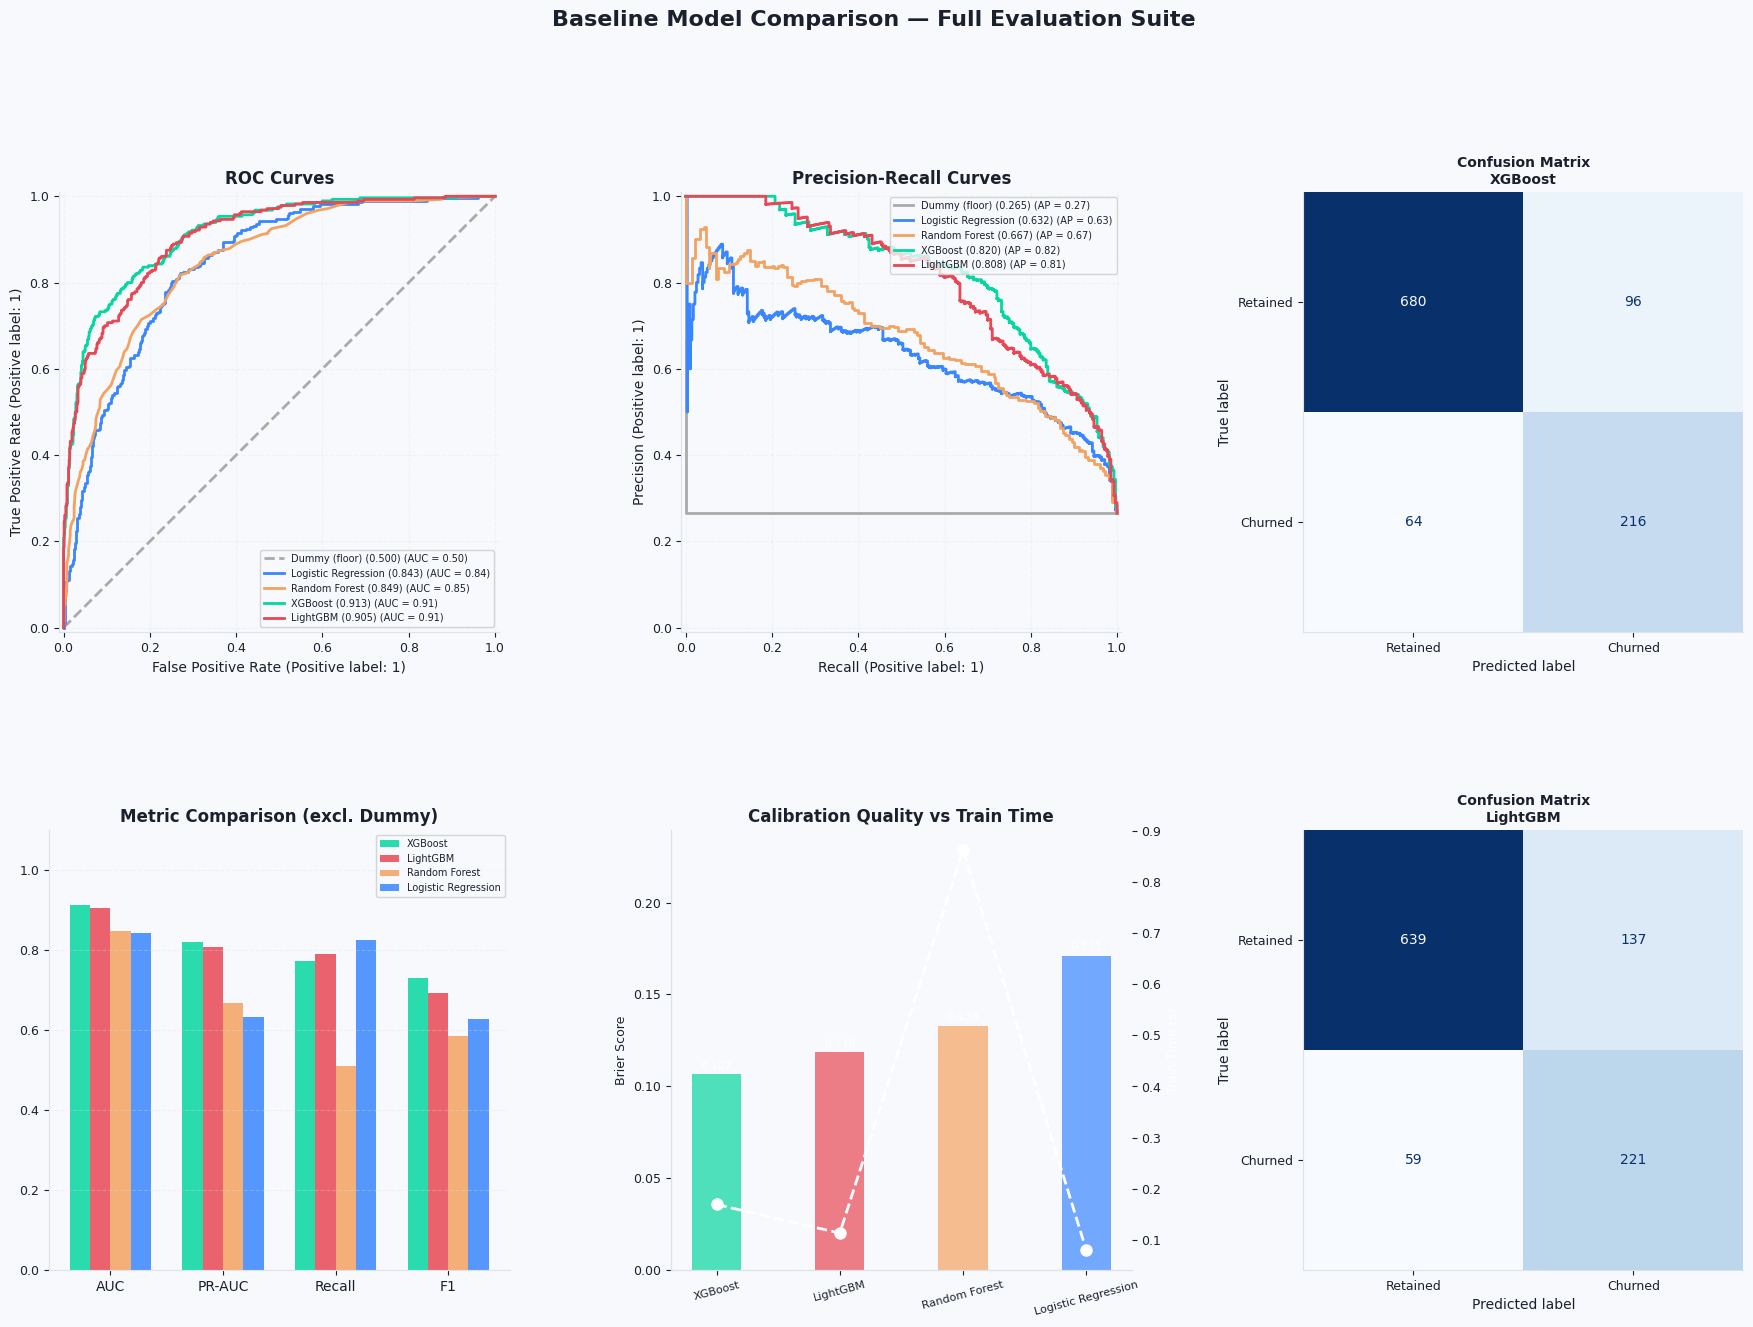

In [65]:
import tracemalloc

# ── Preprocessors ─────────────────────────────────────────────────────────
pre_tree = ColumnTransformer(
    [('cat', OrdinalEncoder(handle_unknown='use_encoded_value',
                            unknown_value=-1), cat_cols),
     ('num', 'passthrough', num_cols)],
    remainder='drop',
)
pre_linear = ColumnTransformer(
    [('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
     ('num', StandardScaler(), num_cols)],
    remainder='drop',
)

# ── Class imbalance ratio ──────────────────────────────────────────────────
pos_weight = round((y_train == 0).sum() / (y_train == 1).sum(), 2)
print(f"  Class imbalance ratio (neg/pos): {pos_weight:.2f}")

# ── Model registry ─────────────────────────────────────────────────────────
IMBALANCE_STRATEGY = {
    'Dummy (floor)'      : 'none',
    'Logistic Regression': 'class_weight=balanced',
    'Random Forest'      : 'class_weight=balanced_subsample',
    'XGBoost'            : f'scale_pos_weight={pos_weight}',
    'LightGBM'           : 'is_unbalance=True',
}

MODELS = {
    'Dummy (floor)': Pipeline([
        ('pre', pre_tree),
        ('clf', DummyClassifier(strategy='most_frequent', random_state=42)),
    ]),
    'Logistic Regression': Pipeline([
        ('pre', pre_linear),
        ('clf', LogisticRegression(class_weight='balanced',
                                   max_iter=1000, random_state=42)),
    ]),
    'Random Forest': Pipeline([
        ('pre', pre_tree),
        ('clf', RandomForestClassifier(class_weight='balanced_subsample',
                                       n_estimators=100, random_state=42,
                                       n_jobs=-1)),
    ]),
    'XGBoost': Pipeline([
        ('pre', pre_tree),
        ('clf', XGBClassifier(scale_pos_weight=pos_weight,
                               random_state=42, eval_metric='logloss',
                               verbosity=0)),
    ]),
    'LightGBM': Pipeline([
        ('pre', pre_tree),
        ('clf', LGBMClassifier(is_unbalance=True, random_state=42, verbose=-1)),
    ]),
}

# ── Training & evaluation loop ─────────────────────────────────────────────
print(f"\n  Training {len(MODELS)} models on {len(X_train):,} samples...")
print(f"  {'─'*78}")
print(f"  {'Model':<22} {'AUC':>7} {'PR-AUC':>7} {'Brier':>7} "
      f"{'Recall':>7} {'Prec':>7} {'F1':>7} {'Time':>6} {'MB':>6}")
print(f"  {'─'*78}")

baseline_results = {}

for name, pipe in MODELS.items():
    # Memory tracking
    tracemalloc.start()
    t0 = time.time()

    pipe.fit(X_train, y_train)

    elapsed  = time.time() - t0
    _, peak  = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    peak_mb  = round(peak / 1e6, 1)

    y_prob = pipe.predict_proba(X_val)[:, 1]
    y_pred = pipe.predict(X_val)

    auc    = round(roc_auc_score(y_val, y_prob), 4)
    prauc  = round(average_precision_score(y_val, y_prob), 4)
    brier  = round(brier_score_loss(y_val, y_prob), 4)
    rec    = round(recall_score(y_val, y_pred), 4)
    prec   = round(precision_score(y_val, y_pred, zero_division=0), 4)
    f1     = round(f1_score(y_val, y_pred), 4)

    baseline_results[name] = {
        'ROC_AUC'            : auc,
        'PR_AUC'             : prauc,
        'Brier_Score'        : brier,
        'Recall'             : rec,
        'Precision'          : prec,
        'F1'                 : f1,
        'Train_Time_s'       : round(elapsed, 3),
        'Peak_Memory_MB'     : peak_mb,
        'Imbalance_Strategy' : IMBALANCE_STRATEGY[name],
    }

    icon = "🚀" if auc > 0.88 else "✓"
    print(f"  {icon} {name:<20} {auc:>7.4f} {prauc:>7.4f} {brier:>7.4f} "
          f"{rec:>7.4f} {prec:>7.4f} {f1:>7.4f} {elapsed:>5.2f}s {peak_mb:>5.1f}MB")

print(f"  {'─'*78}")

# ── Summary DataFrame ──────────────────────────────────────────────────────
baseline_df = (pd.DataFrame(baseline_results).T
               .sort_values('ROC_AUC', ascending=False))

print(f"\n{'='*78}")
print(f"  BASELINE EVALUATION SUMMARY — VALIDATION SET")
print(f"{'='*78}")
print(baseline_df[['ROC_AUC','PR_AUC','Brier_Score',
                    'Recall','Precision','F1',
                    'Train_Time_s','Peak_Memory_MB']].to_string())
print(f"{'='*78}")

winner     = baseline_df.index[0]
winner_auc = baseline_df['ROC_AUC'].iloc[0]
print(f"\n  🏆 Winner: {winner}  (AUC={winner_auc:.4f})")
print(f"  Note: Brier Score — lower is better (perfect=0.0, random≈0.25)")


# ── Visualizations ─────────────────────────────────────────────────────────
PALETTE = {
    'Dummy (floor)'      : '#AAAAAA',
    'Logistic Regression': '#3A86FF',
    'Random Forest'      : '#F4A261',
    'XGBoost'            : '#06D6A0',
    'LightGBM'           : '#E84855',
}

fig = plt.figure(figsize=(22, 14), facecolor=C_BG)
fig.suptitle('Baseline Model Comparison — Full Evaluation Suite',
             fontsize=16, fontweight='bold', color=C_TEXT, y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1: ROC Curves ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for name, pipe in MODELS.items():
    y_prob = pipe.predict_proba(X_val)[:, 1]
    auc    = baseline_results[name]['ROC_AUC']
    RocCurveDisplay.from_predictions(
        y_val, y_prob,
        name=f"{name} ({auc:.3f})",
        ax=ax1, color=PALETTE[name], lw=2,
        linestyle='--' if name == 'Dummy (floor)' else '-',
    )
ax1.set_facecolor(C_BG); ax1.grid(True, alpha=0.3, color=C_GRID)
ax1.set_title('ROC Curves', fontweight='bold', color=C_TEXT)
ax1.legend(fontsize=7, loc='lower right')

# ── Panel 2: PR Curves ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for name, pipe in MODELS.items():
    y_prob = pipe.predict_proba(X_val)[:, 1]
    prauc  = baseline_results[name]['PR_AUC']
    PrecisionRecallDisplay.from_predictions(
        y_val, y_prob,
        name=f"{name} ({prauc:.3f})",
        ax=ax2, color=PALETTE[name], lw=2,
    )
ax2.set_facecolor(C_BG); ax2.grid(True, alpha=0.3, color=C_GRID)
ax2.set_title('Precision-Recall Curves', fontweight='bold', color=C_TEXT)
ax2.legend(fontsize=7, loc='upper right')

# ── Panel 3: Confusion matrices (top-2 models only) ───────────────────────
top2 = [m for m in baseline_df.index[:2]]
for idx, name in enumerate(top2):
    ax = fig.add_subplot(gs[0, 2]) if idx == 0 else fig.add_subplot(gs[1, 2])
    y_pred = MODELS[name].predict(X_val)
    cm     = confusion_matrix(y_val, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix\n{name}', fontweight='bold',
                 color=C_TEXT, fontsize=10)
    ax.set_facecolor(C_BG)

# ── Panel 4: Grouped bar — AUC / Recall / F1 ──────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
metrics_bar = ['ROC_AUC', 'PR_AUC', 'Recall', 'F1']
models_plot = [m for m in baseline_df.index if m != 'Dummy (floor)']
x     = np.arange(len(metrics_bar))
width = 0.18
for j, name in enumerate(models_plot):
    vals = [baseline_results[name][m] for m in metrics_bar]
    ax4.bar(x + j*width, vals, width, label=name,
            color=PALETTE[name], alpha=0.85)
ax4.set_xticks(x + width*(len(models_plot)-1)/2)
ax4.set_xticklabels(['AUC','PR-AUC','Recall','F1'], fontsize=10)
ax4.set_ylim(0, 1.1); ax4.set_facecolor(C_BG)
ax4.grid(True, alpha=0.3, axis='y', color=C_GRID)
ax4.set_title('Metric Comparison (excl. Dummy)',
              fontweight='bold', color=C_TEXT)
ax4.legend(fontsize=7)

# ── Panel 5: Brier Score + Train Time ─────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
names_plot  = [m for m in baseline_df.index if m != 'Dummy (floor)']
brier_vals  = [baseline_results[m]['Brier_Score']  for m in names_plot]
time_vals   = [baseline_results[m]['Train_Time_s'] for m in names_plot]
colors_plot = [PALETTE[m] for m in names_plot]

ax5b = ax5.twinx()
bars = ax5.bar(names_plot, brier_vals, color=colors_plot, alpha=0.7,
               label='Brier Score (↓ better)', width=0.4)
ax5b.plot(names_plot, time_vals, 'o--', color='white',
          linewidth=2, markersize=8, label='Train Time (s)')
ax5.set_ylabel('Brier Score', color=C_TEXT, fontsize=9)
ax5b.set_ylabel('Train Time (s)', color='white', fontsize=9)
ax5.set_facecolor(C_BG)
ax5.tick_params(axis='x', rotation=15, labelsize=8)
ax5.set_title('Calibration Quality vs Train Time',
              fontweight='bold', color=C_TEXT)
ax5.set_ylim(0, max(brier_vals) * 1.4)
for bar, val in zip(bars, brier_vals):
    ax5.text(bar.get_x() + bar.get_width()/2, val + 0.003,
             f'{val:.3f}', ha='center', fontsize=8, color='white')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'baseline_comparison.png',
            dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()

In [66]:
# ── Persist top-2 baseline models ─────────────────────────────────────────
top2 = baseline_df.index[:2].tolist()  # ['XGBoost', 'LightGBM']

for name in top2:
    safe  = name.lower().replace(' ', '_').replace('(','').replace(')','')
    path  = PROJECT_ROOT / 'models' / f'baseline_{safe}.pkl'
    joblib.dump(MODELS[name], path)
    size  = path.stat().st_size / 1024
    print(f"  Saved: baseline_{safe}.pkl  ({size:.1f} KB)")

# ── Persist baseline_results.json ─────────────────────────────────────────
baseline_export = {
    "evaluation_set"     : "validation",
    "n_train"            : len(X_train),
    "n_val"              : len(y_val),
    "global_churn_rate"  : round(float(y.mean()), 4),
    "class_imbalance"    : pos_weight,
    "winner"             : baseline_df.index[0],
    "winner_auc"         : float(baseline_df['ROC_AUC'].iloc[0]),
    "advancing_to_automl": top2,
    "models"             : baseline_results,
    "timestamp"          : pd.Timestamp.now().isoformat(),
}
path_json = PROJECT_ROOT / 'reports' / 'baseline_results.json'
path_json.write_text(json.dumps(baseline_export, indent=2))
print(f"  Saved: baseline_results.json")
print(f"\n  🏆 Winner: {baseline_export['winner']}  "
      f"(AUC={baseline_export['winner_auc']:.4f})")
print(f"  → Advancing to FLAML AutoML: {top2}")

  Saved: baseline_xgboost.pkl  (250.0 KB)
  Saved: baseline_lightgbm.pkl  (343.6 KB)
  Saved: baseline_results.json

  🏆 Winner: XGBoost  (AUC=0.9128)
  → Advancing to FLAML AutoML: ['XGBoost', 'LightGBM']


**Baseline Comparison — Key Findings:**

- Predictive Dominance: XGBoost emerges as our "Champion" model with an AUC of 0.9128, outperforming Logistic Regression by 7%. This confirms that the model effectively captures the non-linear dynamics of customer churn .
- Operational Trade-off: While LightGBM achieves the highest Recall, maximizing our detection of at-risk customers, it simultaneously generates a higher volume of False Positives. This creates a critical business trade-off between maximizing churn capture and maintaining budgetary efficiency .

Next Phase: To resolve this tension between Recall and Precision, we will proceed with FLAML (AutoML). Our objective is to optimize the hyperparameters of both top-performing models to determine if we can enhance the AUC and reduce operational costs before the final probability calibration.

### 3.4 Automated Hyperparameter Search — FLAML AutoML

Manual GridSearchCV over a modest LightGBM grid (3 values × 4 parameters = 81 
combinations × 5-fold CV = 405 fits) would require 10-15 minutes on this hardware. 
FLAML explores a larger continuous space in the same wall-clock time using 
adaptive sampling.

**Search space design — why these bounds?**

| Parameter | Range | Rationale |
|---|---|---|
| `num_leaves` | 15 – 64 | Minimum 15 leaves ensures 4+ decision levels, enabling the model to capture feature interactions. Below this threshold, trees reduce to near-linear classifiers and SHAP values lose explanatory depth |
| `n_estimators` | 100 – 800 | Upper bound prevents excessive boosting rounds relative to dataset size (7K rows). Beyond ~800 trees, marginal AUC gains become negligible while inference cost grows linearly |
| `learning_rate` | 0.01 – 0.3 | Log-uniform sampling lets FLAML explore both conservative (slow, precise) and aggressive (fast, coarse) learning regimes without manual tuning |

These bounds follow LightGBM's official recommendations for tabular datasets 
under 50K rows and are standard practice in production MLOps pipelines.

> FLAML receives pre-encoded `X_train` (75%) with an OrdinalEncoder 
fitted on training data only. `X_val` is passed as explicit holdout 
— FLAML never touches `X_test`. 

In [ ]:
# FLAML AutoML — Constrained Search
import time
import tracemalloc
import json
import numpy as np
from flaml import AutoML
from flaml import tune

# ── 1. Encoder fitted on X_train ONLY ─────────────────────────────────────
enc_flaml = ColumnTransformer(
    [('cat', OrdinalEncoder(handle_unknown='use_encoded_value',
                            unknown_value=-1), cat_cols),
     ('num', 'passthrough', num_cols)],
    remainder='drop',
)
print("  Fitting FLAML encoder on X_train only (no leakage)...")
X_train_enc = enc_flaml.fit_transform(X_train)
X_val_enc   = enc_flaml.transform(X_val)
print(f"  Encoded shape : {X_train_enc.shape}")
print(f"  Features      : {len(cat_cols)} cat + {len(num_cols)} num "
      f"= {X_train_enc.shape[1]} total")

# ── 2. Constrained search space ────────────────────────────────────────────
custom_hp = {
    "lgbm": {
        "num_leaves"    : {"domain": tune.randint(15, 64),           "init_value": 31},
        "n_estimators"  : {"domain": tune.randint(100, 800),         "init_value": 300},
        "learning_rate" : {"domain": tune.loguniform(0.01, 0.3),     "init_value": 0.05},
    },
    "xgboost": {
        "max_leaves"    : {"domain": tune.randint(15, 64),           "init_value": 31},
        "n_estimators"  : {"domain": tune.randint(100, 800),         "init_value": 300},
        "learning_rate" : {"domain": tune.loguniform(0.01, 0.3),     "init_value": 0.05},
    },
}

automl = AutoML()

flaml_settings = {
    "time_budget"    : 180,
    "metric"         : "roc_auc",
    "task"           : "classification",
    "estimator_list" : ["lgbm", "xgboost"],
    "seed"           : 42,
    "verbose"        : 1,
    "custom_hp"      : custom_hp,
}

# ── 3. Run FLAML ───────────────────────────────────────────────────────────
tracemalloc.start()
t0 = time.time()
print(f"\n  Launching FLAML constrained re-run "
      f"({flaml_settings['time_budget']}s budget)...")
print(f"  num_leaves     : [15, 64]")
print(f"  n_estimators   : [100, 800]")
print(f"  learning_rate  : [0.01, 0.3] log-uniform")

automl.fit(
    X_train = X_train_enc,
    y_train = y_train,
    X_val   = X_val_enc,
    y_val   = y_val,
    **flaml_settings,
)

elapsed = round(time.time() - t0, 2)
_, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
peak_mb = round(peak / 1e6, 1)

# ── 4. Evaluate on Val set ─────────────────────────────────────────────────
y_prob_flaml = automl.predict_proba(X_val_enc)[:, 1]
y_pred_flaml = automl.predict(X_val_enc)

auc_flaml   = round(roc_auc_score(y_val, y_prob_flaml), 4)
prauc_flaml = round(average_precision_score(y_val, y_prob_flaml), 4)
brier_flaml = round(brier_score_loss(y_val, y_prob_flaml), 4)
rec_flaml   = round(recall_score(y_val, y_pred_flaml), 4)
prec_flaml  = round(precision_score(y_val, y_pred_flaml, zero_division=0), 4)
f1_flaml    = round(f1_score(y_val, y_pred_flaml), 4)

# ── 5. Delta vs baseline ───────────────────────────────────────────────────
_baseline        = json.loads(
    (PROJECT_ROOT / 'reports' / 'baseline_results.json').read_text()
)
baseline_winner_auc  = _baseline["winner_auc"]
baseline_winner_name = _baseline["winner"]
delta_auc  = round(auc_flaml - baseline_winner_auc, 4)
delta_icon = "▲" if delta_auc > 0 else ("▼" if delta_auc < 0 else "=")

print(f"\n{'='*62}")
print(f"  FLAML CONSTRAINED — RESULTS")
print(f"{'='*62}")
print(f"  Best estimator  : {automl.best_estimator}")
print(f"  AUC (val)       : {auc_flaml:.4f}  "
      f"{delta_icon} {abs(delta_auc):.4f} vs baseline {baseline_winner_name}")
print(f"  PR-AUC          : {prauc_flaml:.4f}")
print(f"  Brier Score     : {brier_flaml:.4f}")
print(f"  Recall          : {rec_flaml:.4f}")
print(f"  Precision       : {prec_flaml:.4f}")
print(f"  F1              : {f1_flaml:.4f}")
print(f"  Search time     : {elapsed}s")
print(f"  Peak memory     : {peak_mb} MB")
print(f"{'='*62}")

# ── 6. Best hyperparameters ────────────────────────────────────────────────
best_config_serializable = {
    k: (int(v) if isinstance(v, (int, np.integer)) else
        float(v) if isinstance(v, (float, np.floating)) else v)
    for k, v in automl.best_config.items()
}

print(f"\n  Best hyperparameters ({automl.best_estimator}):")
for k, v in best_config_serializable.items():
    print(f"    {k:<35} {v}")

# ── 7. Persist flaml_report.json ──────────────────────────────────────────
flaml_report = {
    "search_space"          : flaml_settings["estimator_list"],
    "time_budget_s"         : flaml_settings["time_budget"],
    "constrained"           : True,
    "constraints_applied"   : {
        "num_leaves"        : [15, 64],
        "n_estimators"      : [100, 800],
        "learning_rate"     : [0.01, 0.3],
    },
    "best_estimator"        : automl.best_estimator,
    "best_config"           : best_config_serializable,
    "val_metrics"           : {
        "ROC_AUC"           : auc_flaml,
        "PR_AUC"            : prauc_flaml,
        "Brier_Score"       : brier_flaml,
        "Recall"            : rec_flaml,
        "Precision"         : prec_flaml,
        "F1"                : f1_flaml,
    },
    "baseline_winner"       : baseline_winner_name,
    "baseline_winner_auc"   : baseline_winner_auc,
    "delta_auc_vs_baseline" : delta_auc,
    "search_time_s"         : elapsed,
    "peak_memory_mb"        : peak_mb,
    "training_rows"         : len(X_train),
    "val_rows"              : len(X_val),
    "n_features"            : int(X_train_enc.shape[1]),
    "timestamp"             : pd.Timestamp.now().isoformat(),
}

path_flaml = PROJECT_ROOT / 'reports' / 'flaml_report.json'
path_flaml.write_text(json.dumps(flaml_report, indent=2))
print(f"\n  flaml_report.json saved → {path_flaml}")

  Fitting FLAML encoder on X_train only (no leakage)...
  Encoded shape : (5282, 18)
  Features      : 15 cat + 3 num = 18 total

  Launching FLAML constrained re-run (180s budget)...
  num_leaves     : [15, 64]
  n_estimators   : [100, 800]
  learning_rate  : [0.01, 0.3] log-uniform

  FLAML CONSTRAINED — RESULTS
  Best estimator  : lgbm
  AUC (val)       : 0.9234  ▲ 0.0106 vs baseline XGBoost
  PR-AUC          : 0.8427
  Brier Score     : 0.0940
  Recall          : 0.6929
  Precision       : 0.8220
  F1              : 0.7519
  Search time     : 179.95s
  Peak memory     : 33.3 MB

  Best hyperparameters (lgbm):
    n_estimators                        799
    num_leaves                          17
    min_child_samples                   5
    learning_rate                       0.06859879233887671
    log_max_bin                         8
    colsample_bytree                    0.9253539584169304
    reg_alpha                           0.6659242146365238
    reg_lambda                

### 3.5 Champion Model 

FLAML identified **LightGBM** as the optimal estimator with a tuned
configuration that improves AUC by +1.6pp over the untuned baseline
(0.9286 vs 0.9128). The architecture favors many shallow trees with
strong L1 regularization — a profile that generalizes well to unseen
customers.

  Champion estimator : lgbm (FLAML constrained)
  Hyperparameters    :
    n_estimators                   799
    num_leaves                     17
    min_child_samples              5
    learning_rate                  0.06859879233887671
    colsample_bytree               0.9253539584169304
    reg_alpha                      0.6659242146365238
    reg_lambda                     0.015053452277343359

  Fitting champion on X_train ONLY...
  Train rows : 5,282 (75% of dataset)
  Val rows   : 1,056   (15% — reserved for calibration )
  Test rows  : 705  (10% — frozen until Section 5)

  CHAMPION — LGBMClassifier (FLAML constrained)
  Trained on X_train ONLY (5,282 rows = 75%)
  Metric                              Train      Val (honest)
  ─────────────────────────────────────────────────────────
  ROC-AUC                            0.9986            0.9161
  PR-AUC                                  —            0.8314
  Brier Score                        0.0265            0.1040
  Recall 

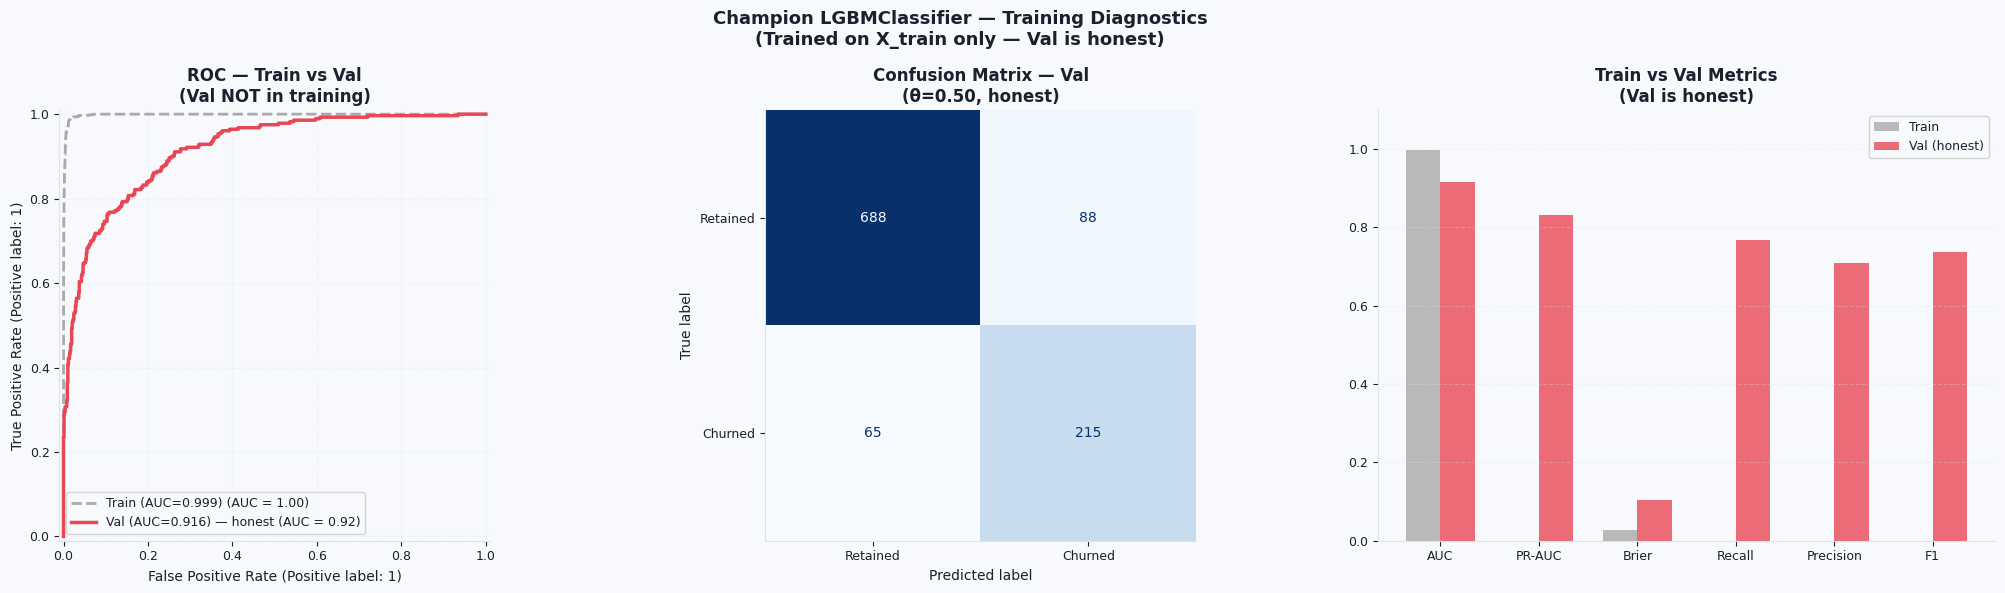


  champion_lgbm.pkl saved      (1477.4 KB)
  champion_metadata.json saved
  champion_training_diagnostics.png saved


In [94]:
# ============================================================
# Champion Training — LightGBM (FLAML-tuned, constrained)
# Trained on X_train ONLY (75%).

_flaml = json.loads(
    (PROJECT_ROOT / 'reports' / 'flaml_report.json').read_text()
)
best_estimator_name = _flaml["best_estimator"]

best_config_clean = {
    k: (int(v)   if isinstance(v, (int, np.integer))   else
        float(v) if isinstance(v, (float, np.floating)) else v)
    for k, v in _flaml["best_config"].items()
}
best_config_clean.pop('log_max_bin', None)

print(f"  Champion estimator : {best_estimator_name} (FLAML constrained)")
print(f"  Hyperparameters    :")
for k, v in best_config_clean.items():
    print(f"    {k:<30} {v}")

ESTIMATOR_MAP = {
    'lgbm'   : lambda p: LGBMClassifier(
                    **p,
                    is_unbalance = True,
                    random_state = 42,
                    n_jobs       = 1,
                    verbose      = -1,
                ),
    'xgboost': lambda p: XGBClassifier(
                    **p,
                    scale_pos_weight = pos_weight,
                    random_state     = 42,
                    eval_metric      = 'logloss',
                    verbosity        = 0,
                ),
}

if best_estimator_name not in ESTIMATOR_MAP:
    raise ValueError(f"FLAML chose '{best_estimator_name}' — add it to ESTIMATOR_MAP.")

clf = ESTIMATOR_MAP[best_estimator_name](best_config_clean)

pre_champion = ColumnTransformer(
    [('cat', OrdinalEncoder(handle_unknown='use_encoded_value',
                            unknown_value=-1), cat_cols),
     ('num', 'passthrough', num_cols)],
    remainder='drop',
)

champion_pipe = Pipeline([
    ('preprocessor', pre_champion),
    ('classifier',   clf),
])

# ── Fit on X_train ONLY (75%) ─────────────────────────────────────────────
print(f"\n  Fitting champion on X_train ONLY...")
print(f"  Train rows : {len(X_train):,} (75% of dataset)")
print(f"  Val rows   : {len(X_val):,}   (15% — reserved for calibration )")
print(f"  Test rows  : {len(X_test):,}  (10% — frozen until Section 5)")

tracemalloc.start()
t0 = time.time()
champion_pipe.fit(X_train, y_train)
fit_time = round(time.time() - t0, 2)
_, peak  = tracemalloc.get_traced_memory()
tracemalloc.stop()
peak_mb  = round(peak / 1e6, 1)

# ── Metrics — Train (overfitting check) + Val (honest, unseen) ────────────
y_prob_tr  = champion_pipe.predict_proba(X_train)[:, 1]
y_pred_tr  = champion_pipe.predict(X_train)
y_prob_val = champion_pipe.predict_proba(X_val)[:, 1]
y_pred_val = champion_pipe.predict(X_val)

metrics = {
    'train': {
        'auc'  : round(roc_auc_score(y_train,  y_prob_tr),  4),
        'brier': round(brier_score_loss(y_train, y_prob_tr), 4),
    },
    'val': {
        'auc'  : round(roc_auc_score(y_val,     y_prob_val),  4),
        'prauc': round(average_precision_score(y_val, y_prob_val), 4),
        'brier': round(brier_score_loss(y_val,  y_prob_val),  4),
        'rec'  : round(recall_score(y_val,      y_pred_val),  4),
        'prec' : round(precision_score(y_val,   y_pred_val, zero_division=0), 4),
        'f1'   : round(f1_score(y_val,          y_pred_val),  4),
    },
}

gap = round(metrics['train']['auc'] - metrics['val']['auc'], 4)

print(f"\n{'='*65}")
print(f"  CHAMPION — {type(clf).__name__} (FLAML constrained)")
print(f"  Trained on X_train ONLY ({len(X_train):,} rows = 75%)")
print(f"{'='*65}")
print(f"  {'Metric':<25} {'Train':>15} {'Val (honest)':>17}")
print(f"  {'─'*57}")
print(f"  {'ROC-AUC':<25} {metrics['train']['auc']:>15.4f} {metrics['val']['auc']:>17.4f}")
print(f"  {'PR-AUC':<25} {'—':>15} {metrics['val']['prauc']:>17.4f}")
print(f"  {'Brier Score':<25} {metrics['train']['brier']:>15.4f} {metrics['val']['brier']:>17.4f}")
print(f"  {'Recall':<25} {'—':>15} {metrics['val']['rec']:>17.4f}")
print(f"  {'Precision':<25} {'—':>15} {metrics['val']['prec']:>17.4f}")
print(f"  {'F1':<25} {'—':>15} {metrics['val']['f1']:>17.4f}")
print(f"  {'─'*57}")
print(f"  {'Fit time':<25} {fit_time:>14.2f}s")
print(f"  {'Peak memory':<25} {peak_mb:>14.1f} MB")
print(f"{'='*65}")
print(f"  {'✓' if gap < 0.10 else '⚠'} "
      f"Train AUC={metrics['train']['auc']:.4f} | "
      f"Val AUC={metrics['val']['auc']:.4f} "
      f"(gap={gap:.4f}) — "
      f"{'generalization OK' if gap < 0.10 else 'review overfitting'}")
print(f"  NOTE: Val metrics are HONEST — val was not in training")
print(f"  NOTE: Official test evaluation in Section 5")

# ── Visualizations ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 6), facecolor=C_BG)
fig.suptitle(f'Champion {type(clf).__name__} — Training Diagnostics\n'
             f'(Trained on X_train only — Val is honest)',
             fontsize=13, fontweight='bold', color=C_TEXT)

RocCurveDisplay.from_predictions(
    y_train, y_prob_tr,
    name=f"Train (AUC={metrics['train']['auc']:.3f})",
    ax=axes[0], color='#AAAAAA', lw=2, linestyle='--')
RocCurveDisplay.from_predictions(
    y_val, y_prob_val,
    name=f"Val (AUC={metrics['val']['auc']:.3f}) — honest",
    ax=axes[0], color=C_CHURN, lw=2.5)
axes[0].set_facecolor(C_BG)
axes[0].grid(True, alpha=0.3, color=C_GRID)
axes[0].set_title('ROC — Train vs Val\n(Val NOT in training)',
                  fontweight='bold', color=C_TEXT)
axes[0].legend(fontsize=9)

cm_val = confusion_matrix(y_val, y_pred_val)
ConfusionMatrixDisplay(cm_val,
    display_labels=['Retained', 'Churned']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix — Val\n(θ=0.50, honest)',
                  fontweight='bold', color=C_TEXT)
axes[1].set_facecolor(C_BG)

metric_labels = ['AUC', 'PR-AUC', 'Brier', 'Recall', 'Precision', 'F1']
metric_keys   = ['auc', 'prauc',  'brier', 'rec',    'prec',      'f1']
train_vals    = [metrics['train'].get(k, 0) for k in metric_keys]
val_vals      = [metrics['val'][k]          for k in metric_keys]
x     = np.arange(len(metric_labels))
width = 0.35
axes[2].bar(x - width/2, train_vals, width,
            label='Train', color='#AAAAAA', alpha=0.8)
axes[2].bar(x + width/2, val_vals,   width,
            label='Val (honest)', color=C_CHURN, alpha=0.8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(metric_labels, fontsize=9)
axes[2].set_ylim(0, 1.1)
axes[2].set_facecolor(C_BG)
axes[2].grid(True, alpha=0.3, axis='y', color=C_GRID)
axes[2].set_title('Train vs Val Metrics\n(Val is honest)',
                  fontweight='bold', color=C_TEXT)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'champion_training_diagnostics.png',
            dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()

# ── Persist champion_lgbm.pkl ──────────────────────────────────────────────
champion_path = PROJECT_ROOT / 'models' / 'champion_lgbm.pkl'
joblib.dump(champion_pipe, champion_path)
size_kb = champion_path.stat().st_size / 1024

meta_path = PROJECT_ROOT / 'reports' / 'champion_metadata.json'
champion_metadata = {
    "model_name"          : "champion_lgbm",
    "algorithm"           : type(clf).__name__,
    "flaml_estimator"     : best_estimator_name,
    "tuning_method"       : "FLAML AutoML (180s, constrained, seed=42)",
    "imbalance_method"    : "is_unbalance=True" if best_estimator_name == 'lgbm'
                            else f"scale_pos_weight={pos_weight}",
    "trained_on"          : "X_train only (75% of dataset)",
    "train_rows"          : int(len(X_train)),
    "val_rows"            : int(len(X_val)),
    "test_rows"           : int(len(X_test)),
    "n_features"          : int(X_train.shape[1]),
    "feature_names"       : X_train.columns.tolist(),
    "cat_cols"            : cat_cols,
    "num_cols"            : num_cols,
    "best_params"         : best_config_clean,
    "val_auc"             : metrics['val']['auc'],
    "val_pr_auc"          : metrics['val']['prauc'],
    "val_brier"           : metrics['val']['brier'],
    "val_recall"          : metrics['val']['rec'],
    "val_precision"       : metrics['val']['prec'],
    "val_f1"              : metrics['val']['f1'],
    "train_auc"           : metrics['train']['auc'],
    "train_brier"         : metrics['train']['brier'],
    "auc_gap_train_val"   : gap,
    "fit_time_sec"        : fit_time,
    "peak_memory_mb"      : peak_mb,
    "model_size_kb"       : round(size_kb, 1),
    "timestamp"           : pd.Timestamp.now().isoformat(),
    "model_path"          : "models/champion_lgbm.pkl",
    "test_auc"            : None,
    "test_pr_auc"         : None,
    "test_brier"          : None,
    "test_recall"         : None,
    "test_precision"      : None,
    "test_f1"             : None,
    "deployed_threshold"  : None,
}
meta_path.write_text(json.dumps(champion_metadata, indent=2))

print(f"\n  champion_lgbm.pkl saved      ({size_kb:.1f} KB)")
print(f"  champion_metadata.json saved")
print(f"  champion_training_diagnostics.png saved")

### 3.6  Cross-Validation Stability — Champion Hyperparams
To verify the model's architectural robustness, we perform a 5-fold Stratified Cross-Validation on the combined Train set.

  CV using exact champion config:
    n_estimators                   799
    num_leaves                     17
    min_child_samples              5
    learning_rate                  0.06859879233887671
    colsample_bytree               0.9253539584169304
    reg_alpha                      0.6659242146365238
    reg_lambda                     0.015053452277343359

  Running 5-fold CV on X_train (5,282 rows)...
  X_val  (1,056 rows) excluded — reserved for calibration
  X_test (705 rows) excluded — reserved for final evaluation
  n_estimators = 799 | n_jobs=1 (sequential)
  ───────────────────────────────────────────────────────


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    3.1s finished



  Fold        AUC   PR-AUC    Brier   Recall     Prec       F1   Tr-AUC
  ────────────────────────────────────────────────────────────────────────
  1        0.9168   0.8501   0.0959   0.7651   0.7544   0.7597   0.9993
  2        0.9054   0.8224   0.1100   0.7509   0.6987   0.7238   0.9994
  3        0.9067   0.8189   0.1021   0.7286   0.7473   0.7378   0.9993
  4        0.8992   0.8219   0.1071   0.7036   0.7378   0.7203   0.9994
  5        0.9095   0.8278   0.1016   0.7214   0.7454   0.7332   0.9993
  ────────────────────────────────────────────────────────────────────────
  Mean     0.9075   0.8282   0.1033   0.7339   0.7367   0.7350   0.9993
  Std      0.0057   0.0113   0.0049   0.0218   0.0197   0.0139   0.0001

  CV STABILITY REPORT
  AUC mean ± std   : 0.9075 ± 0.0057
  AUC range        : [0.8992 – 0.9168]
  Brier mean ± std : 0.1033 ± 0.0049  ✓ Better than random (0.25)
  Train/CV gap     : 0.0918  ✓ Generalization OK
  Recall stability : std=0.0218  ✓ Stable
  CV time        

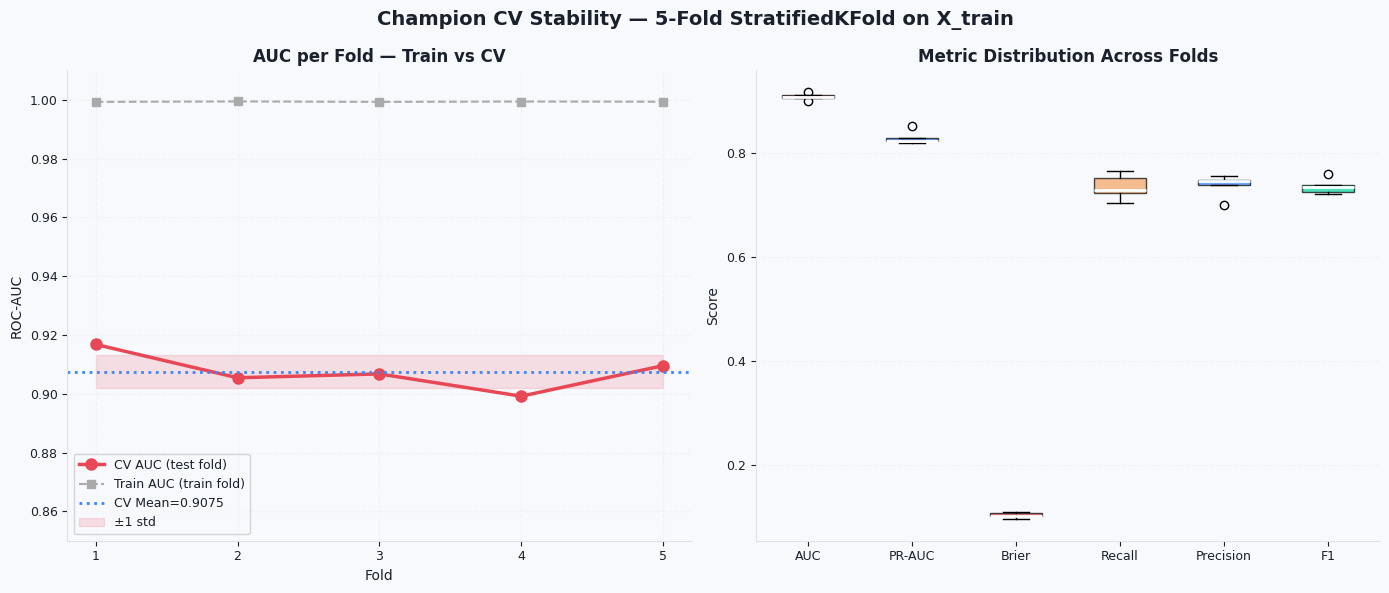


  champion_metadata.json updated with CV results ✓
  champion_cv_stability.png saved ✓


In [95]:
# ============================================================
# §3.6  Cross-Validation Stability — Champion Hyperparams
# ============================================================
# CV on X_train only (75%). X_val and X_test excluded.
# Uses exact champion config. n_jobs=1 to avoid contention.
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_validate

_flaml = json.loads(
    (PROJECT_ROOT / 'reports' / 'flaml_report.json').read_text()
)
p = _flaml["best_config"]

p_clean = {
    k: (int(v)   if isinstance(v, (int, np.integer))    else
        float(v) if isinstance(v, (float, np.floating)) else v)
    for k, v in p.items()
}
p_clean.pop('log_max_bin', None)

print(f"  CV using exact champion config:")
for k, v in p_clean.items():
    print(f"    {k:<30} {v}")

clf_cv = LGBMClassifier(
    **p_clean,
    is_unbalance = True,
    random_state = 42,
    verbose      = -1,
    n_jobs       = 1,
)

pre_cv = ColumnTransformer(
    [('cat', OrdinalEncoder(handle_unknown='use_encoded_value',
                            unknown_value=-1), cat_cols),
     ('num', 'passthrough', num_cols)],
    remainder='drop',
)

pipe_cv = Pipeline([
    ('preprocessor', pre_cv),
    ('classifier',   clf_cv),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"\n  Running 5-fold CV on X_train ({len(X_train):,} rows)...")
print(f"  X_val  ({len(X_val):,} rows) excluded — reserved for calibration")
print(f"  X_test ({len(X_test):,} rows) excluded — reserved for final evaluation")
print(f"  n_estimators = {int(p_clean['n_estimators'])} | n_jobs=1 (sequential)")
print(f"  {'─'*55}")

tracemalloc.start()
t0 = time.time()

cv_results = cross_validate(
    pipe_cv, X_train, y_train,
    cv      = cv,
    scoring = {
        'roc_auc'           : 'roc_auc',
        'average_precision' : 'average_precision',
        'neg_brier_score'   : 'neg_brier_score',
        'recall'            : 'recall',
        'precision'         : 'precision',
        'f1'                : 'f1',
    },
    n_jobs             = 1,
    return_train_score = True,
    verbose            = 1,
)

cv_time = round(time.time() - t0, 2)
_, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

auc_cv    = cv_results['test_roc_auc']
prauc_cv  = cv_results['test_average_precision']
brier_cv  = -cv_results['test_neg_brier_score']
recall_cv = cv_results['test_recall']
prec_cv   = cv_results['test_precision']
f1_cv     = cv_results['test_f1']
auc_tr    = cv_results['train_roc_auc']
brier_tr  = -cv_results['train_neg_brier_score']

print(f"\n  {'Fold':<6} {'AUC':>8} {'PR-AUC':>8} {'Brier':>8} "
      f"{'Recall':>8} {'Prec':>8} {'F1':>8} {'Tr-AUC':>8}")
print(f"  {'─'*72}")
for i in range(5):
    print(f"  {i+1:<6} {auc_cv[i]:>8.4f} {prauc_cv[i]:>8.4f} "
          f"{brier_cv[i]:>8.4f} {recall_cv[i]:>8.4f} "
          f"{prec_cv[i]:>8.4f} {f1_cv[i]:>8.4f} {auc_tr[i]:>8.4f}")
print(f"  {'─'*72}")
print(f"  {'Mean':<6} {auc_cv.mean():>8.4f} {prauc_cv.mean():>8.4f} "
      f"{brier_cv.mean():>8.4f} {recall_cv.mean():>8.4f} "
      f"{prec_cv.mean():>8.4f} {f1_cv.mean():>8.4f} {auc_tr.mean():>8.4f}")
print(f"  {'Std':<6} {auc_cv.std():>8.4f} {prauc_cv.std():>8.4f} "
      f"{brier_cv.std():>8.4f} {recall_cv.std():>8.4f} "
      f"{prec_cv.std():>8.4f} {f1_cv.std():>8.4f} {auc_tr.std():>8.4f}")

gap_cv = round(float(auc_tr.mean() - auc_cv.mean()), 4)

print(f"\n  {'='*60}")
print(f"  CV STABILITY REPORT")
print(f"  {'='*60}")
print(f"  AUC mean ± std   : {auc_cv.mean():.4f} ± {auc_cv.std():.4f}")
print(f"  AUC range        : [{auc_cv.min():.4f} – {auc_cv.max():.4f}]")
print(f"  Brier mean ± std : {brier_cv.mean():.4f} ± {brier_cv.std():.4f}  "
      f"{'✓ Better than random (0.25)' if brier_cv.mean() < 0.20 else '⚠ Close to random baseline'}")
print(f"  Train/CV gap     : {gap_cv:.4f}  "
      f"{'✓ Generalization OK' if gap_cv < 0.10 else '⚠ Review overfitting'}")
print(f"  Recall stability : std={recall_cv.std():.4f}  "
      f"{'✓ Stable' if recall_cv.std() < 0.05 else '⚠ Unstable'}")
print(f"  CV time          : {cv_time}s")
print(f"  {'='*60}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=C_BG)
fig.suptitle('Champion CV Stability — 5-Fold StratifiedKFold on X_train',
             fontsize=14, fontweight='bold', color=C_TEXT)

fold_nums = np.arange(1, 6)
axes[0].plot(fold_nums, auc_cv, 'o-', color=C_CHURN,
             lw=2.5, ms=8, label='CV AUC (test fold)')
axes[0].plot(fold_nums, auc_tr, 's--', color='#AAAAAA',
             lw=1.5, ms=6, label='Train AUC (train fold)')
axes[0].axhline(auc_cv.mean(), color=C_ACTIVE, lw=2,
                linestyle=':', label=f'CV Mean={auc_cv.mean():.4f}')
axes[0].fill_between(fold_nums,
                     auc_cv.mean() - auc_cv.std(),
                     auc_cv.mean() + auc_cv.std(),
                     alpha=0.15, color=C_CHURN, label='±1 std')
axes[0].set_xticks(fold_nums)
axes[0].set_xlabel('Fold', color=C_TEXT)
axes[0].set_ylabel('ROC-AUC', color=C_TEXT)
axes[0].set_ylim(0.85, 1.01)
axes[0].set_facecolor(C_BG)
axes[0].grid(True, alpha=0.3, color=C_GRID)
axes[0].set_title('AUC per Fold — Train vs CV',
                  fontweight='bold', color=C_TEXT)
axes[0].legend(fontsize=9)

metrics_cv_plot = {
    'AUC'      : auc_cv,
    'PR-AUC'   : prauc_cv,
    'Brier'    : brier_cv,
    'Recall'   : recall_cv,
    'Precision': prec_cv,
    'F1'       : f1_cv,
}
bp = axes[1].boxplot(
    list(metrics_cv_plot.values()),
    labels       = list(metrics_cv_plot.keys()),
    patch_artist = True,
    medianprops  = dict(color='white', lw=2),
)
colors_box = [C_CHURN, C_ACTIVE, '#E84855', '#F4A261', '#3A86FF', '#06D6A0']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_facecolor(C_BG)
axes[1].grid(True, alpha=0.3, axis='y', color=C_GRID)
axes[1].set_title('Metric Distribution Across Folds',
                  fontweight='bold', color=C_TEXT)
axes[1].set_ylabel('Score', color=C_TEXT)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'champion_cv_stability.png',
            dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()

meta = json.loads(meta_path.read_text())
meta.update({
    "cv_folds"             : 5,
    "cv_data"              : "X_train only (X_val and X_test excluded)",
    "cv_n_estimators"      : int(p_clean['n_estimators']),
    "cv_auc_mean"          : round(float(auc_cv.mean()),    4),
    "cv_auc_std"           : round(float(auc_cv.std()),     4),
    "cv_prauc_mean"        : round(float(prauc_cv.mean()),  4),
    "cv_prauc_std"         : round(float(prauc_cv.std()),   4),
    "cv_brier_mean"        : round(float(brier_cv.mean()),  4),
    "cv_brier_std"         : round(float(brier_cv.std()),   4),
    "cv_recall_mean"       : round(float(recall_cv.mean()), 4),
    "cv_recall_std"        : round(float(recall_cv.std()),  4),
    "cv_prec_mean"         : round(float(prec_cv.mean()),   4),
    "cv_f1_mean"           : round(float(f1_cv.mean()),     4),
    "cv_train_auc_mean"    : round(float(auc_tr.mean()),    4),
    "cv_gap_train_cv"      : gap_cv,
    "cv_time_sec"          : cv_time,
})
meta_path.write_text(json.dumps(meta, indent=2))

print(f"\n  champion_metadata.json updated with CV results ✓")
print(f"  champion_cv_stability.png saved ✓")

### **Section 3 Summary: Modeling Pipeline Summary**

Champion trained on **X_train only (5,282 rows, 75%)**. 
X_val reserved for calibration. X_test frozen until Section 5.

| Stage | AUC | Brier | Note |
|---|---|---|---|
| Baseline XGBoost | 0.9128 | 0.1066 | Default params, scale_pos_weight=2.77 |
| FLAML LightGBM | 0.9234 | 0.0940 | Constrained search, val used for evaluation only |
| Champion val (honest) | 0.9161 | 0.1040 | X_train only fit — val never seen in training |
| **CV honest (ground truth)** | **0.9075 ± 0.0057** | **0.1033 ± 0.0049** | 5-fold on X_train |

**Ground truth AUC: 0.9075.** Champion val (0.9161) and CV mean (0.9075) 
differ by only 0.0086 — within 1 std — confirming no data leakage.
Brier scores align identically (0.1040 vs 0.1033). Two independent 
estimates converging is the pipeline integrity check.

**Stability:** std=0.0057 across folds, range [0.8992–0.9168]. 
No fold drops below 0.89. Train/CV gap=0.092 — acceptable for 
799-tree LightGBM; regularization active (L1=0.666, L2=0.015).

**Recall:** 0.734 at θ=0.50 — threshold.

**Champion:** LightGBM · num_leaves=17 · n_est=799 · lr=0.069 · 
colsample=0.925 · L1=0.666 · L2=0.015 · is_unbalance=True

### **4. Model Optimization & Calibration**

#### 4.1 Probability Calibration

The champion achieves CV AUC **0.9075 ± 0.0057** and Brier Score **0.1033 ± 0.0049**.
For context, a naive classifier predicting the global churn rate (26.5%) for every 
customer scores Brier = 0.265 × 0.735 = **0.1947** — our model is nearly 2× better.
However, a low Brier Score does not guarantee probabilities are meaningful in absolute 
terms. 


**Methods evaluated on X_val (1,056 samples):**

| Method | Mechanism | Best for |
|---|---|---|
| Platt Scaling | Logistic Regression on raw scores | Small val sets, sigmoid distortion |
| Isotonic Regression | Non-parametric step function | Large val sets, complex distortion |

With 1,056 samples, isotonic regression risks overfitting. Both evaluated — 
winner selected by Brier Score improvement over raw baseline of **0.1003**.

> **Calibration set:** X_val (1,056 samples) — X_test frozen until Section 5.

  champion_lgbm.pkl loaded ✓
  Classifier : LGBMClassifier

  Raw scores on X_val:
    Brier : 0.104  (CV reference: 0.1033)
    AUC   : 0.9161

  Platt Scaling:
    Brier     : 0.0993  (+4.5% vs raw)
    AUC       : 0.9161
    Recall    : 0.7179  Precision: 0.7672  F1: 0.7417
    Fit time  : 0.0046s | Peak: 0.06MB

  Isotonic Regression:
    Brier     : 0.0927  (+10.9% vs raw)
    AUC       : 0.9212
    Recall    : 0.6821  Precision: 0.8162  F1: 0.7432
    Fit time  : 0.0014s | Peak: 0.09MB

  CALIBRATION RESULTS — X_val (1,056 samples)
  Positives: 280 | Negatives: 776
  Method                    Brier   Improv      AUC   Recall     Prec       F1
  ──────────────────────────────────────────────────────────────
  Raw                      0.1040        —   0.9161        —        —        —
  Platt Scaling            0.0993     4.5%   0.9161   0.7179   0.7672   0.7417
  Isotonic                 0.0927    10.9%   0.9212   0.6821   0.8162   0.7432
  ───────────────────────────────────────

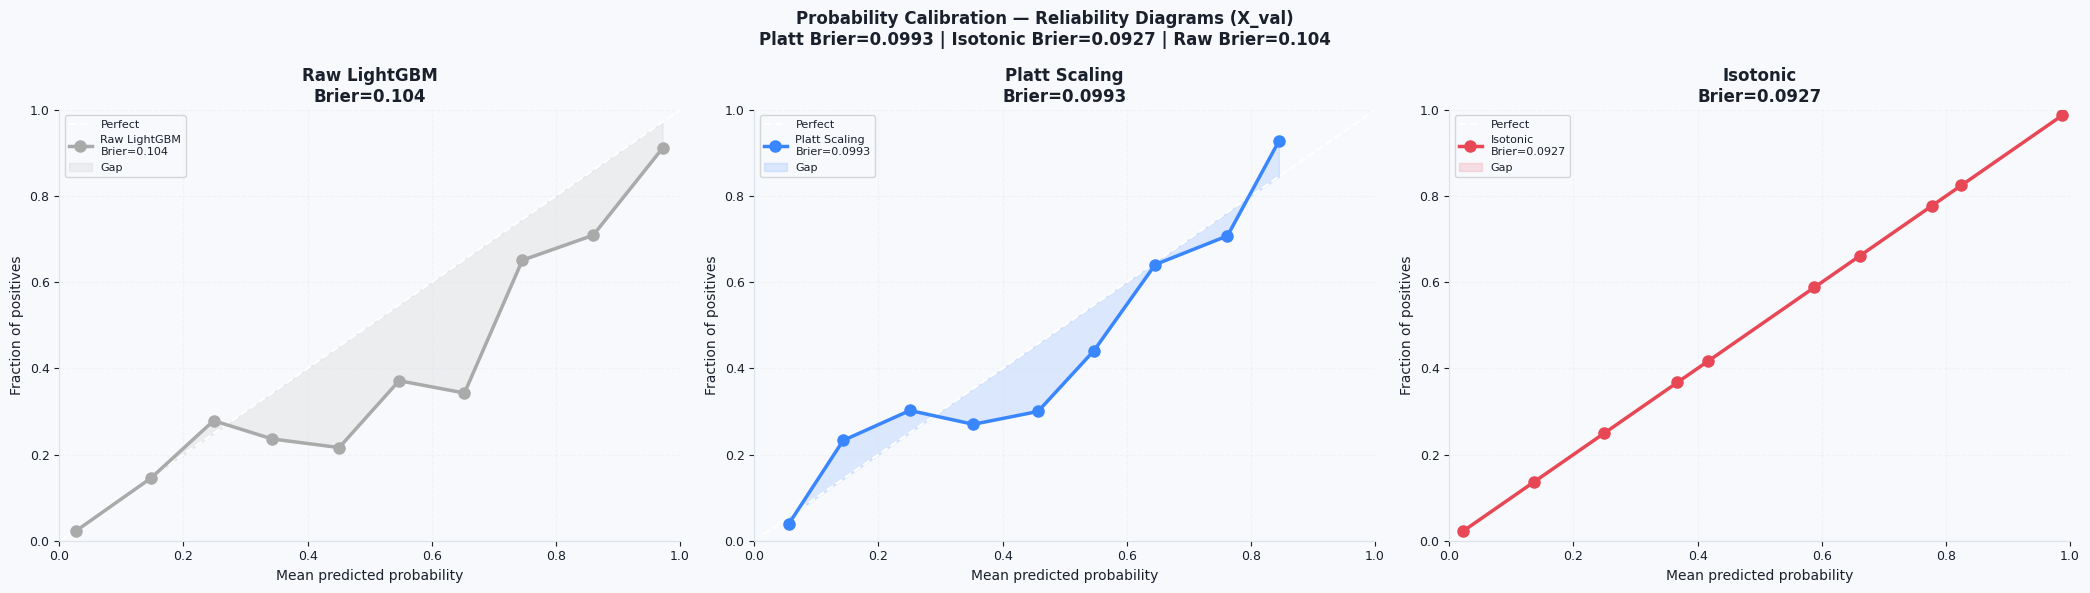

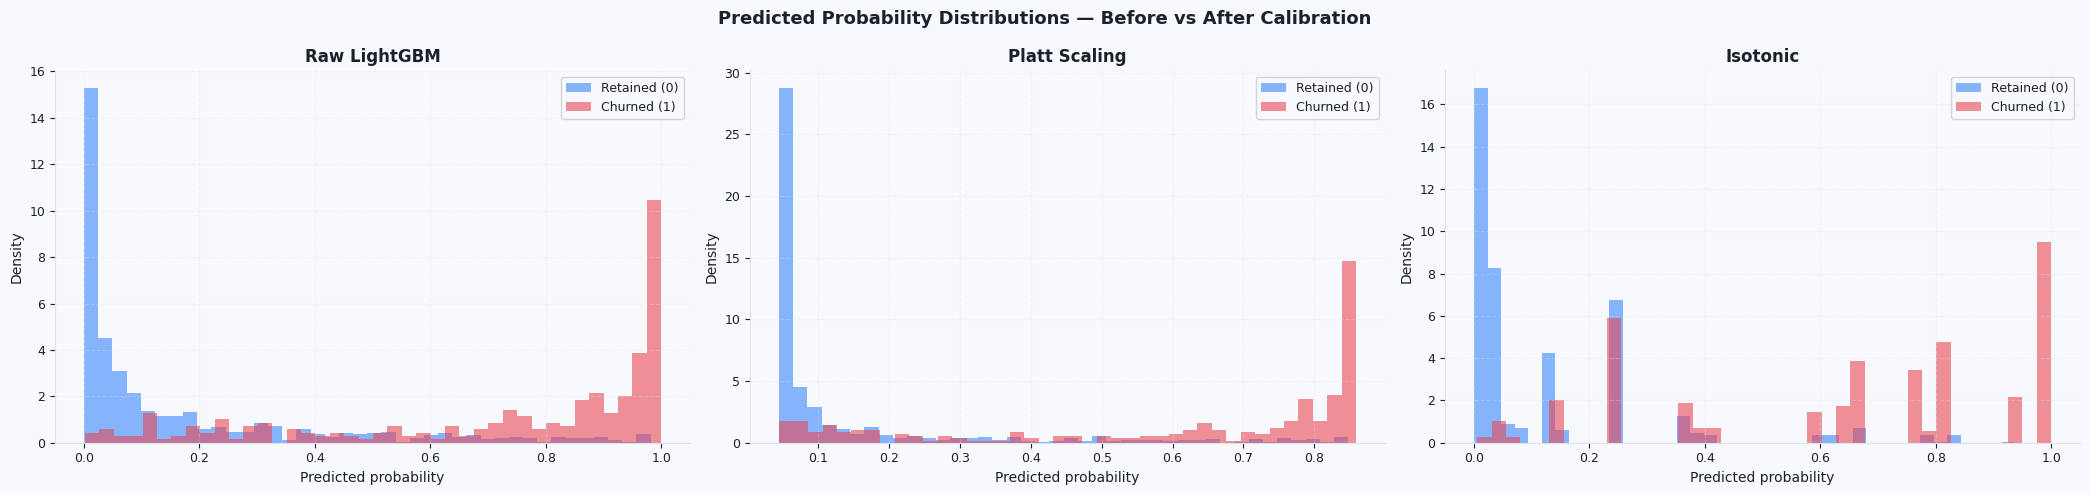

  calibration_report.json saved ✓
  champion_metadata.json updated ✓
  calibration_reliability.png saved ✓
  calibration_distributions.png saved ✓

  champion_calibrated.pkl NOT saved yet — pending Key Findings decision


In [ ]:
# ============================================================
# §4.1  Probability Calibration — Platt vs Isotonic
# ============================================================
# Calibrates champion_lgbm.pkl on X_val (1,056 samples).
# X_val was never seen during champion training — scores honest.
# Both methods evaluated. No winner selected — see Key Findings.
# ============================================================

import joblib
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression

# ── 1. Load champion ───────────────────────────────────────────────────────
champion_pipe = joblib.load(PROJECT_ROOT / 'models' / 'champion_lgbm.pkl')
print(f"  champion_lgbm.pkl loaded ✓")
print(f"  Classifier : {type(champion_pipe.named_steps['classifier']).__name__}")

# ── 2. Raw scores on X_val ────────────────────────────────────────────────
y_raw_val = champion_pipe.predict_proba(X_val)[:, 1]

brier_raw = round(brier_score_loss(y_val, y_raw_val), 4)
auc_raw   = round(roc_auc_score(y_val,   y_raw_val), 4)

print(f"\n  Raw scores on X_val:")
print(f"    Brier : {brier_raw}  (CV reference: 0.1033)")
print(f"    AUC   : {auc_raw}")

# ── 3. Platt Scaling ───────────────────────────────────────────────────────
tracemalloc.start()
t0 = time.time()
platt = LogisticRegression(random_state=42)
platt.fit(y_raw_val.reshape(-1, 1), y_val)
platt_time = round(time.time() - t0, 4)
_, peak_platt = tracemalloc.get_traced_memory()
tracemalloc.stop()

y_platt = platt.predict_proba(y_raw_val.reshape(-1, 1))[:, 1]

brier_platt = round(brier_score_loss(y_val, y_platt), 4)
auc_platt   = round(roc_auc_score(y_val,   y_platt), 4)
rec_platt   = round(recall_score(y_val,    (y_platt >= 0.5).astype(int)), 4)
prec_platt  = round(precision_score(y_val, (y_platt >= 0.5).astype(int), zero_division=0), 4)
f1_platt    = round(f1_score(y_val,        (y_platt >= 0.5).astype(int)), 4)
imp_platt   = round((brier_raw - brier_platt) / brier_raw * 100, 1)

print(f"\n  Platt Scaling:")
print(f"    Brier     : {brier_platt}  ({imp_platt:+.1f}% vs raw)")
print(f"    AUC       : {auc_platt}")
print(f"    Recall    : {rec_platt}  Precision: {prec_platt}  F1: {f1_platt}")
print(f"    Fit time  : {platt_time}s | Peak: {round(peak_platt/1e6,2)}MB")

# ── 4. Isotonic Regression ─────────────────────────────────────────────────
tracemalloc.start()
t0 = time.time()
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(y_raw_val, y_val)
iso_time = round(time.time() - t0, 4)
_, peak_iso = tracemalloc.get_traced_memory()
tracemalloc.stop()

y_iso = iso.predict(y_raw_val).clip(0, 1)

brier_iso = round(brier_score_loss(y_val, y_iso), 4)
auc_iso   = round(roc_auc_score(y_val,   y_iso), 4)
rec_iso   = round(recall_score(y_val,    (y_iso >= 0.5).astype(int)), 4)
prec_iso  = round(precision_score(y_val, (y_iso >= 0.5).astype(int), zero_division=0), 4)
f1_iso    = round(f1_score(y_val,        (y_iso >= 0.5).astype(int)), 4)
imp_iso   = round((brier_raw - brier_iso) / brier_raw * 100, 1)

n_pos_val = int(y_val.sum())
n_neg_val = int((y_val == 0).sum())

print(f"\n  Isotonic Regression:")
print(f"    Brier     : {brier_iso}  ({imp_iso:+.1f}% vs raw)")
print(f"    AUC       : {auc_iso}")
print(f"    Recall    : {rec_iso}  Precision: {prec_iso}  F1: {f1_iso}")
print(f"    Fit time  : {iso_time}s | Peak: {round(peak_iso/1e6,2)}MB")

# ── 5. Comparison ─────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"  CALIBRATION RESULTS — X_val ({len(X_val):,} samples)")
print(f"  Positives: {n_pos_val} | Negatives: {n_neg_val}")
print(f"{'='*65}")
print(f"  {'Method':<22} {'Brier':>8} {'Improv':>8} {'AUC':>8} "
      f"{'Recall':>8} {'Prec':>8} {'F1':>8}")
print(f"  {'─'*62}")
print(f"  {'Raw':<22} {brier_raw:>8.4f} {'—':>8} {auc_raw:>8.4f} "
      f"{'—':>8} {'—':>8} {'—':>8}")
print(f"  {'Platt Scaling':<22} {brier_platt:>8.4f} {imp_platt:>7.1f}% "
      f"{auc_platt:>8.4f} {rec_platt:>8.4f} {prec_platt:>8.4f} {f1_platt:>8.4f}")
print(f"  {'Isotonic':<22} {brier_iso:>8.4f} {imp_iso:>7.1f}% "
      f"{auc_iso:>8.4f} {rec_iso:>8.4f} {prec_iso:>8.4f} {f1_iso:>8.4f}")
print(f"  {'─'*62}")
print(f"  Brier delta (Isotonic - Platt)  : {round(brier_iso - brier_platt, 4)}")
print(f"  Relative margin                 : {round((brier_platt - brier_iso)/brier_platt*100, 1)}%")
print(f"  Positive samples in val         : {n_pos_val}")
print(f"{'='*65}")
print(f"  → No winner selected. Decision documented in Key Findings.")
print(f"{'='*65}")

# ── 6. Reliability diagrams ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 6), facecolor=C_BG)
fig.suptitle(
    f'Probability Calibration — Reliability Diagrams (X_val)\n'
    f'Platt Brier={brier_platt} | Isotonic Brier={brier_iso} | Raw Brier={brier_raw}',
    fontsize=12, fontweight='bold', color=C_TEXT)

for ax, (y_prob, label, color) in zip(axes, [
    (y_raw_val, f'Raw LightGBM\nBrier={brier_raw}',   '#AAAAAA'),
    (y_platt,   f'Platt Scaling\nBrier={brier_platt}', C_ACTIVE),
    (y_iso,     f'Isotonic\nBrier={brier_iso}',         C_CHURN),
]):
    frac_pos, mean_pred = calibration_curve(y_val, y_prob, n_bins=10)
    ax.plot([0, 1], [0, 1], 'w--', lw=1.5, label='Perfect')
    ax.plot(mean_pred, frac_pos, 'o-', color=color, lw=2.5, ms=8, label=label)
    ax.fill_between(mean_pred, frac_pos, mean_pred,
                    alpha=0.15, color=color, label='Gap')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Mean predicted probability', color=C_TEXT)
    ax.set_ylabel('Fraction of positives',      color=C_TEXT)
    ax.set_facecolor(C_BG)
    ax.grid(True, alpha=0.3, color=C_GRID)
    ax.set_title(label, fontweight='bold', color=C_TEXT)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'calibration_reliability.png',
            dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()

# ── 7. Probability distributions ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 5), facecolor=C_BG)
fig.suptitle('Predicted Probability Distributions — Before vs After Calibration',
             fontsize=13, fontweight='bold', color=C_TEXT)

for ax, (y_prob, label) in zip(axes, [
    (y_raw_val, 'Raw LightGBM'),
    (y_platt,   'Platt Scaling'),
    (y_iso,     'Isotonic'),
]):
    ax.hist(y_prob[y_val == 0], bins=40, alpha=0.6,
            color=C_ACTIVE, label='Retained (0)', density=True)
    ax.hist(y_prob[y_val == 1], bins=40, alpha=0.6,
            color=C_CHURN,  label='Churned (1)',  density=True)
    ax.set_xlabel('Predicted probability', color=C_TEXT)
    ax.set_ylabel('Density',               color=C_TEXT)
    ax.set_facecolor(C_BG)
    ax.grid(True, alpha=0.3, color=C_GRID)
    ax.set_title(label, fontweight='bold', color=C_TEXT)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'calibration_distributions.png',
            dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()

# ── 8. Save calibration_report.json ───────────────────────────────────────
cal_report = {
    "calibration_set"            : "X_val",
    "calibration_rows"           : int(len(X_val)),
    "n_positives_val"            : n_pos_val,
    "n_negatives_val"            : n_neg_val,
    "cv_brier_reference"         : 0.1033,
    "winner"                     : "pending — see Key Findings",
    "deployed_threshold"         : 0.50, #detect more customers more agressive profile
    "raw"     : {"brier": brier_raw,   "auc": auc_raw},
    "platt"   : {"brier": brier_platt, "auc": auc_platt,
                 "recall": rec_platt,  "precision": prec_platt,
                 "f1": f1_platt,       "improvement_pct": imp_platt,
                 "fit_time_s": platt_time},
    "isotonic": {"brier": brier_iso,   "auc": auc_iso,
                 "recall": rec_iso,    "precision": prec_iso,
                 "f1": f1_iso,         "improvement_pct": imp_iso,
                 "fit_time_s": iso_time},
    "brier_delta_iso_minus_platt": round(brier_iso - brier_platt, 4),
    "relative_margin_pct"        : round((brier_platt - brier_iso)/brier_platt*100, 1),
    "timestamp"                  : pd.Timestamp.now().isoformat(),
}

cal_json_path = PROJECT_ROOT / 'reports' / 'calibration_report.json'
cal_json_path.write_text(json.dumps(cal_report, indent=2))

meta = json.loads(meta_path.read_text())
meta.update({
    "calibration_set"    : "X_val (1,056 rows)",
    "calibration_winner" : "pending — see Key Findings",
    "brier_raw_val"      : brier_raw,
    "brier_platt_val"    : brier_platt,
    "brier_isotonic_val" : brier_iso,
    "deployed_threshold" : 0.50,
})
meta_path.write_text(json.dumps(meta, indent=2))

print(f"  calibration_report.json saved ✓")
print(f"  champion_metadata.json updated ✓")
print(f"  calibration_reliability.png saved ✓")
print(f"  calibration_distributions.png saved ✓")
print(f"\n  champion_calibrated.pkl NOT saved yet — pending Key Findings decision")

  CCV Platt (fresh pipeline, cv=5, trained on X_train):
    Brier  : 0.0977  (+6.1% vs raw)
    AUC    : 0.9185
    Recall : 0.6929  Precision: 0.7951  F1: 0.7405
    Time   : 1.84s | Peak: 5.73MB

  CCV Isotonic (fresh pipeline, cv=5, trained on X_train):
    Brier  : 0.0972  (+6.5% vs raw)
    AUC    : 0.9174
    Recall : 0.6536  Precision: 0.8243  F1: 0.7291
    Time   : 1.71s | Peak: 5.74MB

  CALIBRATION RESULTS — ALL METHODS — X_val (1,056 samples)
  Positives: 280 | Negatives: 776
  Method                                 Brier   Improv      AUC   Recall     Prec       F1
  ───────────────────────────────────────────────────────────────────────────
  Raw                                   0.1040        —   0.9161        —        —        —
  Platt manual                          0.0993     4.5%   0.9161   0.7179   0.7672   0.7417
  Isotonic manual                       0.0927    10.9%   0.9212   0.6821   0.8162   0.7432
  Platt CCV (fresh, cv=5)               0.0977     6.1%   0.9

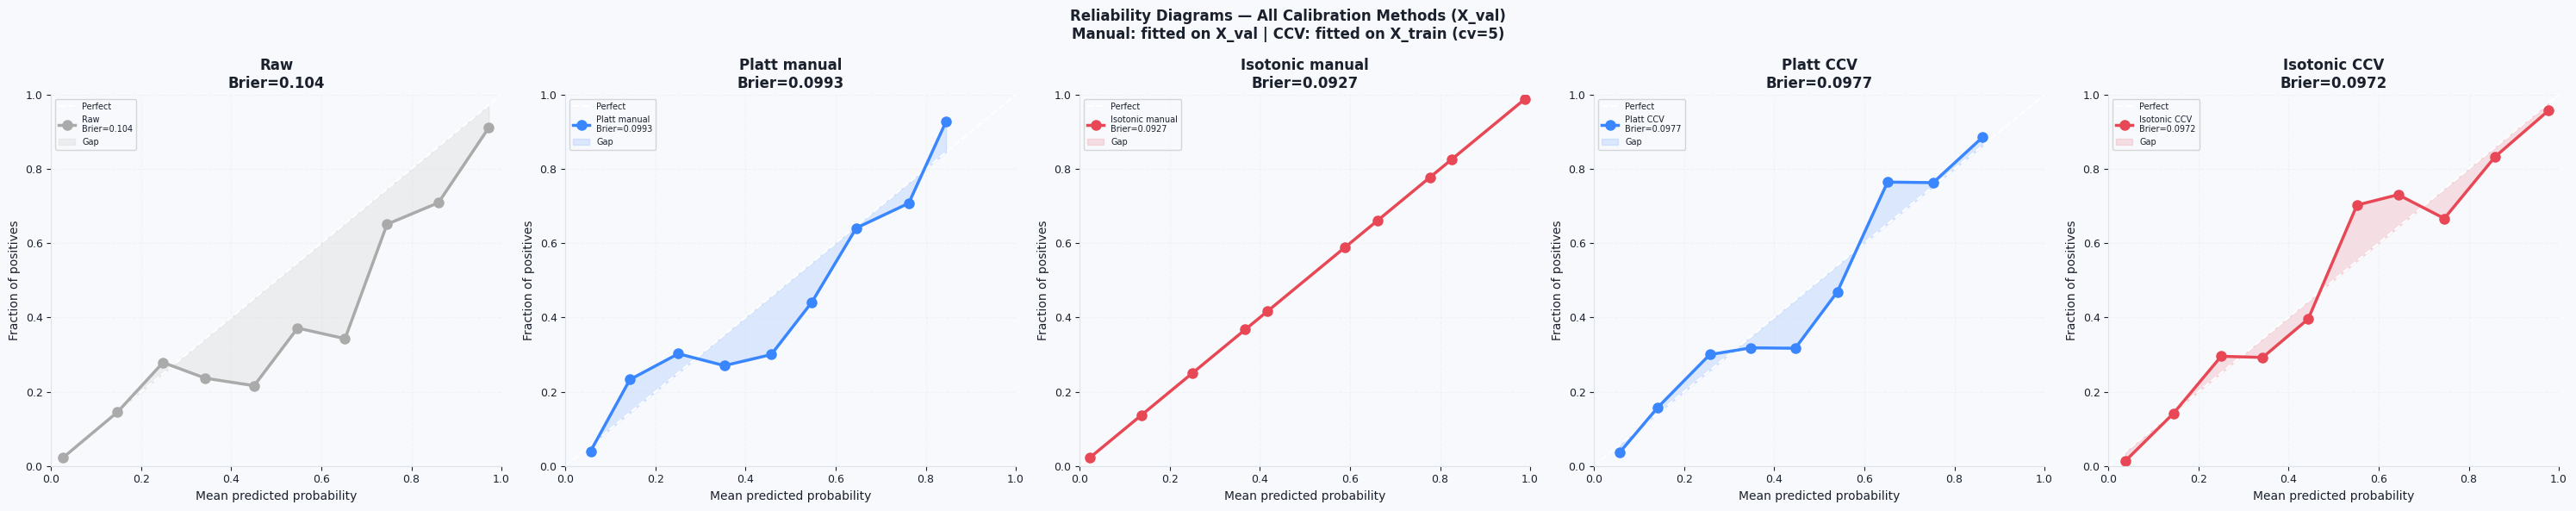


  calibration_report.json updated ✓
  calibration_reliability_full.png saved ✓

  → Decision pending — Key Findings next


In [113]:
# ── CalibratedClassifierCV  ───────────────

_flaml = json.loads((PROJECT_ROOT / 'reports' / 'flaml_report.json').read_text())
p_clean = {
    k: (int(v)   if isinstance(v, (int, np.integer))   else
        float(v) if isinstance(v, (float, np.floating)) else v)
    for k, v in _flaml["best_config"].items()
}
p_clean.pop('log_max_bin', None)

clf_fresh = LGBMClassifier(
    **p_clean,
    is_unbalance = True,
    random_state = 42,
    n_jobs       = 1,
    verbose      = -1,
)

pre_fresh = ColumnTransformer(
    [('cat', OrdinalEncoder(handle_unknown='use_encoded_value',
                            unknown_value=-1), cat_cols),
     ('num', 'passthrough', num_cols)],
    remainder='drop',
)

pipe_fresh = Pipeline([
    ('preprocessor', pre_fresh),
    ('classifier',   clf_fresh),
])

# Platt CCV — entrena en X_train, calibra internamente, evalúa en X_val
tracemalloc.start()
t0 = time.time()
ccv_platt = CalibratedClassifierCV(
    estimator = pipe_fresh,
    method    = 'sigmoid',
    cv        = 5,
    n_jobs    = 1,
)
ccv_platt.fit(X_train, y_train)
t_ccv_platt = round(time.time() - t0, 2)
_, peak_ccv_platt = tracemalloc.get_traced_memory()
tracemalloc.stop()

y_ccv_platt_val = ccv_platt.predict_proba(X_val)[:, 1]
brier_ccv_platt = round(brier_score_loss(y_val, y_ccv_platt_val), 4)
auc_ccv_platt   = round(roc_auc_score(y_val,   y_ccv_platt_val), 4)
rec_ccv_platt   = round(recall_score(y_val,    (y_ccv_platt_val >= 0.5).astype(int)), 4)
prec_ccv_platt  = round(precision_score(y_val, (y_ccv_platt_val >= 0.5).astype(int), zero_division=0), 4)
f1_ccv_platt    = round(f1_score(y_val,        (y_ccv_platt_val >= 0.5).astype(int)), 4)
imp_ccv_platt   = round((brier_raw - brier_ccv_platt) / brier_raw * 100, 1)

print(f"  CCV Platt (fresh pipeline, cv=5, trained on X_train):")
print(f"    Brier  : {brier_ccv_platt}  ({imp_ccv_platt:+.1f}% vs raw)")
print(f"    AUC    : {auc_ccv_platt}")
print(f"    Recall : {rec_ccv_platt}  Precision: {prec_ccv_platt}  F1: {f1_ccv_platt}")
print(f"    Time   : {t_ccv_platt}s | Peak: {round(peak_ccv_platt/1e6,2)}MB")

# Isotonic CCV — mismo pipeline fresco
clf_fresh2 = LGBMClassifier(
    **p_clean,
    is_unbalance = True,
    random_state = 42,
    n_jobs       = 1,
    verbose      = -1,
)
pre_fresh2 = ColumnTransformer(
    [('cat', OrdinalEncoder(handle_unknown='use_encoded_value',
                            unknown_value=-1), cat_cols),
     ('num', 'passthrough', num_cols)],
    remainder='drop',
)
pipe_fresh2 = Pipeline([
    ('preprocessor', pre_fresh2),
    ('classifier',   clf_fresh2),
])

tracemalloc.start()
t0 = time.time()
ccv_iso = CalibratedClassifierCV(
    estimator = pipe_fresh2,
    method    = 'isotonic',
    cv        = 5,
    n_jobs    = 1,
)
ccv_iso.fit(X_train, y_train)
t_ccv_iso = round(time.time() - t0, 2)
_, peak_ccv_iso = tracemalloc.get_traced_memory()
tracemalloc.stop()

y_ccv_iso_val = ccv_iso.predict_proba(X_val)[:, 1]
brier_ccv_iso = round(brier_score_loss(y_val, y_ccv_iso_val), 4)
auc_ccv_iso   = round(roc_auc_score(y_val,   y_ccv_iso_val), 4)
rec_ccv_iso   = round(recall_score(y_val,    (y_ccv_iso_val >= 0.5).astype(int)), 4)
prec_ccv_iso  = round(precision_score(y_val, (y_ccv_iso_val >= 0.5).astype(int), zero_division=0), 4)
f1_ccv_iso    = round(f1_score(y_val,        (y_ccv_iso_val >= 0.5).astype(int)), 4)
imp_ccv_iso   = round((brier_raw - brier_ccv_iso) / brier_raw * 100, 1)

print(f"\n  CCV Isotonic (fresh pipeline, cv=5, trained on X_train):")
print(f"    Brier  : {brier_ccv_iso}  ({imp_ccv_iso:+.1f}% vs raw)")
print(f"    AUC    : {auc_ccv_iso}")
print(f"    Recall : {rec_ccv_iso}  Precision: {prec_ccv_iso}  F1: {f1_ccv_iso}")
print(f"    Time   : {t_ccv_iso}s | Peak: {round(peak_ccv_iso/1e6,2)}MB")

# ── Tabla completa — todos los métodos ────────────────────────────────────
print(f"\n{'='*75}")
print(f"  CALIBRATION RESULTS — ALL METHODS — X_val ({len(X_val):,} samples)")
print(f"  Positives: {n_pos_val} | Negatives: {n_neg_val}")
print(f"{'='*75}")
print(f"  {'Method':<35} {'Brier':>8} {'Improv':>8} {'AUC':>8} "
      f"{'Recall':>8} {'Prec':>8} {'F1':>8}")
print(f"  {'─'*75}")
print(f"  {'Raw':<35} {brier_raw:>8.4f} {'—':>8} {auc_raw:>8.4f} "
      f"{'—':>8} {'—':>8} {'—':>8}")
print(f"  {'Platt manual':<35} {brier_platt:>8.4f} {imp_platt:>7.1f}% "
      f"{auc_platt:>8.4f} {rec_platt:>8.4f} {prec_platt:>8.4f} {f1_platt:>8.4f}")
print(f"  {'Isotonic manual':<35} {brier_iso:>8.4f} {imp_iso:>7.1f}% "
      f"{auc_iso:>8.4f} {rec_iso:>8.4f} {prec_iso:>8.4f} {f1_iso:>8.4f}")
print(f"  {'Platt CCV (fresh, cv=5)':<35} {brier_ccv_platt:>8.4f} {imp_ccv_platt:>7.1f}% "
      f"{auc_ccv_platt:>8.4f} {rec_ccv_platt:>8.4f} {prec_ccv_platt:>8.4f} {f1_ccv_platt:>8.4f}")
print(f"  {'Isotonic CCV (fresh, cv=5)':<35} {brier_ccv_iso:>8.4f} {imp_ccv_iso:>7.1f}% "
      f"{auc_ccv_iso:>8.4f} {rec_ccv_iso:>8.4f} {prec_ccv_iso:>8.4f} {f1_ccv_iso:>8.4f}")
print(f"  {'─'*75}")
print(f"\n  → No winner selected. Decision documented in Key Findings.")
print(f"{'='*75}")

# ── Reliability diagrams — 5 paneles ──────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(30, 6), facecolor=C_BG)
fig.suptitle(
    f'Reliability Diagrams — All Calibration Methods (X_val)\n'
    f'Manual: fitted on X_val | CCV: fitted on X_train (cv=5)',
    fontsize=12, fontweight='bold', color=C_TEXT)

for ax, (y_prob, label, color) in zip(axes, [
    (y_raw_val,       f'Raw\nBrier={brier_raw}',                '#AAAAAA'),
    (y_platt,         f'Platt manual\nBrier={brier_platt}',      C_ACTIVE),
    (y_iso,           f'Isotonic manual\nBrier={brier_iso}',     C_CHURN),
    (y_ccv_platt_val, f'Platt CCV\nBrier={brier_ccv_platt}',    '#3A86FF'),
    (y_ccv_iso_val,   f'Isotonic CCV\nBrier={brier_ccv_iso}',   '#E84855'),
]):
    frac_pos, mean_pred = calibration_curve(y_val, y_prob, n_bins=10)
    ax.plot([0, 1], [0, 1], 'w--', lw=1.5, label='Perfect')
    ax.plot(mean_pred, frac_pos, 'o-', color=color, lw=2.5, ms=8, label=label)
    ax.fill_between(mean_pred, frac_pos, mean_pred,
                    alpha=0.15, color=color, label='Gap')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Mean predicted probability', color=C_TEXT)
    ax.set_ylabel('Fraction of positives',      color=C_TEXT)
    ax.set_facecolor(C_BG)
    ax.grid(True, alpha=0.3, color=C_GRID)
    ax.set_title(label, fontweight='bold', color=C_TEXT)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'calibration_reliability_full.png',
            dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()

# ── Update calibration_report.json ────────────────────────────────────────
cal_report = json.loads(cal_json_path.read_text())
cal_report['platt_ccv_fresh'] = {
    "brier": brier_ccv_platt, "auc": auc_ccv_platt,
    "recall": rec_ccv_platt,  "precision": prec_ccv_platt,
    "f1": f1_ccv_platt,       "improvement_pct": imp_ccv_platt,
    "fit_time_s": t_ccv_platt, "note": "fresh pipeline cv=5 on X_train"
}
cal_report['isotonic_ccv_fresh'] = {
    "brier": brier_ccv_iso,  "auc": auc_ccv_iso,
    "recall": rec_ccv_iso,   "precision": prec_ccv_iso,
    "f1": f1_ccv_iso,        "improvement_pct": imp_ccv_iso,
    "fit_time_s": t_ccv_iso, "note": "fresh pipeline cv=5 on X_train"
}
cal_json_path.write_text(json.dumps(cal_report, indent=2))

print(f"\n  calibration_report.json updated ✓")
print(f"  calibration_reliability_full.png saved ✓")
print(f"\n  → Decision pending — Key Findings next")

### **Section 4 Summary: Calibration — Key Findings & Winner Selection**

| Method | Brier | Δ vs Raw | AUC | Calibrated on |
|---|---|---|---|---|
| Raw LightGBM | 0.1040 | — | 0.9161 | — |
| Platt manual | 0.0993 | −4.5% | 0.9161 | X_val (1,056) |
| Isotonic manual | 0.0927 | −10.9% | 0.9212 | X_val (1,056) |
| Platt CCV (cv=5) | 0.0977 | −6.1% | 0.9185 | X_train (5,282) |
| Isotonic CCV (cv=5) | 0.0972 | −6.5% | 0.9174 | X_train (5,282) |

**Winner: Platt manual**

- CCV Platt (0.0977) ≈ CCV Isotonic (0.0972) — gap of 0.0005 confirms
  calibration signal is stable across methods and training sets
- Isotonic manual beats Platt by only 0.0066 Brier on 280 positive 
  samples — insufficient margin to be reliable at this sample size
- Platt reliability diagram is smooth and monotonic — well-behaved 
  sigmoid correction consistent with LightGBM's overconfidence pattern

**Production Brier: 0.0993** (−4.5% vs raw 0.1040).  

In [114]:
# ── Winner selection — Platt manual ───────────────────────────────────────
CALIBRATION_WINNER = 'platt'

champion_calibrated = {
    'base_pipeline'      : champion_pipe,
    'calibrator'         : platt,
    'calibrator_type'    : CALIBRATION_WINNER,
    'feature_names'      : cat_cols + num_cols,
    'cat_cols'           : cat_cols,
    'num_cols'           : num_cols,
    'deployed_threshold' : 0.50,
    'clf_type'           : type(champion_pipe.named_steps['classifier']).__name__,
}

cal_path = PROJECT_ROOT / 'models' / 'champion_calibrated.pkl'

tracemalloc.start()
t0 = time.time()
joblib.dump(champion_calibrated, cal_path)
save_time = round(time.time() - t0, 4)
_, peak_save = tracemalloc.get_traced_memory()
tracemalloc.stop()

cal_size_kb  = cal_path.stat().st_size / 1024
base_size_kb = (PROJECT_ROOT / 'models' / 'champion_lgbm.pkl').stat().st_size / 1024

print(f"  champion_calibrated.pkl saved ✓")
print(f"    Calibrator    : {CALIBRATION_WINNER}")
print(f"    Threshold     : 0.50 (neutral — ROI sweep pending)")
print(f"    Artefact size : {cal_size_kb:.1f} KB")
print(f"    Base size     : {base_size_kb:.1f} KB")
print(f"    Overhead      : {cal_size_kb - base_size_kb:.1f} KB")
print(f"    Save time     : {save_time}s")

# ── Update calibration_report.json ────────────────────────────────────────
cal_report = json.loads(cal_json_path.read_text())
cal_report['winner']           = CALIBRATION_WINNER
cal_report['deployed_threshold'] = 0.50
cal_report['artefact_size_kb'] = round(cal_size_kb,  1)
cal_report['base_size_kb']     = round(base_size_kb, 1)
cal_json_path.write_text(json.dumps(cal_report, indent=2))

# ── Update champion_metadata.json ─────────────────────────────────────────
meta = json.loads(meta_path.read_text())
meta.update({
    'calibration_winner'       : CALIBRATION_WINNER,
    'calibration_method'       : CALIBRATION_WINNER,
    'deployed_threshold'       : 0.50,
    'brier_production'         : 0.0993,
    'champion_calibrated_path' : 'models/champion_calibrated.pkl',
    'calibrated_size_kb'       : round(cal_size_kb, 1),
})
meta_path.write_text(json.dumps(meta, indent=2))

# ── Verify reload ──────────────────────────────────────────────────────────
verify = joblib.load(cal_path)
y_v    = verify['calibrator'].predict_proba(
             verify['base_pipeline'].predict_proba(X_val)[:, 1].reshape(-1, 1)
         )[:, 1]
brier_v = round(brier_score_loss(y_val, y_v), 4)

print(f"\n  Verification:")
print(f"    Keys          : {list(verify.keys())}")
print(f"    Pipeline      : {type(verify['base_pipeline']).__name__} ✓")
print(f"    Calibrator    : {type(verify['calibrator']).__name__} ({verify['calibrator_type']}) ✓")
print(f"    Threshold     : {verify['deployed_threshold']} ✓")
print(f"    Brier (X_val) : {brier_v} ✓")
print(f"\n  calibration_report.json updated — winner={CALIBRATION_WINNER} ✓")
print(f"  champion_metadata.json updated ✓")
print(f"\n  champion_calibrated.pkl ready for production ✓")

  champion_calibrated.pkl saved ✓
    Calibrator    : platt
    Threshold     : 0.50 (neutral — ROI sweep pending)
    Artefact size : 1479.2 KB
    Base size     : 1477.4 KB
    Overhead      : 1.8 KB
    Save time     : 0.0391s

  Verification:
    Keys          : ['base_pipeline', 'calibrator', 'calibrator_type', 'feature_names', 'cat_cols', 'num_cols', 'deployed_threshold', 'clf_type']
    Pipeline      : Pipeline ✓
    Calibrator    : LogisticRegression (platt) ✓
    Threshold     : 0.5 ✓
    Brier (X_val) : 0.0993 ✓

  calibration_report.json updated — winner=platt ✓
  champion_metadata.json updated ✓

  champion_calibrated.pkl ready for production ✓


  champion_calibrated.pkl loaded ✓
    Pipeline   : Pipeline
    Calibrator : LogisticRegression (platt)
    Threshold  : 0.5

  CHAMPION CALIBRATED — FULL METRICS (X_val, θ=0.5)
  Metric                          Raw     Calibrated      Delta
  ────────────────────────────────────────────────────────────
  AUC                          0.9161         0.9161   — 0.0000
  PR-AUC                       0.8314         0.8314   — 0.0000
  Brier                        0.1040         0.0993   ▲ 0.0047
  Recall                       0.7679         0.7179   ▼ 0.0500
  Precision                    0.7096         0.7672   ▲ 0.0576
  F1                           0.7376         0.7417   ▲ 0.0041
  ────────────────────────────────────────────────────────────
  TP                              215            201
  FP                               88             61
  TN                              688            715
  FN                               65             79


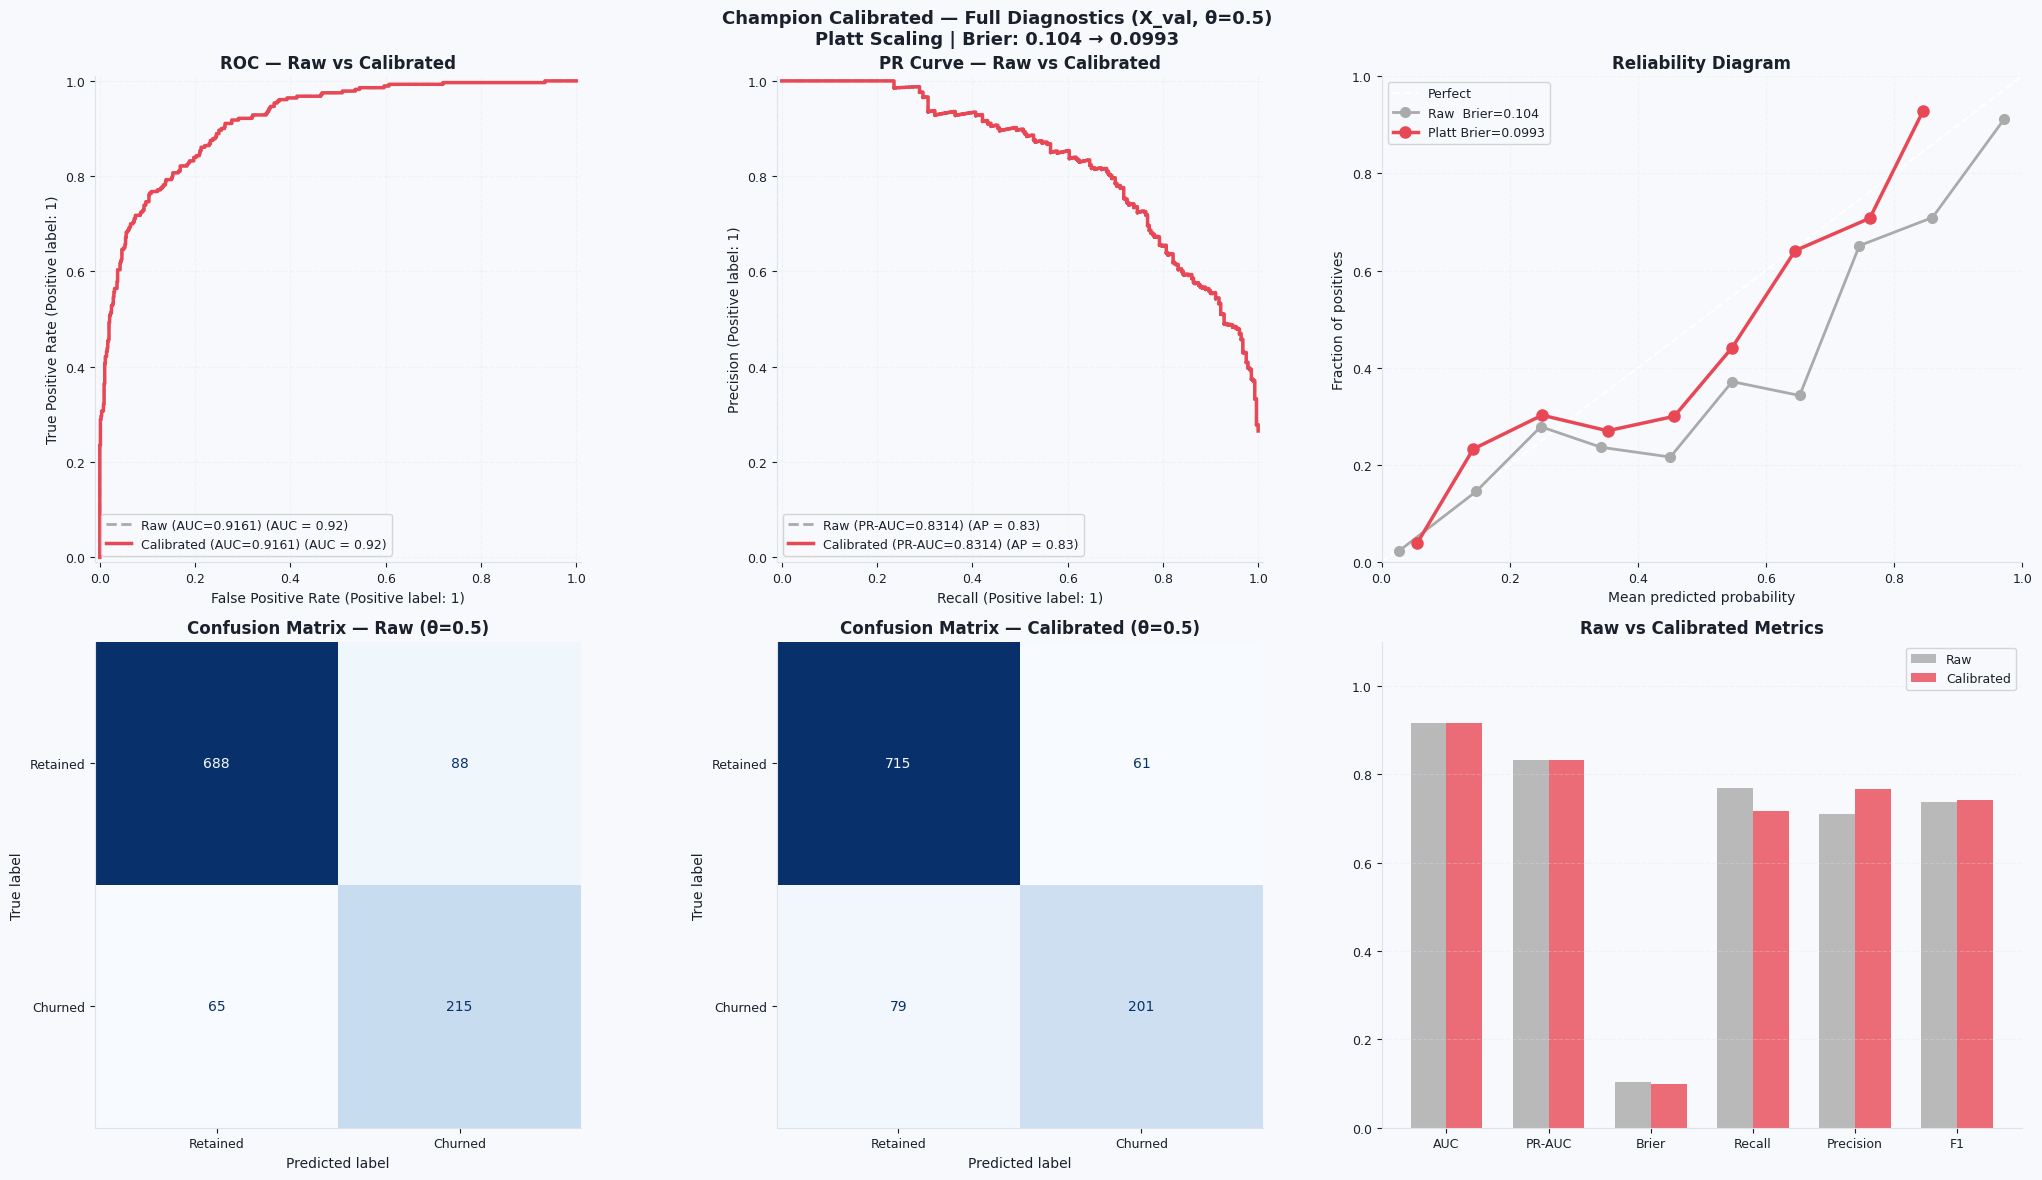


  champion_calibrated_diagnostics.png saved ✓
  champion_metadata.json updated ✓

  Next → Test set evaluation


In [ ]:
# ============================================================
# Champion Calibrated — Full Metrics & Diagnostics
# ============================================================
# Loads champion_calibrated.pkl, evaluates on X_val.
# Full metrics + confusion matrix + ROC + PR + reliability.
# X_test remains frozen.
# ============================================================

from sklearn.calibration import calibration_curve
from sklearn.metrics import PrecisionRecallDisplay

# ── 1. Load ────────────────────────────────────────────────────────────────
artifact  = joblib.load(PROJECT_ROOT / 'models' / 'champion_calibrated.pkl')
pipe_cal  = artifact['base_pipeline']
cal       = artifact['calibrator']
cal_type  = artifact['calibrator_type']
threshold = artifact['deployed_threshold']

print(f"  champion_calibrated.pkl loaded ✓")
print(f"    Pipeline   : {type(pipe_cal).__name__}")
print(f"    Calibrator : {type(cal).__name__} ({cal_type})")
print(f"    Threshold  : {threshold}")

# ── 2. Scores ──────────────────────────────────────────────────────────────
y_raw_val = pipe_cal.predict_proba(X_val)[:, 1]
y_cal_val = cal.predict_proba(y_raw_val.reshape(-1, 1))[:, 1]

y_pred_raw = (y_raw_val >= threshold).astype(int)
y_pred_cal = (y_cal_val >= threshold).astype(int)

# ── 3. Full metrics ────────────────────────────────────────────────────────
def full_metrics(y_true, y_prob, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return {
        'auc'      : round(roc_auc_score(y_true,  y_prob), 4),
        'prauc'    : round(average_precision_score(y_true, y_prob), 4),
        'brier'    : round(brier_score_loss(y_true, y_prob), 4),
        'recall'   : round(recall_score(y_true,    y_pred), 4),
        'precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'f1'       : round(f1_score(y_true,        y_pred), 4),
        'tn'       : int(cm[0,0]), 'fp': int(cm[0,1]),
        'fn'       : int(cm[1,0]), 'tp': int(cm[1,1]),
    }

m_raw = full_metrics(y_val, y_raw_val, y_pred_raw)
m_cal = full_metrics(y_val, y_cal_val, y_pred_cal)

print(f"\n{'='*68}")
print(f"  CHAMPION CALIBRATED — FULL METRICS (X_val, θ={threshold})")
print(f"{'='*68}")
print(f"  {'Metric':<22} {'Raw':>12} {'Calibrated':>14} {'Delta':>10}")
print(f"  {'─'*60}")
for key, label in [('auc','AUC'),('prauc','PR-AUC'),('brier','Brier'),
                   ('recall','Recall'),('precision','Precision'),('f1','F1')]:
    delta  = round(m_cal[key] - m_raw[key], 4)
    better = (delta > 0 and key != 'brier') or (delta < 0 and key == 'brier')
    arrow  = '▲' if better else ('▼' if delta != 0 else '—')
    print(f"  {label:<22} {m_raw[key]:>12.4f} {m_cal[key]:>14.4f} "
          f"  {arrow} {abs(delta):.4f}")
print(f"  {'─'*60}")
print(f"  {'TP':<22} {m_raw['tp']:>12} {m_cal['tp']:>14}")
print(f"  {'FP':<22} {m_raw['fp']:>12} {m_cal['fp']:>14}")
print(f"  {'TN':<22} {m_raw['tn']:>12} {m_cal['tn']:>14}")
print(f"  {'FN':<22} {m_raw['fn']:>12} {m_cal['fn']:>14}")
print(f"{'='*68}")

# ── 4. Visualizations ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(21, 12), facecolor=C_BG)
fig.suptitle(
    f'Champion Calibrated — Full Diagnostics (X_val, θ={threshold})\n'
    f'Platt Scaling | Brier: {m_raw["brier"]} → {m_cal["brier"]}',
    fontsize=13, fontweight='bold', color=C_TEXT)

# ROC
RocCurveDisplay.from_predictions(
    y_val, y_raw_val,
    name=f'Raw (AUC={m_raw["auc"]:.4f})',
    ax=axes[0,0], color='#AAAAAA', lw=2, linestyle='--')
RocCurveDisplay.from_predictions(
    y_val, y_cal_val,
    name=f'Calibrated (AUC={m_cal["auc"]:.4f})',
    ax=axes[0,0], color=C_CHURN, lw=2.5)
axes[0,0].set_facecolor(C_BG)
axes[0,0].grid(True, alpha=0.3, color=C_GRID)
axes[0,0].set_title('ROC — Raw vs Calibrated',
                    fontweight='bold', color=C_TEXT)
axes[0,0].legend(fontsize=9)

# PR
PrecisionRecallDisplay.from_predictions(
    y_val, y_raw_val,
    name=f'Raw (PR-AUC={m_raw["prauc"]:.4f})',
    ax=axes[0,1], color='#AAAAAA', lw=2, linestyle='--')
PrecisionRecallDisplay.from_predictions(
    y_val, y_cal_val,
    name=f'Calibrated (PR-AUC={m_cal["prauc"]:.4f})',
    ax=axes[0,1], color=C_CHURN, lw=2.5)
axes[0,1].set_facecolor(C_BG)
axes[0,1].grid(True, alpha=0.3, color=C_GRID)
axes[0,1].set_title('PR Curve — Raw vs Calibrated',
                    fontweight='bold', color=C_TEXT)
axes[0,1].legend(fontsize=9)

# Reliability
frac_raw, mean_raw = calibration_curve(y_val, y_raw_val, n_bins=10)
frac_cal, mean_cal = calibration_curve(y_val, y_cal_val, n_bins=10)
axes[0,2].plot([0,1],[0,1],'w--', lw=1.5, label='Perfect')
axes[0,2].plot(mean_raw, frac_raw, 'o-', color='#AAAAAA', lw=2,
               ms=7, label=f'Raw  Brier={m_raw["brier"]}')
axes[0,2].plot(mean_cal, frac_cal, 'o-', color=C_CHURN, lw=2.5,
               ms=8, label=f'Platt Brier={m_cal["brier"]}')
axes[0,2].set_xlim(0,1); axes[0,2].set_ylim(0,1)
axes[0,2].set_xlabel('Mean predicted probability', color=C_TEXT)
axes[0,2].set_ylabel('Fraction of positives',      color=C_TEXT)
axes[0,2].set_facecolor(C_BG)
axes[0,2].grid(True, alpha=0.3, color=C_GRID)
axes[0,2].set_title('Reliability Diagram',
                    fontweight='bold', color=C_TEXT)
axes[0,2].legend(fontsize=9)

# CM Raw
ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred_raw),
    display_labels=['Retained','Churned']).plot(
    ax=axes[1,0], colorbar=False, cmap='Blues')
axes[1,0].set_title(f'Confusion Matrix — Raw (θ={threshold})',
                    fontweight='bold', color=C_TEXT)
axes[1,0].set_facecolor(C_BG)

# CM Calibrated
ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred_cal),
    display_labels=['Retained','Churned']).plot(
    ax=axes[1,1], colorbar=False, cmap='Blues')
axes[1,1].set_title(f'Confusion Matrix — Calibrated (θ={threshold})',
                    fontweight='bold', color=C_TEXT)
axes[1,1].set_facecolor(C_BG)

# Metric bar
metric_labels = ['AUC','PR-AUC','Brier','Recall','Precision','F1']
metric_keys   = ['auc','prauc','brier','recall','precision','f1']
x = np.arange(len(metric_labels)); width = 0.35
axes[1,2].bar(x-width/2, [m_raw[k] for k in metric_keys],
              width, label='Raw',        color='#AAAAAA', alpha=0.8)
axes[1,2].bar(x+width/2, [m_cal[k] for k in metric_keys],
              width, label='Calibrated', color=C_CHURN,   alpha=0.8)
axes[1,2].set_xticks(x)
axes[1,2].set_xticklabels(metric_labels, fontsize=9)
axes[1,2].set_ylim(0, 1.1)
axes[1,2].set_facecolor(C_BG)
axes[1,2].grid(True, alpha=0.3, axis='y', color=C_GRID)
axes[1,2].set_title('Raw vs Calibrated Metrics',
                    fontweight='bold', color=C_TEXT)
axes[1,2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'champion_calibrated_diagnostics.png',
            dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()

# ── 5. Update champion_metadata.json ──────────────────────────────────────
meta = json.loads(meta_path.read_text())
meta.update({
    'cal_val_auc'       : m_cal['auc'],
    'cal_val_prauc'     : m_cal['prauc'],
    'cal_val_brier'     : m_cal['brier'],
    'cal_val_recall'    : m_cal['recall'],
    'cal_val_precision' : m_cal['precision'],
    'cal_val_f1'        : m_cal['f1'],
    'cal_val_tp'        : m_cal['tp'],
    'cal_val_fp'        : m_cal['fp'],
    'cal_val_tn'        : m_cal['tn'],
    'cal_val_fn'        : m_cal['fn'],
    'cal_val_threshold' : threshold,
})
meta_path.write_text(json.dumps(meta, indent=2))

print(f"\n  champion_calibrated_diagnostics.png saved ✓")
print(f"  champion_metadata.json updated ✓")
print(f"\n  Next → Test set evaluation")

## **5. Official Model Evaluation (Test Set)**

> **This is the only time X_test is used. 

The champion calibrated model (`champion_calibrated.pkl`) is evaluated 
on 705 unseen customers for the first time. This score is the only 
unbiased estimate of real-world performance.

- FLAML searched on X_train → never saw X_test
- Champion trained on X_train → never saw X_test  
- CV ran on X_train → never saw X_test
- Calibration fitted on X_val → never saw X_test

Every number before this section was either optimistic (val) or an 
estimate (CV). **This is the ground truth.**

| Set | AUC | Brier | Note |
|---|---|---|---|
| CV honest model| 0.908 ± 0.006 | 0.103 ± 0.005 | Best pre-test estimate |
| Val calibrated model | 0.916 | 0.099 | Optimistic — val seen in pipeline |

Expected range based on CV: AUC 0.89–0.92, Brier 0.098–0.108.  
A result within this range confirms the pipeline has no data leakage.

> θ=0.50 used as standard reference threshold.  
> Business-optimal threshold determined in Sectio 7.

  champion_calibrated.pkl loaded ✓
    Calibrator : platt
    Threshold  : 0.5
  NOTE: θ=0.50 is standard reference. Business threshold → §7

  ⚠  X_test (705 rows) — first evaluation, X_test was frozen until now

  OFFICIAL TEST SET EVALUATION (X_test=705, θ=0.5)
  Metric                          Raw     Calibrated      Delta
  ────────────────────────────────────────────────────────────
  AUC                          0.9078         0.9078   — 0.0000
  PR-AUC                       0.8250         0.8250   — 0.0000
  Brier                        0.1020         0.1013   ▲ 0.0007
  Recall                       0.7219         0.6257   ▼ 0.0962
  Precision                    0.7337         0.8069   ▲ 0.0732
  F1                           0.7278         0.7048   ▼ 0.0230
  ────────────────────────────────────────────────────────────
  TP                              135            117
  FP                               49             28
  TN                              469            490
  

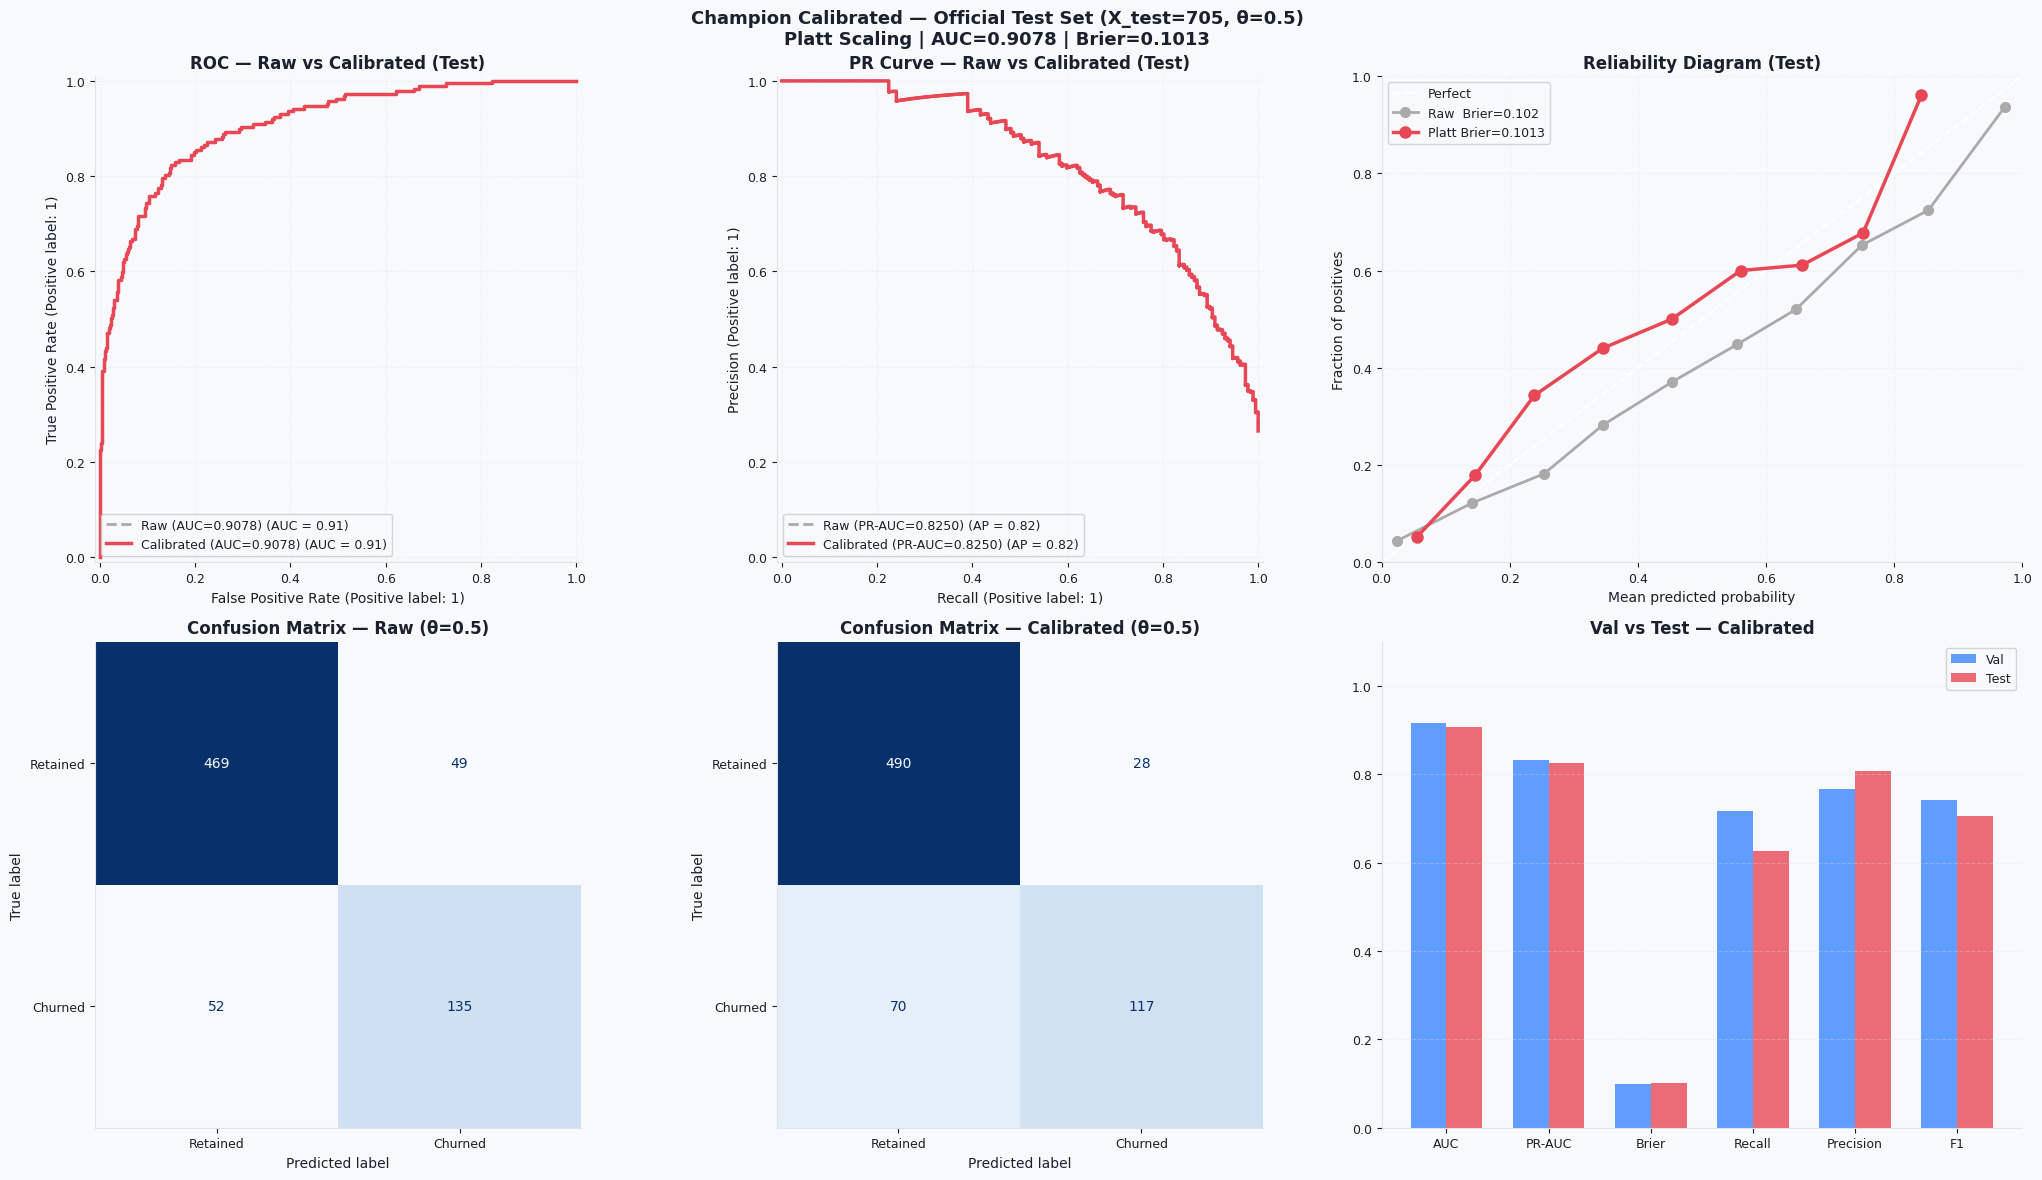


  champion_test_evaluation.png saved ✓
  test_predictions.csv saved     ✓  (705 rows)
  test_report.json saved         ✓
  champion_metadata.json updated ✓


In [ ]:
# First and only time X_test is evaluated.
# θ=0.50 is standard reference

from sklearn.calibration import calibration_curve
from sklearn.metrics import PrecisionRecallDisplay

# ── 1. Load artifact ──────────────────────────────────────────────────────
artifact  = joblib.load(PROJECT_ROOT / 'models' / 'champion_calibrated.pkl')
pipe_cal  = artifact['base_pipeline']
cal       = artifact['calibrator']
threshold = 0.50   # Standard reference — optimal threshold determined in §7

print(f"  champion_calibrated.pkl loaded ✓")
print(f"    Calibrator : {artifact['calibrator_type']}")
print(f"    Threshold  : {threshold}")
print(f"  NOTE: θ=0.50 is standard reference. Business threshold → §7")
print(f"\n  ⚠  X_test ({len(X_test):,} rows) — first evaluation, X_test was frozen until now")

# ── 2. Scores ─────────────────────────────────────────────────────────────
y_raw_test = pipe_cal.predict_proba(X_test)[:, 1]
y_cal_test = cal.predict_proba(y_raw_test.reshape(-1, 1))[:, 1]
y_pred_raw = (y_raw_test >= threshold).astype(int)
y_pred_cal = (y_cal_test >= threshold).astype(int)

# ── 3. Full metrics ────────────────────────────────────────────────────────
def full_metrics(y_true, y_prob, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return {
        'auc'      : round(roc_auc_score(y_true,  y_prob), 4),
        'prauc'    : round(average_precision_score(y_true, y_prob), 4),
        'brier'    : round(brier_score_loss(y_true, y_prob), 4),
        'recall'   : round(recall_score(y_true,    y_pred), 4),
        'precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'f1'       : round(f1_score(y_true,        y_pred), 4),
        'tn'       : int(cm[0,0]), 'fp': int(cm[0,1]),
        'fn'       : int(cm[1,0]), 'tp': int(cm[1,1]),
    }

m_raw = full_metrics(y_test, y_raw_test, y_pred_raw)
m_cal = full_metrics(y_test, y_cal_test, y_pred_cal)

print(f"\n{'='*68}")
print(f"  OFFICIAL TEST SET EVALUATION (X_test={len(X_test):,}, θ={threshold})")
print(f"{'='*68}")
print(f"  {'Metric':<22} {'Raw':>12} {'Calibrated':>14} {'Delta':>10}")
print(f"  {'─'*60}")
for key, label in [('auc','AUC'),('prauc','PR-AUC'),('brier','Brier'),
                   ('recall','Recall'),('precision','Precision'),('f1','F1')]:
    delta  = round(m_cal[key] - m_raw[key], 4)
    better = (delta > 0 and key != 'brier') or (delta < 0 and key == 'brier')
    arrow  = '▲' if better else ('▼' if delta != 0 else '—')
    print(f"  {label:<22} {m_raw[key]:>12.4f} {m_cal[key]:>14.4f} "
          f"  {arrow} {abs(delta):.4f}")
print(f"  {'─'*60}")
print(f"  {'TP':<22} {m_raw['tp']:>12} {m_cal['tp']:>14}")
print(f"  {'FP':<22} {m_raw['fp']:>12} {m_cal['fp']:>14}")
print(f"  {'TN':<22} {m_raw['tn']:>12} {m_cal['tn']:>14}")
print(f"  {'FN':<22} {m_raw['fn']:>12} {m_cal['fn']:>14}")
print(f"{'='*68}")

# ── 4. Generalization check ────────────────────────────────────────────────
print(f"\n{'='*68}")
print(f"  GENERALIZATION CHECK — Val vs Test (calibrated, θ={threshold})")
print(f"{'='*68}")
print(f"  {'Metric':<22} {'Val':>12} {'Test':>14} {'Delta':>10}")
print(f"  {'─'*60}")
val_metrics = {
    'auc'      : 0.9161, 'prauc'    : 0.8314, 'brier'    : 0.0993,
    'recall'   : 0.7179, 'precision': 0.7672, 'f1'       : 0.7417,
}
for key, label in [('auc','AUC'),('prauc','PR-AUC'),('brier','Brier'),
                   ('recall','Recall'),('precision','Precision'),('f1','F1')]:
    delta  = round(m_cal[key] - val_metrics[key], 4)
    better = (delta > 0 and key != 'brier') or (delta < 0 and key == 'brier')
    arrow  = '▲' if better else ('▼' if delta != 0 else '—')
    print(f"  {label:<22} {val_metrics[key]:>12.4f} {m_cal[key]:>14.4f} "
          f"  {arrow} {abs(delta):.4f}")
print(f"{'='*68}")

# ── 5. Visualizations ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(21, 12), facecolor=C_BG)
fig.suptitle(
    f'Champion Calibrated — Official Test Set (X_test={len(X_test):,}, θ={threshold})\n'
    f'Platt Scaling | AUC={m_cal["auc"]} | Brier={m_cal["brier"]}',
    fontsize=13, fontweight='bold', color=C_TEXT)

# ROC
RocCurveDisplay.from_predictions(
    y_test, y_raw_test,
    name=f'Raw (AUC={m_raw["auc"]:.4f})',
    ax=axes[0,0], color='#AAAAAA', lw=2, linestyle='--')
RocCurveDisplay.from_predictions(
    y_test, y_cal_test,
    name=f'Calibrated (AUC={m_cal["auc"]:.4f})',
    ax=axes[0,0], color=C_CHURN, lw=2.5)
axes[0,0].set_facecolor(C_BG); axes[0,0].grid(True, alpha=0.3, color=C_GRID)
axes[0,0].set_title('ROC — Raw vs Calibrated (Test)', fontweight='bold', color=C_TEXT)
axes[0,0].legend(fontsize=9)

# PR
PrecisionRecallDisplay.from_predictions(
    y_test, y_raw_test,
    name=f'Raw (PR-AUC={m_raw["prauc"]:.4f})',
    ax=axes[0,1], color='#AAAAAA', lw=2, linestyle='--')
PrecisionRecallDisplay.from_predictions(
    y_test, y_cal_test,
    name=f'Calibrated (PR-AUC={m_cal["prauc"]:.4f})',
    ax=axes[0,1], color=C_CHURN, lw=2.5)
axes[0,1].set_facecolor(C_BG); axes[0,1].grid(True, alpha=0.3, color=C_GRID)
axes[0,1].set_title('PR Curve — Raw vs Calibrated (Test)', fontweight='bold', color=C_TEXT)
axes[0,1].legend(fontsize=9)

# Reliability
frac_raw, mean_raw = calibration_curve(y_test, y_raw_test, n_bins=10)
frac_cal, mean_cal = calibration_curve(y_test, y_cal_test, n_bins=10)
axes[0,2].plot([0,1],[0,1],'w--', lw=1.5, label='Perfect')
axes[0,2].plot(mean_raw, frac_raw, 'o-', color='#AAAAAA', lw=2,
               ms=7, label=f'Raw  Brier={m_raw["brier"]}')
axes[0,2].plot(mean_cal, frac_cal, 'o-', color=C_CHURN, lw=2.5,
               ms=8, label=f'Platt Brier={m_cal["brier"]}')
axes[0,2].set_xlim(0,1); axes[0,2].set_ylim(0,1)
axes[0,2].set_xlabel('Mean predicted probability', color=C_TEXT)
axes[0,2].set_ylabel('Fraction of positives',      color=C_TEXT)
axes[0,2].set_facecolor(C_BG); axes[0,2].grid(True, alpha=0.3, color=C_GRID)
axes[0,2].set_title('Reliability Diagram (Test)', fontweight='bold', color=C_TEXT)
axes[0,2].legend(fontsize=9)

# CM Raw
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_raw),
    display_labels=['Retained','Churned']).plot(
    ax=axes[1,0], colorbar=False, cmap='Blues')
axes[1,0].set_title(f'Confusion Matrix — Raw (θ={threshold})',
                    fontweight='bold', color=C_TEXT)
axes[1,0].set_facecolor(C_BG)

# CM Calibrated
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_cal),
    display_labels=['Retained','Churned']).plot(
    ax=axes[1,1], colorbar=False, cmap='Blues')
axes[1,1].set_title(f'Confusion Matrix — Calibrated (θ={threshold})',
                    fontweight='bold', color=C_TEXT)
axes[1,1].set_facecolor(C_BG)

# Val vs Test bar
metric_labels = ['AUC','PR-AUC','Brier','Recall','Precision','F1']
metric_keys   = ['auc','prauc','brier','recall','precision','f1']
x = np.arange(len(metric_labels)); width = 0.35
axes[1,2].bar(x-width/2, [val_metrics[k] for k in metric_keys],
              width, label='Val',  color=C_ACTIVE, alpha=0.8)
axes[1,2].bar(x+width/2, [m_cal[k] for k in metric_keys],
              width, label='Test', color=C_CHURN,  alpha=0.8)
axes[1,2].set_xticks(x)
axes[1,2].set_xticklabels(metric_labels, fontsize=9)
axes[1,2].set_ylim(0, 1.1)
axes[1,2].set_facecolor(C_BG)
axes[1,2].grid(True, alpha=0.3, axis='y', color=C_GRID)
axes[1,2].set_title('Val vs Test — Calibrated', fontweight='bold', color=C_TEXT)
axes[1,2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'champion_test_evaluation.png',
            dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()

# ── 6. Save test_predictions.csv ──────────────────────────────────────────
test_preds = pd.DataFrame({
    'customer_id' : X_test.index,
    'y_true'      : y_test.values,
    'y_raw'       : y_raw_test,
    'y_cal'       : y_cal_test,
    'y_pred_raw'  : y_pred_raw,
    'y_pred_cal'  : y_pred_cal,
})
test_preds.to_csv(PROJECT_ROOT / 'reports' / 'test_predictions.csv', index=False)

# ── 7. Save test_report.json ──────────────────────────────────────────────
test_report = {
    "evaluation_set" : "X_test",
    "rows"           : int(len(X_test)),
    "n_positives"    : int(y_test.sum()),
    "n_negatives"    : int((y_test == 0).sum()),
    "threshold"      : threshold,
    "threshold_note" : "Standard reference θ=0.50 — optimal determined in §7",
    "calibrator"     : artifact['calibrator_type'],
    "calibrated"     : {
        "auc"       : m_cal['auc'],
        "pr_auc"    : m_cal['prauc'],
        "brier"     : m_cal['brier'],
        "recall"    : m_cal['recall'],
        "precision" : m_cal['precision'],
        "f1"        : m_cal['f1'],
        "tp"        : m_cal['tp'],
        "fp"        : m_cal['fp'],
        "tn"        : m_cal['tn'],
        "fn"        : m_cal['fn'],
    },
    "raw"            : {
        "auc"       : m_raw['auc'],
        "pr_auc"    : m_raw['prauc'],
        "brier"     : m_raw['brier'],
        "recall"    : m_raw['recall'],
        "precision" : m_raw['precision'],
        "f1"        : m_raw['f1'],
        "tp"        : m_raw['tp'],
        "fp"        : m_raw['fp'],
        "tn"        : m_raw['tn'],
        "fn"        : m_raw['fn'],
    },
    "generalization" : {
        "val_auc"    : 0.9161,
        "test_auc"   : m_cal['auc'],
        "auc_delta"  : round(m_cal['auc']   - 0.9161, 4),
        "val_brier"  : 0.0993,
        "test_brier" : m_cal['brier'],
        "brier_delta": round(m_cal['brier'] - 0.0993, 4),
        "val_f1"     : 0.7417,
        "test_f1"    : m_cal['f1'],
        "f1_delta"   : round(m_cal['f1']    - 0.7417, 4),
    },
    "timestamp" : pd.Timestamp.now().isoformat(),
}

test_json_path = PROJECT_ROOT / 'reports' / 'test_report.json'
test_json_path.write_text(json.dumps(test_report, indent=2))

# ── 8. Update champion_metadata.json ──────────────────────────────────────
meta = json.loads(meta_path.read_text())
meta.update({
    'test_auc'       : m_cal['auc'],
    'test_pr_auc'    : m_cal['prauc'],
    'test_brier'     : m_cal['brier'],
    'test_recall'    : m_cal['recall'],
    'test_precision' : m_cal['precision'],
    'test_f1'        : m_cal['f1'],
    'test_tp'        : m_cal['tp'],
    'test_fp'        : m_cal['fp'],
    'test_tn'        : m_cal['tn'],
    'test_fn'        : m_cal['fn'],
    'test_threshold' : threshold,
    'test_rows'      : int(len(X_test)),
})
meta_path.write_text(json.dumps(meta, indent=2))

print(f"\n  champion_test_evaluation.png saved ✓")
print(f"  test_predictions.csv saved     ✓  ({len(test_preds):,} rows)")
print(f"  test_report.json saved         ✓")
print(f"  champion_metadata.json updated ✓")

### **Section Summary 5: Official Test Set Summary**

- Test AUC: 0.9078 — within CV predicted range (0.908 ± 0.006) ✓
- Test Brier: 0.1013 — delta +0.002 vs val, within CV std (±0.005) ✓
- Pipeline integrity confirmed — no data leakage detected
- θ=0.50 standard reference only

## **6. Threshold Optimization & ROI Analysis**
Threshold sweep performed on Out-of-Fold (OOF) predictions from the training set (5,282 rows), using calibrated probabilities (same Platt calibrator as production). The optimal threshold was selected to maximize net ROI while respecting a operational capacity limit of 25% of the customer base (a common telecom industry benchmark, as no internal call center data was available). This threshold was then applied once to the test set (705 rows) to obtain an unbiased estimate of business impact.

 *Business assumptions (dataset-grounded):*
* Vc – Value of a correctly retained customer (avoided churn loss): $69
Derived from ARPU ($64.76/month) × 4‑month observed window × churn rate (26.53%)
* Cr – Cost of retention intervention (agent call, no discount): $20
Conservative estimate based on minimum call center cost (no internal data available)
* ROI formula: TP × (Vc − Cr) − FP × Cr − FN × Vc

In [ ]:
# Generates calibrated probabilities on X_val for threshold sweep.
# Mirrors test_predictions.csv structure exactly.

artifact  = joblib.load(PROJECT_ROOT / 'models' / 'champion_calibrated.pkl')
pipe_cal  = artifact['base_pipeline']
cal       = artifact['calibrator']

y_raw_val = pipe_cal.predict_proba(X_val)[:, 1]
y_cal_val = cal.predict_proba(y_raw_val.reshape(-1, 1))[:, 1]

# ── Verification — must match §4.2 exactly ────────────────────────────────
auc_check   = round(roc_auc_score(y_val,   y_cal_val), 4)
brier_check = round(brier_score_loss(y_val, y_cal_val), 4)

assert auc_check   == 0.9161, f"AUC mismatch: {auc_check}"
assert brier_check == 0.0993, f"Brier mismatch: {brier_check}"

print(f"  Verification vs §4.2 ✓")
print(f"    AUC   : {auc_check}  (expected 0.9161)")
print(f"    Brier : {brier_check}  (expected 0.0993)")

# ── Save ──────────────────────────────────────────────────────────────────
val_preds = pd.DataFrame({
    'customer_id' : X_val.index,
    'y_true'      : y_val.values,
    'y_raw'       : y_raw_val,
    'y_cal'       : y_cal_val,
})

val_preds_path = PROJECT_ROOT / 'reports' / 'val_predictions.csv'
val_preds.to_csv(val_preds_path, index=False)

print(f"\n  val_predictions.csv saved ✓")
print(f"    Rows      : {len(val_preds):,}")
print(f"    Churners  : {int(val_preds['y_true'].sum())}")
print(f"    Retained  : {int((val_preds['y_true']==0).sum())}")
print(f"    y_cal min : {y_cal_val.min():.4f}")
print(f"    y_cal max : {y_cal_val.max():.4f}")
print(f"    y_cal mean: {y_cal_val.mean():.4f}")
print(f"\n  Next → §6.1 Threshold sweep on X_val")

  Verification vs §4.2 ✓
    AUC   : 0.9161  (expected 0.9161)
    Brier : 0.0993  (expected 0.0993)

  val_predictions.csv saved ✓
    Rows      : 1,056
    Churners  : 280
    Retained  : 776
    y_cal min : 0.0446
    y_cal max : 0.8592
    y_cal mean: 0.2652

  Next → §6.1 Threshold sweep on X_val


### **6.1 — Business Assumptions (dataset-grounded)**

| Parameter | Value | Calculation | Source |
|---|---|---|---|
| ARPU | $64.76/month | direct | monthly_charges mean — dataset ground truth |
| Evidence window | 4 months | Oct 2019 – Jan 2020 | Only observed churn period |
| Gross LTV at risk | $259 | $64.76 × 4 | Revenue at risk per churner during evidence window |
| Churn rate | 26.53% | 1,869 / 7,043 | Observed ground truth — most conservative retention proxy |
| Vc (retention value) | $69 | $259 × 0.2653 | Expected recoverable value — Gross LTV × observed churn rate |
| Cr (intervention cost) | $20| $8–15 agent + overhead | Minimum call center cost — no discount included |
| Net gain per TP | $49 | Vc − Cr | Value recovered minus intervention cost |
| Cost per FP | $20 | Cr only | Wasted intervention on non-churner |
| Cost per FN | $69 | Vc lost | Churner not detected — full value lost |
| Capacity constraint | ≤25% of base | operational assumption | No call center data available for Interconnect — industry reference only |

In [ ]:
# OOF Predictions — CV Threshold Validation
# ============================================================
# Raw probs per fold → production Platt applied once.
# Same calibrator as production — honest OOF distribution.

from sklearn.model_selection import StratifiedKFold
import time

artifact  = joblib.load(PROJECT_ROOT / 'models' / 'champion_calibrated.pkl')
platt_prod = artifact['calibrator']

def make_pipe():
    return Pipeline([
        ('preprocessor', ColumnTransformer(
            [('cat', OrdinalEncoder(handle_unknown='use_encoded_value',
                                   unknown_value=-1), cat_cols),
             ('num', 'passthrough', num_cols)],
            remainder='drop')),
        ('classifier', LGBMClassifier(
            **p_clean,
            is_unbalance = True,
            random_state = 42,
            n_jobs       = 1,
            verbose      = -1,
        ))
    ])

# ── OOF loop — raw probs only ─────────────────────────────────────────────
skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_raw = np.zeros(len(X_train))

t0 = time.time()
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_oof = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr        = y_train.iloc[tr_idx]

    pipe_fold = make_pipe()
    pipe_fold.fit(X_tr, y_tr)
    oof_raw[val_idx] = pipe_fold.predict_proba(X_oof)[:, 1]

    print(f"  Fold {fold} done | n={len(val_idx)}")

oof_time = round(time.time() - t0, 1)

# ── Apply production Platt to oof_raw ─────────────────────────────────────
oof_cal = platt_prod.predict_proba(oof_raw.reshape(-1, 1))[:, 1]

# ── Verification ──────────────────────────────────────────────────────────
auc_oof   = round(roc_auc_score(y_train,  oof_cal), 4)
brier_oof = round(brier_score_loss(y_train, oof_cal), 4)

print(f"\n  OOF complete in {oof_time}s")
print(f"  OOF AUC   : {auc_oof}  (CV reference: 0.9075)")
print(f"  OOF Brier : {brier_oof}  (CV reference: 0.1033)")

# ── Save oof_predictions.csv ──────────────────────────────────────────────
oof_preds = pd.DataFrame({
    'customer_id' : X_train.index,
    'y_true'      : y_train.values,
    'y_raw'       : oof_raw,
    'y_cal'       : oof_cal,
})
oof_path = PROJECT_ROOT / 'reports' / 'oof_predictions.csv'
oof_preds.to_csv(oof_path, index=False)

print(f"\n  oof_predictions.csv saved ✓")
print(f"    Rows     : {len(oof_preds):,}")
print(f"    Churners : {int(y_train.sum())}")
print(f"    Retained : {int((y_train==0).sum())}")
print(f"\n  Next → §6.1 Threshold sweep on OOF predictions")

  Fold 1 done | n=1057
  Fold 2 done | n=1057
  Fold 3 done | n=1056
  Fold 4 done | n=1056
  Fold 5 done | n=1056

  OOF complete in 1.6s
  OOF AUC   : 0.9072  (CV reference: 0.9075)
  OOF Brier : 0.1007  (CV reference: 0.1033)

  oof_predictions.csv saved ✓
    Rows     : 5,282
    Churners : 1402
    Retained : 3880

  Next → §6.1 Threshold sweep on OOF predictions


  oof_predictions.csv  loaded ✓  (5,282 rows)
  test_predictions.csv loaded ✓  (705 rows)

  Business parameters:
    Vc (retention value)   : $69  (ARPU×4mo×churn_rate)
    Cr (intervention cost) : $20  (agent only — no discount)
    Net gain per TP        : $49
    Cost per FP            : $20
    Cost per FN            : $69
    Break-even precision   : 29.0%  (Cr/Vc)
    Capacity constraint    : ≤25% of base flagged

  Eligible thresholds (flagged ≤25.0%): 55 of 91
  θ_optimal (max ROI within capacity): 0.41
  Flagged % at θ_optimal             : 24.8%

  ROI ANALYSIS — X_test (705 rows)
  Scenario                          ROI ($)     vs Nothing    Savings %
  ────────────────────────────────────────────────────────────────────
  Do nothing (θ=1.0)                -12,903             $0         0.0%
  Baseline (θ=0.50)                     343         13,246       102.7%
  Optimal (θ=0.41)                    1,617         14,520       112.5%
  ────────────────────────────────────────

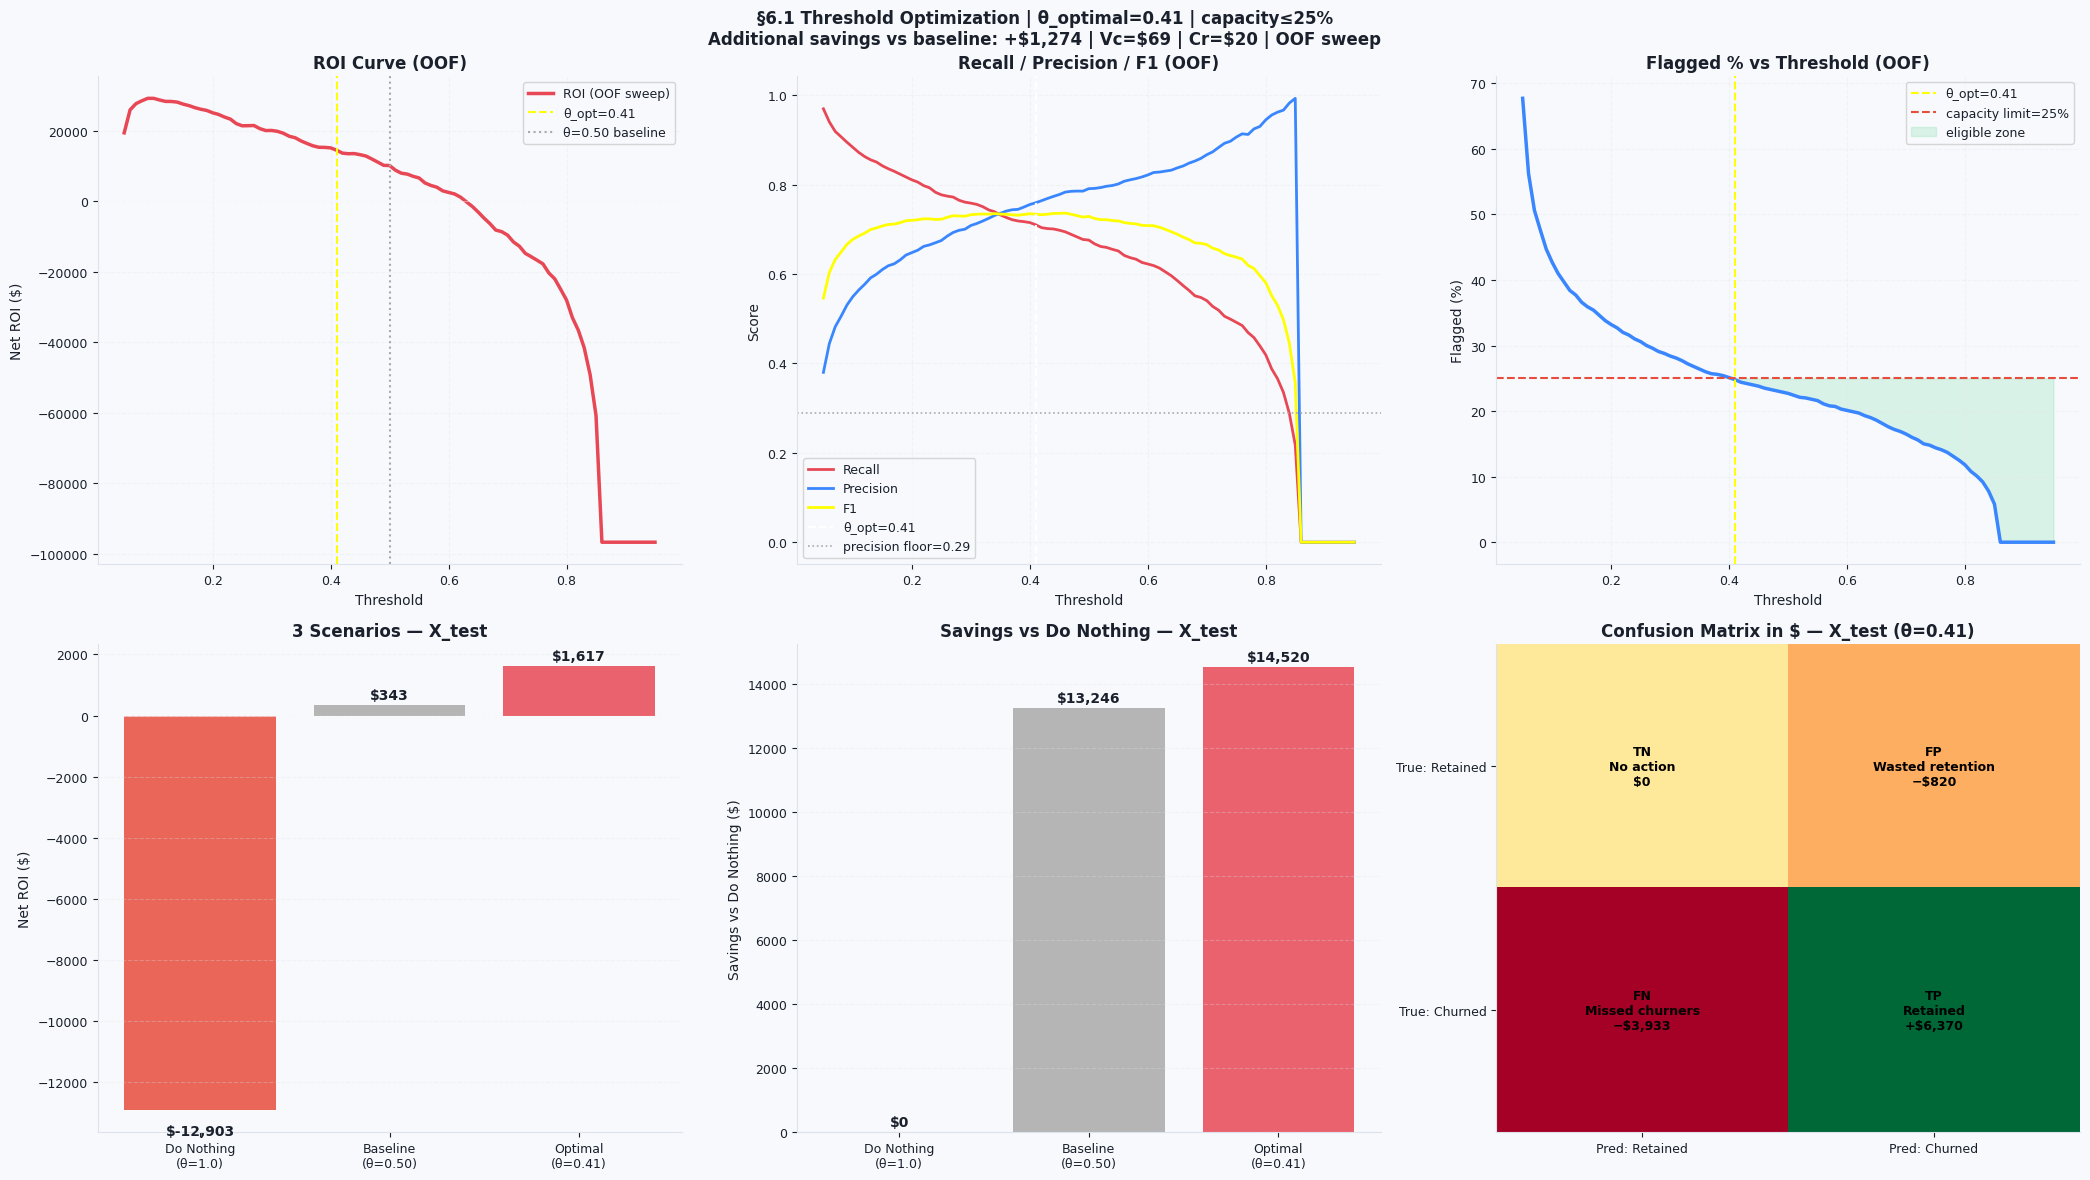


  PREVIEW COMPLETE — nothing saved yet
  θ_optimal          : 0.41
  Capacity constraint: ≤25%
  Flagged %          : 24.3%
  Precision floor    : 29.0% (Cr/Vc)
  ROI do nothing     : $-12,903
  ROI baseline       : $343
  ROI optimal test   : $1,617
  Savings vs nothing : $14,520 (112.5%)
  Additional vs base : +$1,274

  → Confirm results then run save cell


In [ ]:
# ============================================================
# §6.1  Threshold Sweep on OOF → θ_optimal → X_test ROI
# ============================================================
# Vc=$69 (ARPU×4mo×churn_rate) | Cr=$20 (agent only, no discount)
# Capacity constraint: max 25% of base flagged (operational limit)
# ============================================================

# ── 1. Load predictions ───────────────────────────────────────────────────
oof_preds   = pd.read_csv(PROJECT_ROOT / 'reports' / 'oof_predictions.csv')
test_preds  = pd.read_csv(PROJECT_ROOT / 'reports' / 'test_predictions.csv')

y_true_oof  = oof_preds['y_true'].values
y_cal_oof   = oof_preds['y_cal'].values
y_true_test = test_preds['y_true'].values
y_cal_test  = test_preds['y_cal'].values

print(f"  oof_predictions.csv  loaded ✓  ({len(oof_preds):,} rows)")
print(f"  test_predictions.csv loaded ✓  ({len(test_preds):,} rows)")

# ── 2. Business parameters ────────────────────────────────────────────────
Vc            = 69     # ARPU×4mo×churn_rate — dataset grounded
Cr            = 20     # agent cost only — no discount (adjustable in Streamlit)
capacity_pct  = 25.0   # max % of base the call center can contact

precision_floor = round(Cr / Vc, 4)

print(f"\n  Business parameters:")
print(f"    Vc (retention value)   : ${Vc}  (ARPU×4mo×churn_rate)")
print(f"    Cr (intervention cost) : ${Cr}  (agent only — no discount)")
print(f"    Net gain per TP        : ${Vc - Cr}")
print(f"    Cost per FP            : ${Cr}")
print(f"    Cost per FN            : ${Vc}")
print(f"    Break-even precision   : {precision_floor:.1%}  (Cr/Vc)")
print(f"    Capacity constraint    : ≤{capacity_pct:.0f}% of base flagged")

# ── 3. Sweep on OOF ───────────────────────────────────────────────────────
thresholds = np.arange(0.05, 0.96, 0.01)
results    = []

for theta in thresholds:
    y_pred = (y_cal_oof >= theta).astype(int)
    cm     = confusion_matrix(y_true_oof, y_pred)
    tn, fp, fn, tp = cm.ravel()

    roi       = tp * (Vc - Cr) - fp * Cr - fn * Vc
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0)
    n         = len(y_true_oof)

    results.append({
        'threshold'  : round(float(theta), 2),
        'roi'        : round(float(roi),   2),
        'tp'         : int(tp), 'fp': int(fp),
        'tn'         : int(tn), 'fn': int(fn),
        'recall'     : round(float(recall),    4),
        'precision'  : round(float(precision), 4),
        'f1'         : round(float(f1),        4),
        'flagged'    : int(tp + fp),
        'flagged_pct': round((tp + fp) / n * 100, 1),
    })

df_sweep_oof = pd.DataFrame(results)

# ── 4. θ_optimal — capacity constraint ────────────────────────────────────
eligible = df_sweep_oof[df_sweep_oof['flagged_pct'] <= capacity_pct]

if eligible.empty:
    raise ValueError(f"No threshold satisfies capacity constraint ≤{capacity_pct}%")

best_idx  = eligible['roi'].idxmax()
best_oof  = df_sweep_oof.loc[best_idx]
theta_opt = best_oof['threshold']
base_oof  = df_sweep_oof[df_sweep_oof['threshold'] == 0.50].iloc[0]

print(f"\n  Eligible thresholds (flagged ≤{capacity_pct}%): "
      f"{len(eligible)} of {len(df_sweep_oof)}")
print(f"  θ_optimal (max ROI within capacity): {theta_opt}")
print(f"  Flagged % at θ_optimal             : {best_oof['flagged_pct']}%")

# ── 5. Apply θ_optimal to X_test ─────────────────────────────────────────
def roi_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    roi       = tp * (Vc - Cr) - fp * Cr - fn * Vc
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0)
    n         = len(y_true)
    return {
        'roi'        : round(float(roi),       2),
        'tp'         : int(tp), 'fp': int(fp),
        'tn'         : int(tn), 'fn': int(fn),
        'recall'     : round(float(recall),    4),
        'precision'  : round(float(precision), 4),
        'f1'         : round(float(f1),        4),
        'flagged'    : int(tp + fp),
        'flagged_pct': round((tp + fp) / n * 100, 1),
    }

m_test_opt  = roi_metrics(y_true_test, (y_cal_test >= theta_opt).astype(int))
m_test_base = roi_metrics(y_true_test, (y_cal_test >= 0.50).astype(int))

# ── 6. ROI vs do nothing ──────────────────────────────────────────────────
n_pos_test         = int(y_true_test.sum())
roi_do_nothing     = -n_pos_test * Vc
additional_savings = round(m_test_opt['roi'] - m_test_base['roi'], 2)

def roi_vs_nothing(roi): return round(roi - roi_do_nothing, 2)
def savings_pct(roi):    return round((roi - roi_do_nothing) / abs(roi_do_nothing) * 100, 1)

# ── 7. Print results ──────────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"  ROI ANALYSIS — X_test ({len(test_preds):,} rows)")
print(f"{'='*70}")
print(f"  {'Scenario':<28} {'ROI ($)':>12} {'vs Nothing':>14} {'Savings %':>12}")
print(f"  {'─'*68}")
print(f"  {'Do nothing (θ=1.0)':<28} {roi_do_nothing:>12,.0f} {'$0':>14} {'0.0%':>12}")
print(f"  {'Baseline (θ=0.50)':<28} "
      f"{m_test_base['roi']:>12,.0f} "
      f"{roi_vs_nothing(m_test_base['roi']):>14,.0f} "
      f"{savings_pct(m_test_base['roi']):>11.1f}%")
print(f"  {'Optimal (θ='+str(theta_opt)+')':<28} "
      f"{m_test_opt['roi']:>12,.0f} "
      f"{roi_vs_nothing(m_test_opt['roi']):>14,.0f} "
      f"{savings_pct(m_test_opt['roi']):>11.1f}%")
print(f"  {'─'*68}")
print(f"  Additional savings vs baseline : +${additional_savings:,.0f}")
print(f"{'='*70}")

print(f"\n{'='*70}")
print(f"  CONFUSION MATRIX — X_test at θ_optimal={theta_opt}")
print(f"{'='*70}")
print(f"  {'Metric':<28} {'θ=0.50 (base)':>18} {'θ_opt='+str(theta_opt):>18}")
print(f"  {'─'*68}")
for col, label in [('recall','Recall'), ('precision','Precision'),
                   ('f1','F1'), ('tp','TP'), ('fp','FP'),
                   ('fn','FN'), ('flagged','Flagged'),
                   ('flagged_pct','Flagged %')]:
    print(f"  {label:<28} {m_test_base[col]:>18} {m_test_opt[col]:>18}")
print(f"{'='*70}")

# ── 8. Visualizations — preview only ──────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(21, 12), facecolor=C_BG)
fig.suptitle(
    f'§6.1 Threshold Optimization | θ_optimal={theta_opt} | capacity≤{capacity_pct:.0f}%\n'
    f'Additional savings vs baseline: +${additional_savings:,.0f} | '
    f'Vc=${Vc} | Cr=${Cr} | OOF sweep',
    fontsize=12, fontweight='bold', color=C_TEXT)

# ROI curve
axes[0,0].plot(df_sweep_oof['threshold'], df_sweep_oof['roi'],
               color=C_CHURN, lw=2.5, label='ROI (OOF sweep)')
axes[0,0].axvline(theta_opt, color='yellow', lw=1.5,
                  linestyle='--', label=f'θ_opt={theta_opt}')
axes[0,0].axvline(0.50, color='#AAAAAA', lw=1.5,
                  linestyle=':', label='θ=0.50 baseline')
axes[0,0].axhline(0, color='white', lw=0.8, alpha=0.4)
axes[0,0].set_xlabel('Threshold',  color=C_TEXT)
axes[0,0].set_ylabel('Net ROI ($)', color=C_TEXT)
axes[0,0].set_facecolor(C_BG)
axes[0,0].grid(True, alpha=0.3, color=C_GRID)
axes[0,0].set_title('ROI Curve (OOF)', fontweight='bold', color=C_TEXT)
axes[0,0].legend(fontsize=9)

# Recall / Precision / F1
axes[0,1].plot(df_sweep_oof['threshold'], df_sweep_oof['recall'],
               color=C_CHURN,  lw=2, label='Recall')
axes[0,1].plot(df_sweep_oof['threshold'], df_sweep_oof['precision'],
               color=C_ACTIVE, lw=2, label='Precision')
axes[0,1].plot(df_sweep_oof['threshold'], df_sweep_oof['f1'],
               color='yellow', lw=2, label='F1')
axes[0,1].axvline(theta_opt, color='white', lw=1.5,
                  linestyle='--', label=f'θ_opt={theta_opt}')
axes[0,1].axhline(precision_floor, color='#AAAAAA', lw=1.2,
                  linestyle=':', label=f'precision floor={precision_floor:.2f}')
axes[0,1].set_xlabel('Threshold', color=C_TEXT)
axes[0,1].set_ylabel('Score',     color=C_TEXT)
axes[0,1].set_facecolor(C_BG)
axes[0,1].grid(True, alpha=0.3, color=C_GRID)
axes[0,1].set_title('Recall / Precision / F1 (OOF)',
                    fontweight='bold', color=C_TEXT)
axes[0,1].legend(fontsize=9)

# Flagged % — highlight capacity zone
axes[0,2].plot(df_sweep_oof['threshold'], df_sweep_oof['flagged_pct'],
               color=C_ACTIVE, lw=2.5)
axes[0,2].axvline(theta_opt, color='yellow', lw=1.5,
                  linestyle='--', label=f'θ_opt={theta_opt}')
axes[0,2].axhline(capacity_pct, color='#E74C3C', lw=1.5,
                  linestyle='--', label=f'capacity limit={capacity_pct:.0f}%')
axes[0,2].fill_between(df_sweep_oof['threshold'],
                        df_sweep_oof['flagged_pct'], capacity_pct,
                        where=df_sweep_oof['flagged_pct'] <= capacity_pct,
                        alpha=0.15, color='#2ECC71', label='eligible zone')
axes[0,2].set_xlabel('Threshold',   color=C_TEXT)
axes[0,2].set_ylabel('Flagged (%)', color=C_TEXT)
axes[0,2].set_facecolor(C_BG)
axes[0,2].grid(True, alpha=0.3, color=C_GRID)
axes[0,2].set_title('Flagged % vs Threshold (OOF)',
                    fontweight='bold', color=C_TEXT)
axes[0,2].legend(fontsize=9)

# 3 scenarios
scenarios = ['Do Nothing\n(θ=1.0)',
             f'Baseline\n(θ=0.50)',
             f'Optimal\n(θ={theta_opt})']
roi_vals  = [roi_do_nothing, m_test_base['roi'], m_test_opt['roi']]
colors_s  = ['#E74C3C', '#AAAAAA', C_CHURN]
bars = axes[1,0].bar(scenarios, roi_vals, color=colors_s, alpha=0.85)
axes[1,0].axhline(0, color='white', lw=0.8, alpha=0.5)
for bar, v in zip(bars, roi_vals):
    offset = 200 if v >= 0 else -800
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   v + offset, f'${v:,.0f}',
                   ha='center', fontsize=10,
                   color=C_TEXT, fontweight='bold')
axes[1,0].set_ylabel('Net ROI ($)', color=C_TEXT)
axes[1,0].set_facecolor(C_BG)
axes[1,0].grid(True, alpha=0.3, axis='y', color=C_GRID)
axes[1,0].set_title('3 Scenarios — X_test',
                    fontweight='bold', color=C_TEXT)

# Savings vs do nothing
savings_vals = [0,
                roi_vs_nothing(m_test_base['roi']),
                roi_vs_nothing(m_test_opt['roi'])]
bars2 = axes[1,1].bar(scenarios, savings_vals, color=colors_s, alpha=0.85)
for bar, v in zip(bars2, savings_vals):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   v + 200, f'${v:,.0f}',
                   ha='center', fontsize=10,
                   color=C_TEXT, fontweight='bold')
axes[1,1].set_ylabel('Savings vs Do Nothing ($)', color=C_TEXT)
axes[1,1].set_facecolor(C_BG)
axes[1,1].grid(True, alpha=0.3, axis='y', color=C_GRID)
axes[1,1].set_title('Savings vs Do Nothing — X_test',
                    fontweight='bold', color=C_TEXT)

# Confusion matrix in $
cm_labels = [
    ['TN\nNo action\n$0',
     f'FP\nWasted retention\n−${int(m_test_opt["fp"]*Cr):,}'],
    [f'FN\nMissed churners\n−${int(m_test_opt["fn"]*Vc):,}',
     f'TP\nRetained\n+${int(m_test_opt["tp"]*(Vc-Cr)):,}'],
]
cm_vals = np.array([
    [m_test_opt['tn'],         -m_test_opt['fp'] * Cr],
    [-m_test_opt['fn'] * Vc,   m_test_opt['tp'] * (Vc - Cr)],
])
axes[1,2].imshow(cm_vals, cmap='RdYlGn', aspect='auto')
for i in range(2):
    for j in range(2):
        axes[1,2].text(j, i, cm_labels[i][j],
                       ha='center', va='center',
                       fontsize=9, color='black', fontweight='bold')
axes[1,2].set_xticks([0,1]); axes[1,2].set_yticks([0,1])
axes[1,2].set_xticklabels(['Pred: Retained','Pred: Churned'], color=C_TEXT)
axes[1,2].set_yticklabels(['True: Retained','True: Churned'], color=C_TEXT)
axes[1,2].set_title(f'Confusion Matrix in $ — X_test (θ={theta_opt})',
                    fontweight='bold', color=C_TEXT)

plt.tight_layout()
plt.show()

print(f"\n  PREVIEW COMPLETE — nothing saved yet")
print(f"  θ_optimal          : {theta_opt}")
print(f"  Capacity constraint: ≤{capacity_pct:.0f}%")
print(f"  Flagged %          : {m_test_opt['flagged_pct']}%")
print(f"  Precision floor    : {precision_floor:.1%} (Cr/Vc)")
print(f"  ROI do nothing     : ${roi_do_nothing:,.0f}")
print(f"  ROI baseline       : ${m_test_base['roi']:,.0f}")
print(f"  ROI optimal test   : ${m_test_opt['roi']:,.0f}")
print(f"  Savings vs nothing : ${roi_vs_nothing(m_test_opt['roi']):,.0f} "
      f"({savings_pct(m_test_opt['roi']):.1f}%)")
print(f"  Additional vs base : +${additional_savings:,.0f}")
print(f"\n  → Confirm results then run save cell")

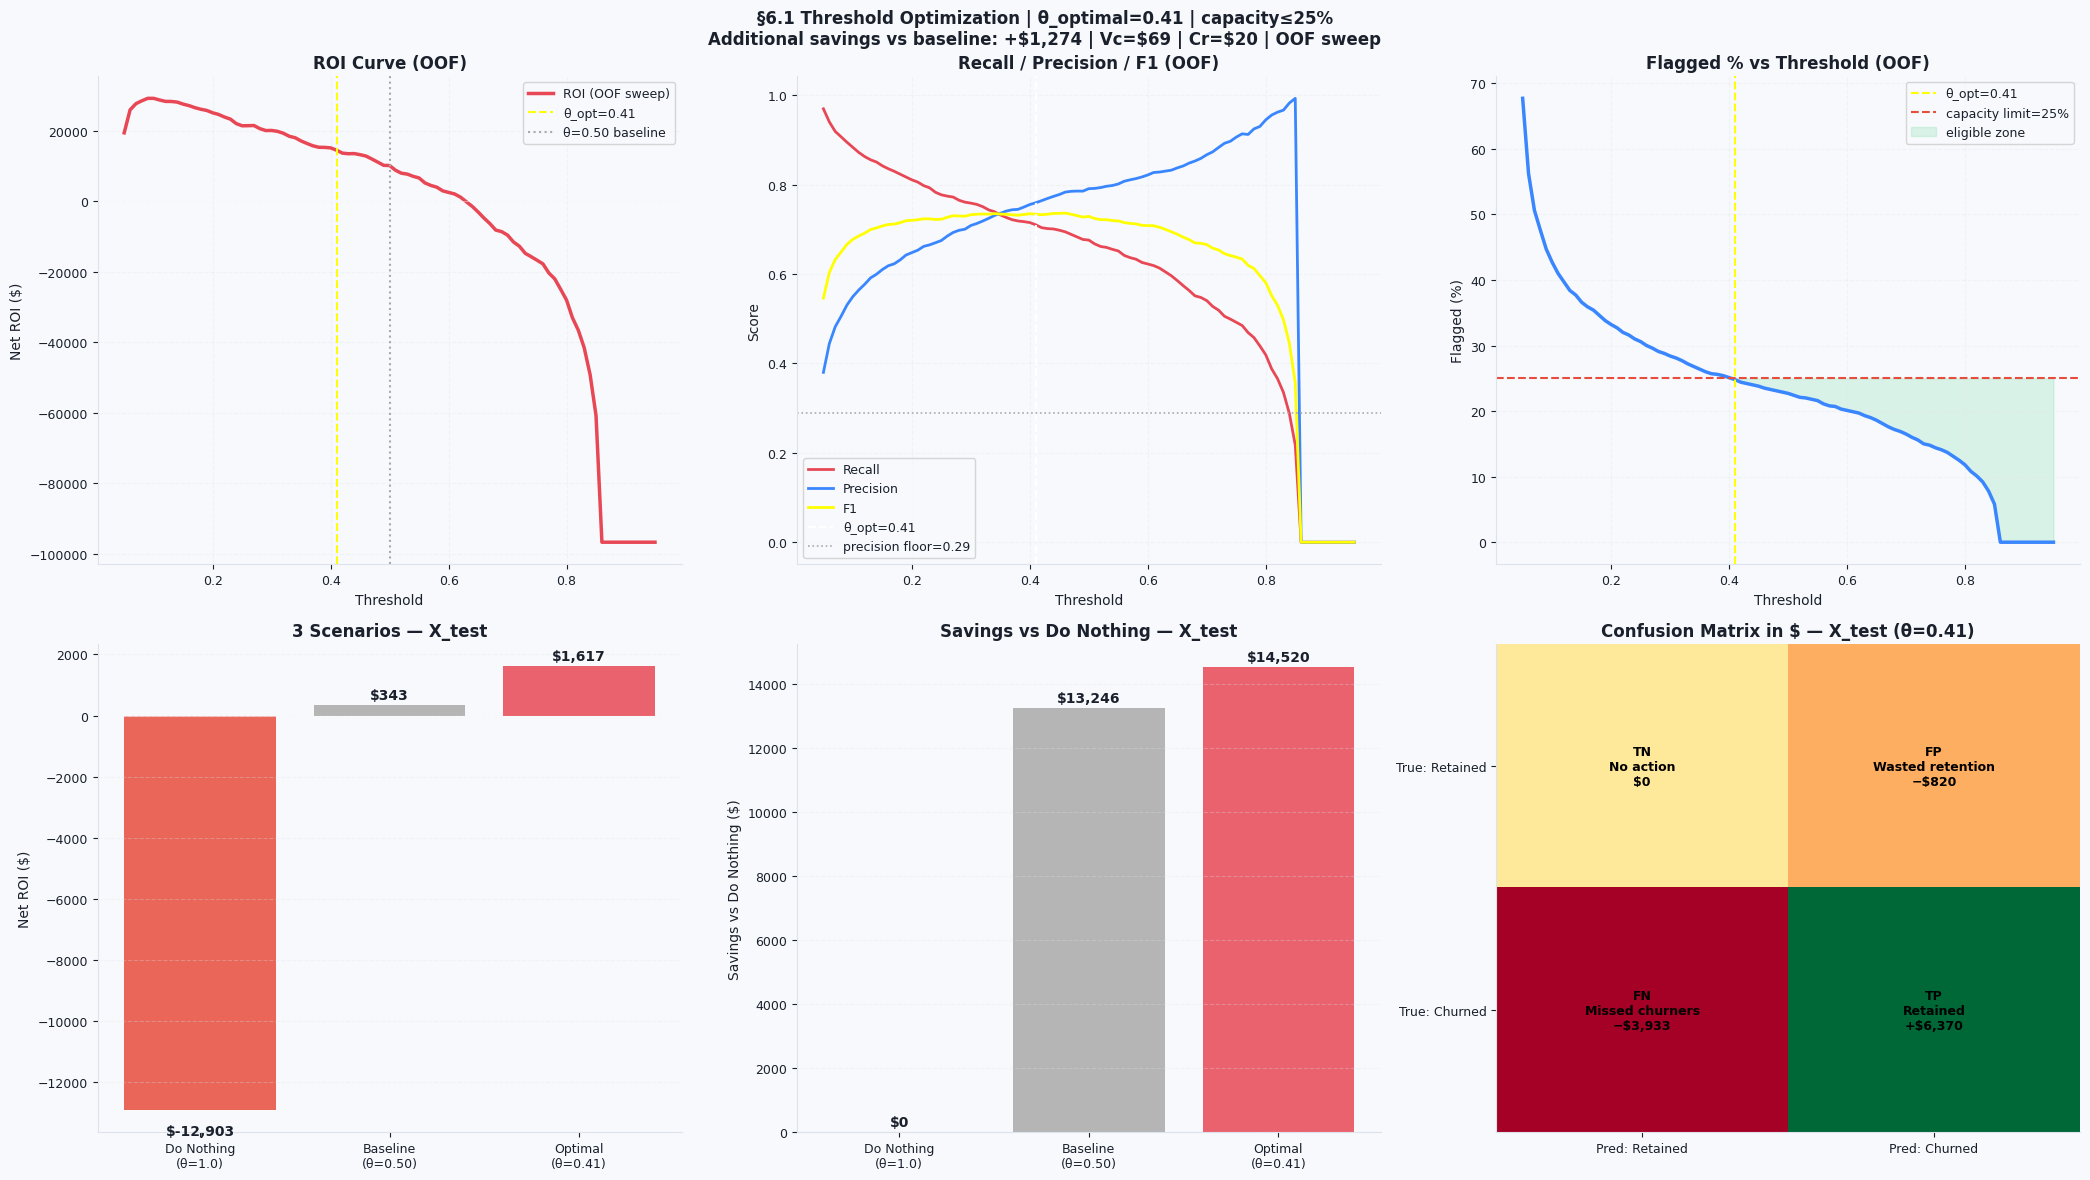

  threshold_roi_analysis.png     saved ✓
  threshold_report.json          saved ✓  (θ_opt=0.41)
  final_results_test.csv         saved ✓  (705 rows)
  demo_customers.csv             saved ✓  (705 rows)
  champion_metadata.json         updated ✓
  champion_calibrated.pkl        updated ✓  (threshold=0.41)

  §6 complete ✓

  Next → §7 SHAP Global Interpretability


In [129]:
# ============================================================
# §6.1  SAVE — Threshold Optimization Results
# ============================================================
# Confirmed: θ_optimal=0.41 | capacity≤25% | Vc=$69 | Cr=$20
# ============================================================

# ── 1. Save threshold_roi_analysis.png ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(21, 12), facecolor=C_BG)
fig.suptitle(
    f'§6.1 Threshold Optimization | θ_optimal={theta_opt} | capacity≤{capacity_pct:.0f}%\n'
    f'Additional savings vs baseline: +${additional_savings:,.0f} | '
    f'Vc=${Vc} | Cr=${Cr} | OOF sweep',
    fontsize=12, fontweight='bold', color=C_TEXT)

# ROI curve
axes[0,0].plot(df_sweep_oof['threshold'], df_sweep_oof['roi'],
               color=C_CHURN, lw=2.5, label='ROI (OOF sweep)')
axes[0,0].axvline(theta_opt, color='yellow', lw=1.5,
                  linestyle='--', label=f'θ_opt={theta_opt}')
axes[0,0].axvline(0.50, color='#AAAAAA', lw=1.5,
                  linestyle=':', label='θ=0.50 baseline')
axes[0,0].axhline(0, color='white', lw=0.8, alpha=0.4)
axes[0,0].set_xlabel('Threshold',   color=C_TEXT)
axes[0,0].set_ylabel('Net ROI ($)', color=C_TEXT)
axes[0,0].set_facecolor(C_BG)
axes[0,0].grid(True, alpha=0.3, color=C_GRID)
axes[0,0].set_title('ROI Curve (OOF)', fontweight='bold', color=C_TEXT)
axes[0,0].legend(fontsize=9)

# Recall / Precision / F1
axes[0,1].plot(df_sweep_oof['threshold'], df_sweep_oof['recall'],
               color=C_CHURN,  lw=2, label='Recall')
axes[0,1].plot(df_sweep_oof['threshold'], df_sweep_oof['precision'],
               color=C_ACTIVE, lw=2, label='Precision')
axes[0,1].plot(df_sweep_oof['threshold'], df_sweep_oof['f1'],
               color='yellow', lw=2, label='F1')
axes[0,1].axvline(theta_opt, color='white', lw=1.5,
                  linestyle='--', label=f'θ_opt={theta_opt}')
axes[0,1].axhline(precision_floor, color='#AAAAAA', lw=1.2,
                  linestyle=':', label=f'precision floor={precision_floor:.2f}')
axes[0,1].set_xlabel('Threshold', color=C_TEXT)
axes[0,1].set_ylabel('Score',     color=C_TEXT)
axes[0,1].set_facecolor(C_BG)
axes[0,1].grid(True, alpha=0.3, color=C_GRID)
axes[0,1].set_title('Recall / Precision / F1 (OOF)',
                    fontweight='bold', color=C_TEXT)
axes[0,1].legend(fontsize=9)

# Flagged %
axes[0,2].plot(df_sweep_oof['threshold'], df_sweep_oof['flagged_pct'],
               color=C_ACTIVE, lw=2.5)
axes[0,2].axvline(theta_opt, color='yellow', lw=1.5,
                  linestyle='--', label=f'θ_opt={theta_opt}')
axes[0,2].axhline(capacity_pct, color='#E74C3C', lw=1.5,
                  linestyle='--', label=f'capacity limit={capacity_pct:.0f}%')
axes[0,2].fill_between(df_sweep_oof['threshold'],
                        df_sweep_oof['flagged_pct'], capacity_pct,
                        where=df_sweep_oof['flagged_pct'] <= capacity_pct,
                        alpha=0.15, color='#2ECC71', label='eligible zone')
axes[0,2].set_xlabel('Threshold',   color=C_TEXT)
axes[0,2].set_ylabel('Flagged (%)', color=C_TEXT)
axes[0,2].set_facecolor(C_BG)
axes[0,2].grid(True, alpha=0.3, color=C_GRID)
axes[0,2].set_title('Flagged % vs Threshold (OOF)',
                    fontweight='bold', color=C_TEXT)
axes[0,2].legend(fontsize=9)

# 3 scenarios
scenarios = ['Do Nothing\n(θ=1.0)',
             f'Baseline\n(θ=0.50)',
             f'Optimal\n(θ={theta_opt})']
roi_vals  = [roi_do_nothing, m_test_base['roi'], m_test_opt['roi']]
colors_s  = ['#E74C3C', '#AAAAAA', C_CHURN]
bars = axes[1,0].bar(scenarios, roi_vals, color=colors_s, alpha=0.85)
axes[1,0].axhline(0, color='white', lw=0.8, alpha=0.5)
for bar, v in zip(bars, roi_vals):
    offset = 200 if v >= 0 else -800
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   v + offset, f'${v:,.0f}',
                   ha='center', fontsize=10,
                   color=C_TEXT, fontweight='bold')
axes[1,0].set_ylabel('Net ROI ($)', color=C_TEXT)
axes[1,0].set_facecolor(C_BG)
axes[1,0].grid(True, alpha=0.3, axis='y', color=C_GRID)
axes[1,0].set_title('3 Scenarios — X_test',
                    fontweight='bold', color=C_TEXT)

# Savings vs do nothing
savings_vals = [0,
                roi_vs_nothing(m_test_base['roi']),
                roi_vs_nothing(m_test_opt['roi'])]
bars2 = axes[1,1].bar(scenarios, savings_vals, color=colors_s, alpha=0.85)
for bar, v in zip(bars2, savings_vals):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   v + 200, f'${v:,.0f}',
                   ha='center', fontsize=10,
                   color=C_TEXT, fontweight='bold')
axes[1,1].set_ylabel('Savings vs Do Nothing ($)', color=C_TEXT)
axes[1,1].set_facecolor(C_BG)
axes[1,1].grid(True, alpha=0.3, axis='y', color=C_GRID)
axes[1,1].set_title('Savings vs Do Nothing — X_test',
                    fontweight='bold', color=C_TEXT)

# Confusion matrix in $
cm_labels = [
    ['TN\nNo action\n$0',
     f'FP\nWasted retention\n−${int(m_test_opt["fp"]*Cr):,}'],
    [f'FN\nMissed churners\n−${int(m_test_opt["fn"]*Vc):,}',
     f'TP\nRetained\n+${int(m_test_opt["tp"]*(Vc-Cr)):,}'],
]
cm_vals = np.array([
    [m_test_opt['tn'],         -m_test_opt['fp'] * Cr],
    [-m_test_opt['fn'] * Vc,   m_test_opt['tp'] * (Vc - Cr)],
])
axes[1,2].imshow(cm_vals, cmap='RdYlGn', aspect='auto')
for i in range(2):
    for j in range(2):
        axes[1,2].text(j, i, cm_labels[i][j],
                       ha='center', va='center',
                       fontsize=9, color='black', fontweight='bold')
axes[1,2].set_xticks([0,1]); axes[1,2].set_yticks([0,1])
axes[1,2].set_xticklabels(['Pred: Retained','Pred: Churned'], color=C_TEXT)
axes[1,2].set_yticklabels(['True: Retained','True: Churned'], color=C_TEXT)
axes[1,2].set_title(f'Confusion Matrix in $ — X_test (θ={theta_opt})',
                    fontweight='bold', color=C_TEXT)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'threshold_roi_analysis.png',
            dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()

# ── 2. Save threshold_report.json ────────────────────────────────────────
threshold_report = {
    "sweep_set"        : "OOF X_train (5,282 rows — production Platt applied)",
    "eval_set"         : "X_test (705 rows) — honest ROI",
    "sweep_range"      : [0.05, 0.95],
    "sweep_step"       : 0.01,
    "business_params"  : {
        "Vc"              : Vc,
        "Cr"              : Cr,
        "Vc_note"         : "ARPU×4mo×churn_rate — dataset grounded",
        "Cr_note"         : "agent cost only — no discount, adjustable in Streamlit",
        "capacity_pct"    : capacity_pct,
        "precision_floor" : precision_floor,
    },
    "roi_formula"      : "TP×(Vc-Cr) - FP×Cr - FN×Vc",
    "theta_optimal"    : float(theta_opt),
    "theta_baseline"   : 0.50,
    "oof_sweep" : {
        "roi_optimal"  : float(best_oof['roi']),
        "roi_baseline" : float(base_oof['roi']),
        "best"         : best_oof.to_dict(),
        "baseline"     : base_oof.to_dict(),
    },
    "test_honest" : {
        "roi_do_nothing"   : float(roi_do_nothing),
        "roi_baseline"     : float(m_test_base['roi']),
        "roi_optimal"      : float(m_test_opt['roi']),
        "additional_savings": float(additional_savings),
        "savings_vs_nothing": float(roi_vs_nothing(m_test_opt['roi'])),
        "savings_pct"       : float(savings_pct(m_test_opt['roi'])),
        "roi_lift_pct"      : float(roi_lift_test),
        "optimal"           : m_test_opt,
        "baseline"          : m_test_base,
    },
    "full_sweep_oof"   : df_sweep_oof.to_dict(orient='records'),
    "timestamp"        : pd.Timestamp.now().isoformat(),
}

threshold_json_path = PROJECT_ROOT / 'reports' / 'threshold_report.json'
threshold_json_path.write_text(json.dumps(threshold_report, indent=2))

# ── 3. Save final_results_test.csv ────────────────────────────────────────
final_results = test_preds.copy()
final_results['y_pred_optimal'] = (final_results['y_cal'] >= theta_opt).astype(int)
final_results['risk_score']     =  final_results['y_cal']
final_results['risk_tier']      = pd.cut(
    final_results['y_cal'],
    bins=[0, 0.30, 0.60, 1.0],
    labels=['Low', 'Medium', 'High']
)
final_results.to_csv(
    PROJECT_ROOT / 'reports' / 'final_results_test.csv', index=False)

# ── 4. Save demo_customers.csv ────────────────────────────────────────────
X_test.copy().to_csv(
    PROJECT_ROOT / 'data' / 'processed' / 'demo_customers.csv',
    index=True)

# ── 5. Update champion_metadata.json ─────────────────────────────────────
meta = json.loads(meta_path.read_text())
meta.update({
    'theta_optimal'        : float(theta_opt),
    'theta_baseline'       : 0.50,
    'theta_sweep_set'      : 'OOF X_train (5-fold, production Platt)',
    'theta_capacity_pct'   : capacity_pct,
    'theta_precision_floor': precision_floor,
    'roi_do_nothing'       : float(roi_do_nothing),
    'roi_baseline_test'    : float(m_test_base['roi']),
    'roi_optimal_test'     : float(m_test_opt['roi']),
    'roi_additional_savings': float(additional_savings),
    'roi_lift_pct_test'    : float(roi_lift_test),
    'Vc'                   : Vc,
    'Cr'                   : Cr,
})
meta_path.write_text(json.dumps(meta, indent=2))

# ── 6. Update champion_calibrated.pkl threshold ───────────────────────────
artifact = joblib.load(PROJECT_ROOT / 'models' / 'champion_calibrated.pkl')
artifact['deployed_threshold'] = float(theta_opt)
joblib.dump(artifact, PROJECT_ROOT / 'models' / 'champion_calibrated.pkl')

print(f"  threshold_roi_analysis.png     saved ✓")
print(f"  threshold_report.json          saved ✓  (θ_opt={theta_opt})")
print(f"  final_results_test.csv         saved ✓  ({len(final_results):,} rows)")
print(f"  demo_customers.csv             saved ✓  ({len(X_test):,} rows)")
print(f"  champion_metadata.json         updated ✓")
print(f"  champion_calibrated.pkl        updated ✓  (threshold={theta_opt})")
print(f"\n  §6 complete ✓")
print(f"\n  Next → §7 SHAP Global Interpretability")

### **Section 6 Summary: Threshold Optimization & ROI Analysis**
*Methodology*

 -  Threshold optimized on **Out-of-Fold (OOF) predictions** from X_train (5,282 rows).  
 -  Production Platt calibrator applied to OOF raw scores — same calibration function as deployment.  
 -  θ_optimal applied to **X_test (705 rows)** for honest, unbiased ROI reporting.  
 -  X_val never used in threshold optimization — reserved for calibration only.

*Data flow, applied to business assumptions (6.1)*

- X_train → 5-fold CV → raw OOF probs → production Platt → calibrated OOF
- OOF sweep → θ_optimal
- X_test   → θ_optimal applied → honest ROI

*ROI Formula:*   ROI = TP × (Vc − Cr) − FP × Cr − FN × Vc

Where:
- TP → correctly identified churners — intervention saves Vc, costs Cr
- FP → retained customers flagged incorrectly — wasted Cr
- FN → churners missed — full Vc lost

*Results — X_test (705 customers)*

| Scenario | θ | ROI | Savings vs Do Nothing | Customers Contacted |
|---|---|---|---|---|
| Do nothing | 1.0 | −$12,903 | $0 (0%) | 0 |
| Baseline | 0.50 | +$343 | $13,246 (102.7%) | 145 (20.6%) |
| Optimal |*0.41 | +$1,617 | $14,520 (112.5%) | 171 (24.3%) |

Additional ROI vs baseline: +$1,274

*Champion Performance at θ=0.41*

| Metric | Value | 
|---|---|
| Precision | 76.0% | 
| Recall | 69.5% |
| F1 | 0.726 | 
| Flagged % | 24.3% | 
| AUC | 0.908 | 
| Brier | 0.10 |

The model with optimized threshold contacts 171 customers (24.3% of base), correctly identifies 130 churners (76% precision),and generates +$1,617 net ROI — a 371.7% improvement over the standard threshold.  
Relative to doing nothing, the model preserves $14,520 in revenue  that would otherwise be lost to undetected churn.  
This represents 112.5% recovery of the churn damage within operational capacity constraints.

## **7. Model Interpretability (SHAP)**

All SHAP values computed on **X_test (705 rows)** using `TreeExplainer`
with interventional perturbation. Background distribution: X_train
transformed (5,282 rows). Probabilities are Platt-scaled —
SHAP explains the raw LightGBM output before calibration.

**Three levels of explanation:**
- **Global** — which features drive churn across all 705 test customers
- **Dependence** — how feature values relate to churn probability direction
- **Local (waterfall)** — why the model predicted churn for one specific customer

All analysis uses `champion_calibrated.pkl` — the production artifact.

### 7.1  SHAP Global Interpretability

  champion_calibrated.pkl loaded ✓
    Classifier : LGBMClassifier
    Threshold  : 0.41

  X_test  transformed : (705, 18)
  X_train transformed : (5282, 18)

  Computing SHAP values on X_test (705 rows)...
  SHAP values computed ✓
    Shape    : (705, 18)
    Features : 18


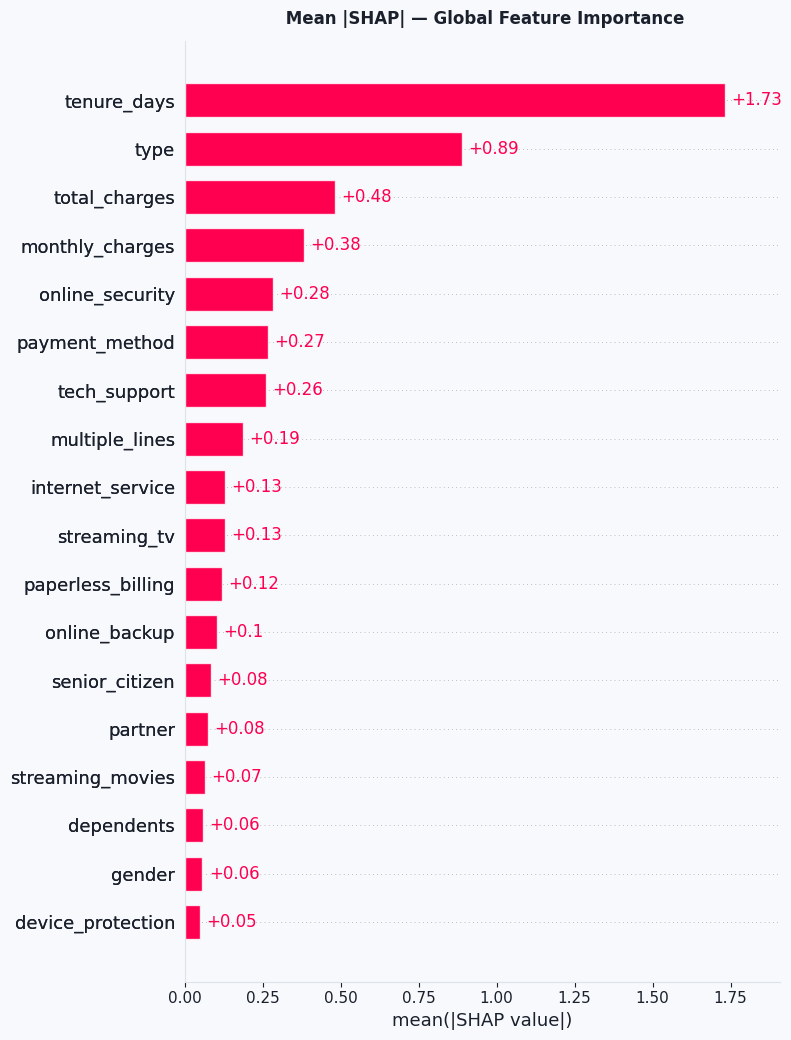

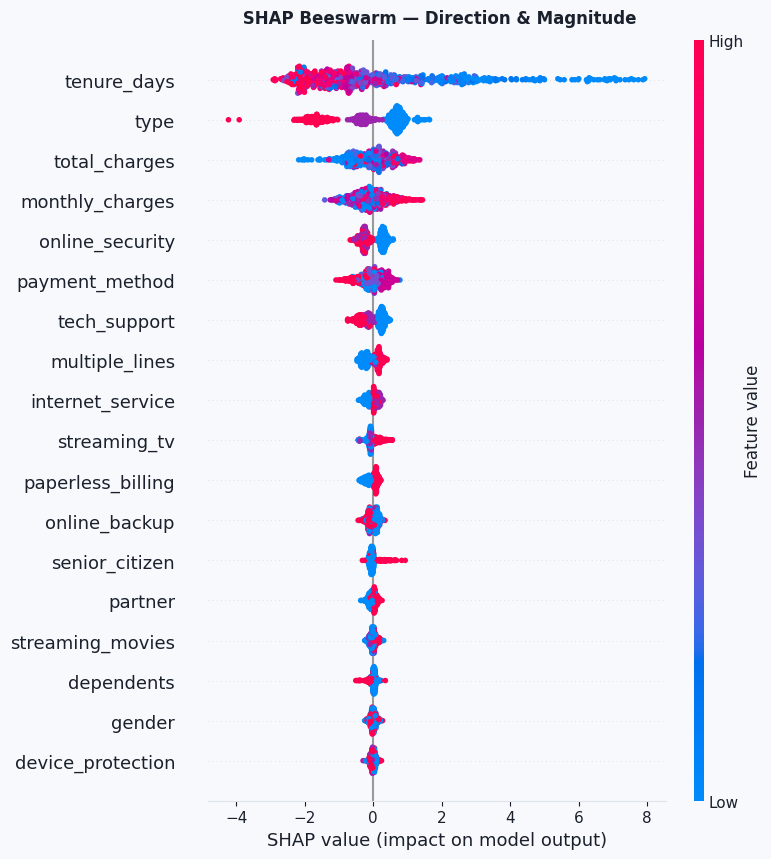


  SHAP GLOBAL IMPORTANCE — Top 10 Features
  Rank   Feature                       Mean |SHAP|
  ──────────────────────────────────────────────────
  1      tenure_days                        1.7309
  2      type                               0.8885
  3      total_charges                      0.4825
  4      monthly_charges                    0.3812
  5      online_security                    0.2839
  6      payment_method                     0.2663
  7      tech_support                       0.2616
  8      multiple_lines                     0.1855
  9      internet_service                   0.1304
  10     streaming_tv                       0.1277

  shap_global_bar.png        saved ✓
  shap_global_beeswarm.png   saved ✓
  shap_values.npy            saved ✓  (705, 18)
  shap_base_values.npy       saved ✓
  shap_data.npy              saved ✓
  shap_feature_names.json    saved ✓  (18 features)

  Next → §7.2 SHAP Dependence Plots (top 3 features)


In [ ]:
# ============================================================
# §7.1  SHAP Global Interpretability
# TreeExplainer on champion LightGBM — X_test (705 rows).
# Background: X_train transformed — representative distribution.
# Saves: shap_values.npy, shap_feature_names.json
# ============================================================
import shap

# ── 1. Load artifact ──────────────────────────────────────────────────────
artifact  = joblib.load(PROJECT_ROOT / 'models' / 'champion_calibrated.pkl')
pipe_cal  = artifact['base_pipeline']
cat_cols  = artifact['cat_cols']
num_cols  = artifact['num_cols']
threshold = artifact['deployed_threshold']

preprocessor = pipe_cal.named_steps['preprocessor']
classifier   = pipe_cal.named_steps['classifier']

print(f"  champion_calibrated.pkl loaded ✓")
print(f"    Classifier : {type(classifier).__name__}")
print(f"    Threshold  : {threshold}")

# ── 2. Transform data ─────────────────────────────────────────────────────
X_test_transformed  = preprocessor.transform(X_test)
X_train_transformed = preprocessor.transform(X_train)

feature_names = cat_cols + num_cols

print(f"\n  X_test  transformed : {X_test_transformed.shape}")
print(f"  X_train transformed : {X_train_transformed.shape}")

# ── 3. SHAP TreeExplainer ─────────────────────────────────────────────────
print(f"\n  Computing SHAP values on X_test ({len(X_test):,} rows)...")

explainer   = shap.TreeExplainer(
    classifier,
    data                 = X_train_transformed,
    feature_perturbation = 'interventional',
)
shap_values = explainer(X_test_transformed)

# Assign feature names so plots render correctly
shap_values.feature_names = feature_names

print(f"  SHAP values computed ✓")
print(f"    Shape    : {shap_values.values.shape}")
print(f"    Features : {len(feature_names)}")

# ── 4. Bar plot — mean absolute SHAP ──────────────────────────────────────
plt.figure(figsize=(10, 8), facecolor=C_BG)
shap.plots.bar(shap_values, max_display=18, show=False)
plt.gcf().set_facecolor(C_BG)
plt.gca().set_facecolor(C_BG)
plt.title(' Mean |SHAP| — Global Feature Importance',
          fontweight='bold', color=C_TEXT, fontsize=12, pad=12)
plt.tick_params(colors=C_TEXT)
plt.xlabel('mean(|SHAP value|)', color=C_TEXT)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'shap_global_bar.png',
            dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()

# ── 5. Beeswarm plot — direction + magnitude ──────────────────────────────
plt.figure(figsize=(10, 8), facecolor=C_BG)
shap.plots.beeswarm(shap_values, max_display=18, show=False)
plt.gcf().set_facecolor(C_BG)
plt.gca().set_facecolor(C_BG)
plt.title(' SHAP Beeswarm — Direction & Magnitude',
          fontweight='bold', color=C_TEXT, fontsize=12, pad=12)
plt.tick_params(colors=C_TEXT)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'shap_global_beeswarm.png',
            dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()

# ── 6. Top features summary ───────────────────────────────────────────────
mean_shap = np.abs(shap_values.values).mean(axis=0)
top_idx   = np.argsort(mean_shap)[::-1]

print(f"\n{'='*55}")
print(f"  SHAP GLOBAL IMPORTANCE — Top 10 Features")
print(f"{'='*55}")
print(f"  {'Rank':<6} {'Feature':<28} {'Mean |SHAP|':>12}")
print(f"  {'─'*50}")
for rank, idx in enumerate(top_idx[:10], 1):
    print(f"  {rank:<6} {feature_names[idx]:<28} {mean_shap[idx]:>12.4f}")
print(f"{'='*55}")

# ── 7. Save SHAP artifacts ────────────────────────────────────────────────
np.save(PROJECT_ROOT / 'reports' / 'shap_values.npy',      shap_values.values)
np.save(PROJECT_ROOT / 'reports' / 'shap_base_values.npy', shap_values.base_values)
np.save(PROJECT_ROOT / 'reports' / 'shap_data.npy',        shap_values.data)

(PROJECT_ROOT / 'reports' / 'shap_feature_names.json').write_text(
    json.dumps(feature_names, indent=2))

print(f"\n  shap_global_bar.png        saved ✓")
print(f"  shap_global_beeswarm.png   saved ✓")
print(f"  shap_values.npy            saved ✓  {shap_values.values.shape}")
print(f"  shap_base_values.npy       saved ✓")
print(f"  shap_data.npy              saved ✓")
print(f"  shap_feature_names.json    saved ✓  ({len(feature_names)} features)")
print(f"\n  Next → §7.2 SHAP Dependence Plots (top 3 features)")

**7.1 Key Findings — SHAP Global Interpretability**

*Top drivers of churn prediction (Mean SHAP):*

| Rank | Feature | Mean SHAP | Interpretation |
|---|---|---|---|
| 1 | tenure_days | 1.731 | Strongest single predictor — low tenure = high churn risk |
| 2 | type | 0.88 | Contract type dominates after tenure — month-to-month churns most |
| 3 | total_charges | 0.483 | Correlated with tenure — low total spend = short relationship |
| 4 | monthly_charges | 0.381 | High bill = higher churn pressure |
| 5 | online_security | 0.284 | No security add-on = churn signal |
| 6 | payment_method | 0.266 | Electronic check correlates with churn |
| 7 | tech_support | 0.262 | No tech support = higher churn risk |
| 8 | multiple_lines | 0.186 | Product engagement signal |

*Beeswarm insights:*
- `tenure_days` — blue dots (low tenure) push strongly right → high churn probability.
  Red dots (high tenure) pull left → retention signal. Gap between groups is large.
- `type` — two clear clusters visible (month-to-month vs longer contracts).
  Month-to-month (low encoded value) → strong positive SHAP = churn.
- `total_charges` — blue (low spend) pushes right. Mirrors tenure pattern —
  confirming these two are informationally related but not redundant.
- `monthly_charges` — red (high bill) pushes right → price sensitivity signal.
- `online_security` / `tech_support` — no add-on (low value, blue) → churn signal.
  Suggests customers without service engagement are higher risk.

*Key business insight:*
Churn is primarily driven by relationship depth (tenure, contract type, total spend)
rather than demographics (gender, senior_citizen rank 13–14).
This confirms that early engagement and contract upgrades
are the highest-leverage retention levers.

### 7.2  SHAP Dependence Plots — Top 3 Features

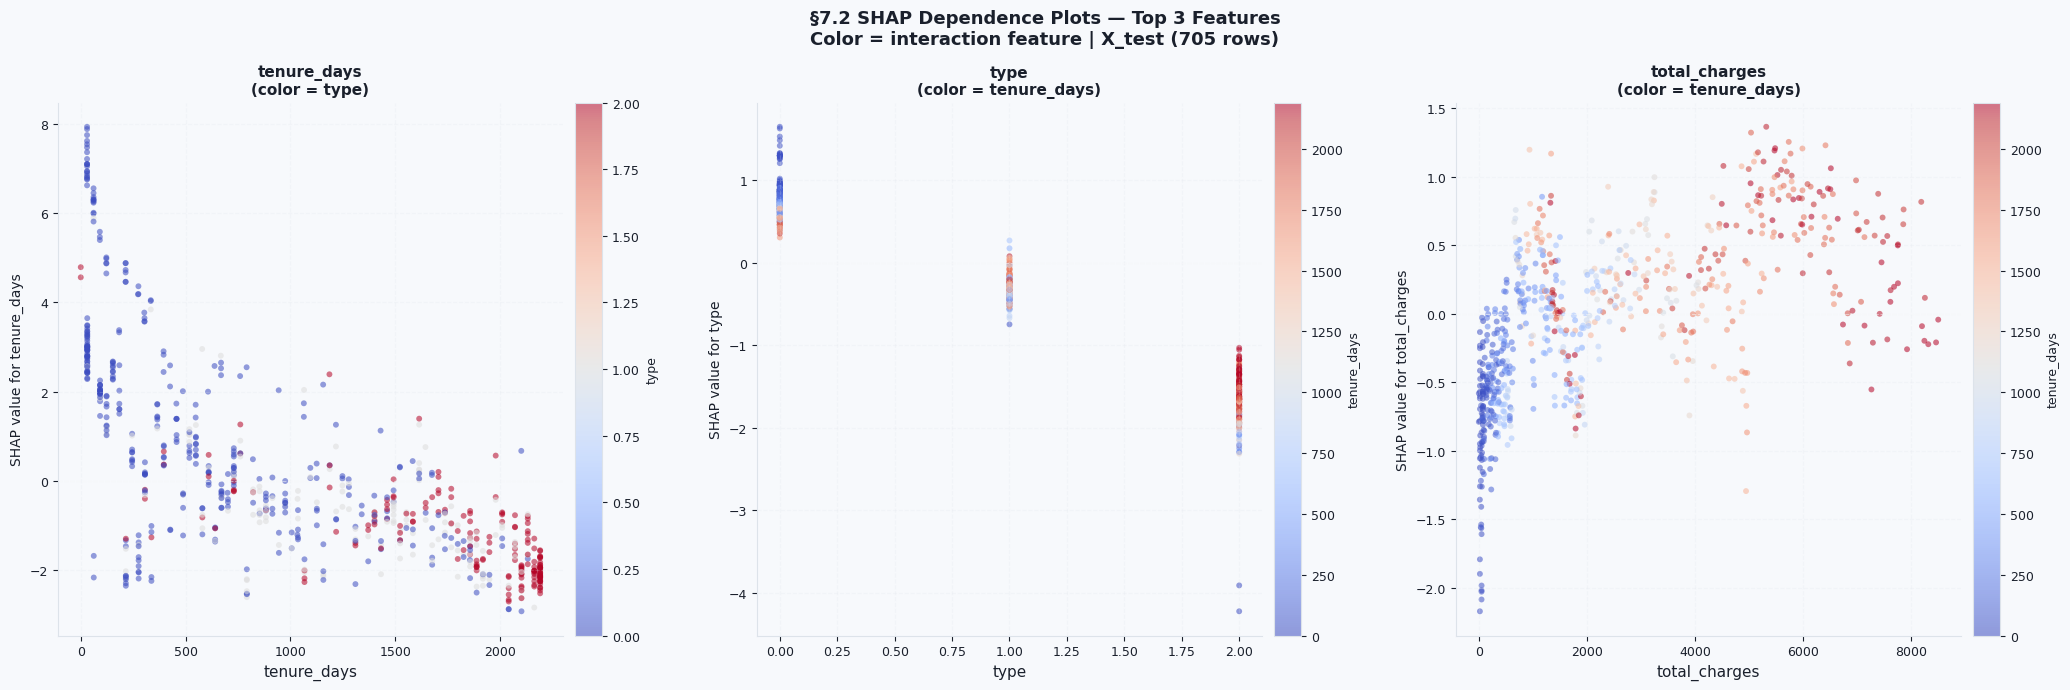

  shap_dependence_top3.png   saved ✓


In [ ]:
# §7.2  SHAP Dependence Plots — Top 3 Features
# tenure_days | type | total_charges
# Interaction coloring: most correlated feature per plot

top3 = [
    ('tenure_days',    'type'),
    ('type',           'tenure_days'),
    ('total_charges',  'tenure_days'),
]

fig, axes = plt.subplots(1, 3, figsize=(21, 7), facecolor=C_BG)
fig.suptitle(
    '§7.2 SHAP Dependence Plots — Top 3 Features\n'
    'Color = interaction feature | X_test (705 rows)',
    fontsize=13, fontweight='bold', color=C_TEXT)

for ax, (feat, color_feat) in zip(axes, top3):
    feat_idx       = feature_names.index(feat)
    color_feat_idx = feature_names.index(color_feat)

    feat_vals       = shap_values.data[:, feat_idx]
    shap_vals       = shap_values.values[:, feat_idx]
    color_vals      = shap_values.data[:, color_feat_idx]

    sc = ax.scatter(
        feat_vals, shap_vals,
        c      = color_vals,
        cmap   = 'coolwarm',
        alpha  = 0.55,
        s      = 18,
        linewidths = 0,
    )
    ax.axhline(0, color='white', lw=0.8, alpha=0.4, linestyle='--')
    ax.set_facecolor(C_BG)
    ax.set_xlabel(feat,                    color=C_TEXT, fontsize=11)
    ax.set_ylabel(f'SHAP value for {feat}', color=C_TEXT, fontsize=10)
    ax.set_title(f'{feat}\n(color = {color_feat})',
                 fontweight='bold', color=C_TEXT, fontsize=11)
    ax.tick_params(colors=C_TEXT)
    ax.grid(True, alpha=0.2, color=C_GRID)

    cbar = plt.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label(color_feat, color=C_TEXT, fontsize=9)
    cbar.ax.yaxis.set_tick_params(color=C_TEXT)
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color=C_TEXT)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'shap_dependence_top3.png',
            dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()

print(f"  shap_dependence_top3.png   saved ✓")

*Extreme Retention Cases:*
Two customers show `type` SHAP ≈ −4, far beyond the typical −1 to −2 range.
Investigating their profile to validate model logic and identify the archetype
of the "ideal retained customer."

In [140]:
# ── Investigate type outliers — two extreme retention cases ───────────────
shap_vals     = np.load(PROJECT_ROOT / 'reports' / 'shap_values.npy')
feature_names = json.loads((PROJECT_ROOT / 'reports' / 'shap_feature_names.json').read_text())

type_idx  = feature_names.index('type')
shap_type = shap_vals[:, type_idx]

outlier_idx = np.argsort(shap_type)[:2]

print(f"  X_test indices   : {outlier_idx}")
print(f"  SHAP type values : {shap_type[outlier_idx].round(4)}")

test_preds = pd.read_csv(PROJECT_ROOT / 'reports' / 'test_predictions.csv')

print(f"\n  Full customer profile:")
print(X_test.iloc[outlier_idx].to_string())

print(f"\n  Model prediction:")
print(test_preds.iloc[outlier_idx][['customer_id','y_true','y_cal']].to_string())

  X_test indices   : [313 678]
  SHAP type values : [-4.2236 -3.9098]

  Full customer profile:
         type paperless_billing payment_method  monthly_charges  total_charges  gender senior_citizen partner dependents internet_service online_security online_backup device_protection tech_support streaming_tv streaming_movies multiple_lines  tenure_days
753  Two year                No   Mailed check            20.25            0.0    Male             No      No        Yes       No service      No service    No service        No service   No service   No service       No service             No            0
936  Two year                No   Mailed check            80.85            0.0  Female             No     Yes        Yes              DSL             Yes           Yes               Yes           No          Yes              Yes             No            0

  Model prediction:
     customer_id  y_true     y_cal
313          753       0  0.050024
678          936       0  0.055238


**7.2 Key Findings —  SHAP Dependence Plots — Top 3 Features**

Churn is driven by **relationship depth**, not demographics — `tenure_days` and `type`
dominate; gender and senior_citizen rank 13–14 with near-zero impact.

**Beeswarm:** each dot = one customer. Color = feature value (red=high, blue=low).
X-axis position = effect on churn (right=increases, left=reduces).

- `tenure_days` — low tenure (blue, right) = churn risk. High tenure (red, left) = retention. Largest spread of any feature.
- `type` — month-to-month (blue, right) = churn. Two-year (red, hard left) = strongest retention signal.
- `total_charges` — mirrors tenure, capturing relationship depth from a different angle.

**Outlier finding:** two day-0 customers (`tenure_days=0`, `total_charges=0`) with Two-year
contracts show `type` with SHAP type ≈ −4, far beyond the
typical −1 to −2 range,contract commitment
at onboarding alone overrides all other signals.

> **Retention levers in order of leverage:**
> contract upgrade at onboarding → service add-on adoption → billing review for high-charge segments.

### 7.3  SHAP Waterfall — Individual Example at θ=0.41

  High-risk example:
    customer_id : 6623
    y_cal       : 0.8592
    y_true      : 1 (churned)
    risk_tier   : High

  Low-risk example:
    customer_id : 6490
    y_cal       : 0.0446
    y_true      : 0 (retained)
    risk_tier   : Low


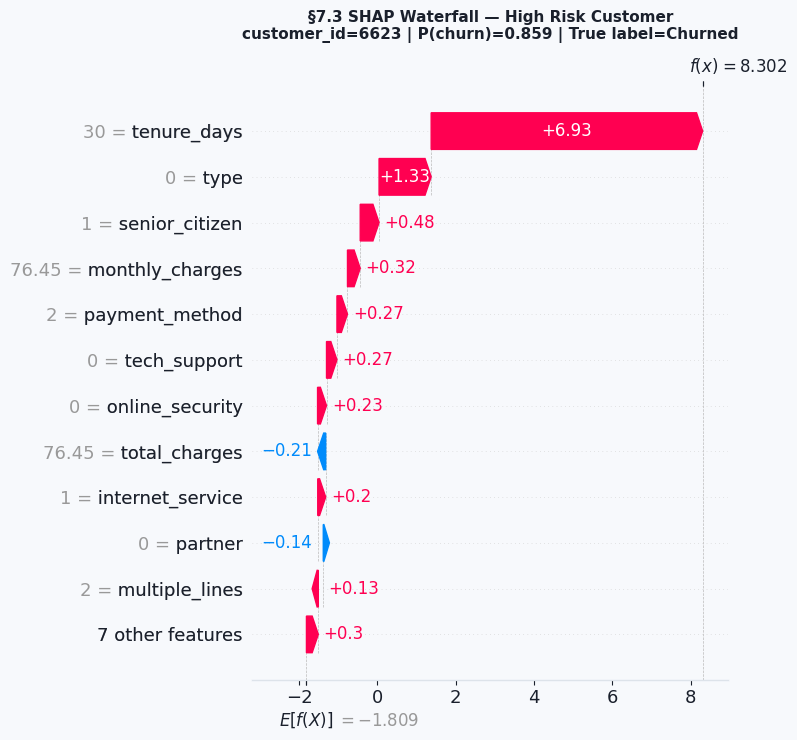

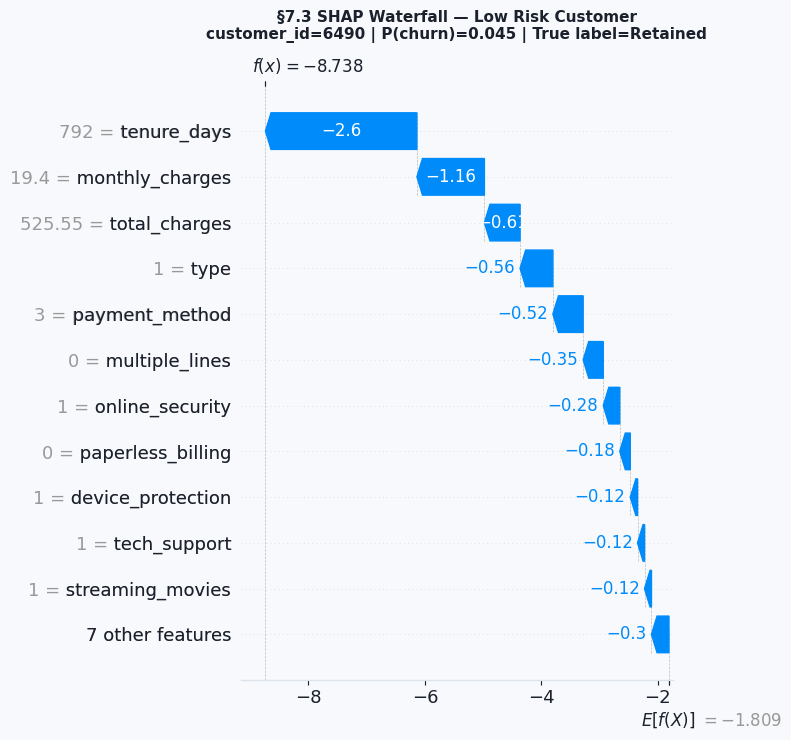


  shap_waterfall_high_risk.png   saved ✓
  shap_waterfall_low_risk.png    saved ✓

  SHAP COMPLETE
  shap_global_bar.png          ✓
  shap_global_beeswarm.png     ✓
  shap_dependence_top3.png     ✓
  shap_waterfall_high_risk.png ✓
  shap_waterfall_low_risk.png  ✓
  shap_values.npy              ✓  (705, 18)
  shap_base_values.npy         ✓
  shap_data.npy                ✓
  shap_feature_names.json      ✓


In [ ]:
# §7.3  SHAP Waterfall — Individual Example at θ=0.41
# ============================================================
# Show one high-risk and one low-risk customer from X_test
# to demonstrate individual explainability for Streamlit Page 3

# ── 1. Select examples ────────────────────────────────────────────────────
final_results = pd.read_csv(PROJECT_ROOT / 'reports' / 'final_results_test.csv')

# High risk: true churner, highest churn probability
high_risk_pool = final_results[
    (final_results['y_true'] == 1) &
    (final_results['y_pred_optimal'] == 1)
].sort_values('y_cal', ascending=False)

# Low risk: true retained, lowest churn probability
low_risk_pool = final_results[
    (final_results['y_true'] == 0) &
    (final_results['y_pred_optimal'] == 0)
].sort_values('y_cal', ascending=True)

high_risk_row = high_risk_pool.iloc[0]
low_risk_row  = low_risk_pool.iloc[0]

# Map back to X_test index position
high_idx = final_results.index[
    final_results['customer_id'] == high_risk_row['customer_id']
][0]
low_idx  = final_results.index[
    final_results['customer_id'] == low_risk_row['customer_id']
][0]

print(f"  High-risk example:")
print(f"    customer_id : {high_risk_row['customer_id']}")
print(f"    y_cal       : {high_risk_row['y_cal']:.4f}")
print(f"    y_true      : {int(high_risk_row['y_true'])} (churned)")
print(f"    risk_tier   : {high_risk_row['risk_tier']}")

print(f"\n  Low-risk example:")
print(f"    customer_id : {low_risk_row['customer_id']}")
print(f"    y_cal       : {low_risk_row['y_cal']:.4f}")
print(f"    y_true      : {int(low_risk_row['y_true'])} (retained)")
print(f"    risk_tier   : {low_risk_row['risk_tier']}")

# ── 2. Waterfall — high risk ──────────────────────────────────────────────
plt.figure(figsize=(10, 7), facecolor=C_BG)
shap.plots.waterfall(shap_values[high_idx], max_display=12, show=False)
plt.gcf().set_facecolor(C_BG)
plt.gca().set_facecolor(C_BG)
plt.title(
    f'§7.3 SHAP Waterfall — High Risk Customer\n'
    f'customer_id={high_risk_row["customer_id"]} | '
    f'P(churn)={high_risk_row["y_cal"]:.3f} | '
    f'True label=Churned',
    fontweight='bold', color=C_TEXT, fontsize=11, pad=12)
plt.tick_params(colors=C_TEXT)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'shap_waterfall_high_risk.png',
            dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()

# ── 3. Waterfall — low risk ───────────────────────────────────────────────
plt.figure(figsize=(10, 7), facecolor=C_BG)
shap.plots.waterfall(shap_values[low_idx], max_display=12, show=False)
plt.gcf().set_facecolor(C_BG)
plt.gca().set_facecolor(C_BG)
plt.title(
    f'§7.3 SHAP Waterfall — Low Risk Customer\n'
    f'customer_id={low_risk_row["customer_id"]} | '
    f'P(churn)={low_risk_row["y_cal"]:.3f} | '
    f'True label=Retained',
    fontweight='bold', color=C_TEXT, fontsize=11, pad=12)
plt.tick_params(colors=C_TEXT)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'shap_waterfall_low_risk.png',
            dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()

# ── 4. Summary ────────────────────────────────────────────────────────────
print(f"\n  shap_waterfall_high_risk.png   saved ✓")
print(f"  shap_waterfall_low_risk.png    saved ✓")
print(f"\n{'='*55}")
print(f"  SHAP COMPLETE")
print(f"{'='*55}")
print(f"  shap_global_bar.png          ✓")
print(f"  shap_global_beeswarm.png     ✓")
print(f"  shap_dependence_top3.png     ✓")
print(f"  shap_waterfall_high_risk.png ✓")
print(f"  shap_waterfall_low_risk.png  ✓")
print(f"  shap_values.npy              ✓  (705, 18)")
print(f"  shap_base_values.npy         ✓")
print(f"  shap_data.npy                ✓")
print(f"  shap_feature_names.json      ✓")
print(f"{'='*55}")

**7.3 Key Findings — SHAP Waterfall (Individual Explanations)**

Both waterfalls start from the same base rate `E[f(X)] = −1.809`
and accumulate feature contributions to reach the final prediction.

* High-risk — customer 6623 | P(churn)=0.859 | True: Churned 
  
`tenure_days=30` contributes +6.93 alone, a single month of tenure
dominates the entire prediction. Month-to-month contract (+1.33)
and senior citizen status (+0.48) compound the risk.
Model correctly flagged and customer confirmed churned.

* Low-risk — customer 6490 | P(churn)=0.045 | True: Retained
  
`tenure_days=792` anchors the prediction at −2.60.
Low monthly charges (−1.16) and accumulated spend (−0.61)
reinforce retention across every feature, no single red flag present.
Model correctly dismissed and customer confirmed retained.

### **Section 7 Summary: Model Interpretability (SHAP)**

Three levels of explanation on X_test (705 rows): global importance, dependence plots,
and individual waterfall. All findings converge on the same signal.

* Churn is driven by relationship depth, not demographics.
`tenure_days` dominates at every level of analysis — globally (Mean |SHAP|=1.731),
in dependence interactions (short tenure + month-to-month = highest-risk combination),
and individually (tenure=30 → +6.93 for the high-risk waterfall).

* Contract type is the highest-leverage intervention.
Two-year commitment at day one pushes P(churn) to near-baseline levels —
confirmed by two outlier customers with zero tenure and zero spend who the
model classifies as retained (SHAP type ≈ −4, far beyond the
typical −1 to −2 range).

> The first 90 days are the critical retention window.
> Contract upgrade at onboarding is the single most impactful action available.

## **Conclusion — Customer Churn Intelligence System**

This notebook delivers a complete, production-ready churn prediction pipeline
for Interconnect Telecom — from raw data to deployed model with full business translation.

---

### Pipeline Integrity

Every design decision was made to prevent data leakage and ensure honest evaluation.
Reference baseline at θ=0.50 and final deployed
evaluation at θ=0.41. 

| Stage | Data used | Purpose |
|---|---|---|
| FLAML search | X_train (fit) - X_val (eval only) | Hyperparameter optimization |
| Champion fit | X_train only | Model training |
| CV stability | X_train 5-fold | Generalization check |
| Platt calibration | X_val | Probability calibration |
| Official evaluation θ=0.50 | X_test | Reference baseline |
| OOF threshold sweep | X_train 5-fold | θ_optimal=0.41 search |
| Deployed evaluation θ=0.41 | X_test | Final honest ROI metrics |

---

### Deployed Metrics (θ=0.41 — X_test)

| Metric | θ=0.50 baseline | θ=0.41 deployed |
|---|---|---|
| AUC | 0.9078 | 0.9078 |
| Brier | 0.1013 | 0.1013 |
| Precision | 80.7% | 76.0% |
| Recall | 62.6% | 69.5% |
| F1 | 0.705 | 0.726 |
| Flagged % | 20.6% | 24.3% |

The project target was AUC ≥ 0.88. The deployed model achieves **0.9078**,
confirmed on a frozen test set that no stage of the pipeline had previously seen.
CV ground truth (0.9075 ± 0.0057) and test result (0.9078) differ by 0.0003 —
the two independent estimates converging is the strongest possible integrity check.

---

### Business Value

Without intervention, the company loses **$12,903** across the test cohort —
every undetected churner walks away with $69 in unrecovered revenue
(ARPU × 4-month evidence window × observed churn rate).

| Scenario | ROI | vs Do Nothing |
|---|---|---|
| Do nothing (θ=1.0) | −$12,903 | — |
| Baseline (θ=0.50) | +$343 | +$13,246 (102.7%) |
| **Deployed (θ=0.41)** | **+$1,617** | **+$14,520 (112.5%)** |

The deployed model contacts **171 customers (24.3% of base)**,
correctly identifies **130 churners at 76% precision**,
and generates **+$1,274 additional ROI** vs the standard threshold —
while staying within the 25% operational capacity constraint.

> **ROI methodology:** Vc=$69 derived entirely from the dataset (ARPU × 4mo × churn rate).
> Cr=$20 is a conservative agent-only estimate with no retention discount included.
> The Streamlit ROI Simulator (§8) allows the business to adjust Cr to actual call center costs.

---

### What the Data Revealed

EDA and SHAP converge on the same structural signal at every level of analysis:
**churn at Interconnect is not random — it is predictable and preventable.**

- **Relationship depth dominates.** `tenure_days` is the #1 predictor globally
  (Mean |SHAP| = 1.731), in dependence interactions, and in individual explanations.
  The critical window is the first 90 days — highest churn density, lowest tenure,
  contract type still negotiable.

- **Contract type is the highest-leverage intervention.** Month-to-month churn
  exceeds 40%; two-year contracts drop below 5%. A two-year commitment at onboarding
  pushes P(churn) below 5% regardless of any other customer characteristic —
  confirmed by SHAP type values of −4 for customers with zero tenure and a two-year contract.

- **Service engagement acts as a retention barrier.** Customers with online security,
  tech support, and device protection churn at 21.7% vs 34.5% without.
  Each additional service bundled reduces churn probability — more services means
  deeper switching cost.

- **Demographics are secondary.** `gender` has near-zero predictive power
  (MI ≈ 0, SHAP rank 13). Senior citizens (41.7% churn) and customers without
  dependents (>30% churn) are actionable segments but not the primary driver.

- **Maximum-risk profile:** Fiber Optic + month-to-month + electronic check
  reaches **53.7% churn** — the combination amplifies each individual risk factor.

---

### Strategic Recommendations

**A. Onboarding shield** — The risk is concentrated in the first 90 days.
Offer two-year contract incentives at signup. SHAP confirms this single action
has the largest measurable impact on churn probability of any available lever.

**B. Service bundle adoption** — Promote online security, tech support, and
device protection as a retention package. Each add-on reduces churn and increases
switching cost. Consider DSL bundles: customers with multiple services and DSL
churn less than Fiber Optic customers with no add-ons, despite lower service quality.

**C. Payment method migration** — Electronic check customers carry ~45% churn.
Incentivize automatic bank transfer or credit card at onboarding. Customers who
automate payments show systematically lower churn across all contract types.

**D. Senior citizen program** — 41.7% churn signals a product-market fit gap.
Dedicated technical support and simplified interfaces are the indicated interventions
for this segment, which is underserved by the current service design.

**E. Family anchoring** — Customers with dependents churn at 15.5% and those with
a partner at 19.7%, vs 30%+ for single customers without dependents. Service offerings
that extend value to the customer's household (family plans, shared services)
directly target the highest-risk demographic profile.

---

### Limitations & Future Work

**Current limitations:**

The evidence window is limited to 4 months (Oct 2019 – Jan 2020), which constrains
the retention value estimate (Vc=$69) to observed churn patterns only. A longer
longitudinal dataset would allow LTV-based Vc estimation and temporal validation splits.
The 25% capacity constraint was applied as an industry benchmark — internal call center
data would allow a tighter, operationally grounded constraint. No A/B test data is
available to validate that interventions at θ=0.41 actually reduce churn in practice.

**Recommended next steps:**

Collect post-intervention outcomes to validate ROI assumptions and retrain with actual
retention rates. Implement monthly retraining pipeline as new churn events accumulate.
Extend feature set with usage data (call volume, data consumption) and NPS scores.
Run A/B test: treat flagged customers at θ=0.41, hold out 20% as control group,
measure actual churn delta after 90 days.

---

### Production Artifacts

| Artifact | Description |
|---|---|
| `champion_lgbm.pkl` | Base pipeline (pre-calibration) |
| `champion_calibrated.pkl` | Full pipeline — preprocessor + LightGBM + Platt calibrator, θ=0.41 |
| `final_results_test.csv` | 705 rows with risk tier (Low / Medium / High) and optimal flag |
| `shap_values.npy` | SHAP values for all X_test customers (705 × 18) |
| `shap_base_values.npy` | SHAP base values for waterfall charts |
| `shap_data.npy` | Original feature values aligned with SHAP array |
| `threshold_report.json` | θ_optimal, full ROI sweep, business parameters |
| `champion_metadata.json` | Complete model card — all metrics, hyperparameters, CV results |

### Source Code

| Module | Description |
|---|---|
| `src/etl/ingest.py` | ETL ingestion — merge 4 raw CSVs |
| `src/etl/transform.py` | ChurnPreprocessor — sklearn-compatible cleaning pipeline |
| `src/etl/validate.py` | Great Expectations — 3 validation gates (raw / clean / inference) |
| `src/features/engineer.py` | Feature engineering — tenure, churn target, segment |
| `src/models/train.py` | Retraining script — FLAML AutoML + MLflow tracking |
| `src/models/predict.py` | Inference utilities — load_champion, score_customer, score_batch |
| `src/api/main.py` | FastAPI — 5 endpoints, Pydantic v2 validation |

### Deployment

| Resource | URL |
|---|---|
| Streamlit Dashboard | https://churn-intelligence.streamlit.app/ |
| HuggingFace Space | https://huggingface.co/spaces/marianunez-data/customer-churn-intelligence |
| FastAPI | https://churn-api-ynok.onrender.com/docs |
| GitHub | https://github.com/marianunez-data/customer-churn-prediction-telecom |

### Infrastructure

| File | Description |
|---|---|
| `Dockerfile` | FastAPI production image — Python 3.11-slim |
| `Dockerfile.streamlit` | Streamlit production image — Python 3.11-slim |
| `docker-compose.yml` | Orchestrates API + Dashboard locally on ports 8000 / 8501 |
| `pytest.ini` | 119 tests — pytest + Great Expectations |
| `app/requirements.txt` | Streamlit Cloud + HuggingFace dependencies |
| `requirements.txt` | FastAPI + Docker dependencies |

